In [82]:
# Waveform and Firing Rate Clustering Analysis
# This notebook performs comprehensive clustering analysis combining waveform data with firing rate and bursting metrics

import pynapple as nap
from spikeinterface import load_sorting_analyzer
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import fnmatch
import matplotlib as mpl
import re
import os
from scipy import stats
from sklearn.decomposition import PCA, FastICA
from scipy.linalg import norm
from scipy.stats import kstest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap
from scipy.signal import correlate
import warnings
warnings.filterwarnings('ignore')

print("All imports loaded successfully!")

# Bursting capacity metrics based on autocorrelograms
def calculate_autocorrelogram(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate autocorrelogram for spike times.
    
    Parameters:
    - spike_times: array of spike times in seconds
    - bin_size: bin size in seconds (default 1ms)
    - window_size: window size in seconds (default 100ms)
    
    Returns:
    - bins: time bins
    - autocorr: autocorrelogram values
    """
    if len(spike_times) < 2:
        return np.array([0]), np.array([0])
    
    # Create bins
    bins = np.arange(-window_size, window_size + bin_size, bin_size)
    
    # Calculate autocorrelogram
    autocorr = np.zeros(len(bins) - 1)
    
    for i, spike_time in enumerate(spike_times):
        # Find all other spikes
        other_spikes = np.concatenate([spike_times[:i], spike_times[i+1:]])
        
        # Calculate time differences
        time_diffs = other_spikes - spike_time
        
        # Bin the differences
        hist, _ = np.histogram(time_diffs, bins=bins)
        autocorr += hist
    
    # Normalize by number of spikes
    autocorr = autocorr / len(spike_times)
    
    return bins[:-1], autocorr

def calculate_bursting_metrics(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate multiple bursting capacity metrics from autocorrelogram.
    
    Returns a dictionary with various bursting metrics:
    1. Burst Index: ratio of short-interval spikes to long-interval spikes
    2. Refractory Period Violation: spikes in refractory period
    3. Burst Peak Height: height of the first peak after time 0
    4. Burst Peak Width: width of the first peak
    5. Autocorr Skewness: skewness of the autocorrelogram
    6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    """
    if len(spike_times) < 10:  # Need sufficient spikes for reliable metrics
        return {
            'burst_index': 0,
            'refractory_violation': 0,
            'burst_peak_height': 0,
            'burst_peak_width': 0,
            'autocorr_skewness': 0,
            'short_isi_ratio': 0,
            'autocorr_vector': np.zeros(200)  # Fixed size for consistency
        }
    
    # Calculate autocorrelogram
    bins, autocorr = calculate_autocorrelogram(spike_times, bin_size, window_size)
    
    # Find center bin (time = 0)
    center_idx = len(bins) // 2
    
    # 1. Burst Index: ratio of short-interval spikes (1-10ms) to long-interval spikes (50-100ms)
    short_window = (bins >= 0.001) & (bins <= 0.010)  # 1-10ms
    long_window = (bins >= 0.050) & (bins <= 0.100)   # 50-100ms
    
    short_count = np.sum(autocorr[short_window])
    long_count = np.sum(autocorr[long_window])
    burst_index = short_count / (long_count + 1e-10)  # Add small value to avoid division by zero
    
    # 2. Refractory Period Violation: spikes in 0-2ms window
    refractory_window = (bins >= 0) & (bins <= 0.002)
    refractory_violation = np.sum(autocorr[refractory_window])
    
    # 3. Burst Peak Height: height of the first peak after time 0
    # Look for peaks in the 1-20ms window
    peak_window = (bins >= 0.001) & (bins <= 0.020)
    if np.any(peak_window):
        burst_peak_height = np.max(autocorr[peak_window])
    else:
        burst_peak_height = 0
    
    # 4. Burst Peak Width: width at half height of the first peak
    if burst_peak_height > 0:
        half_height = burst_peak_height / 2
        # Fix the indexing issue - use the correct window for peak_indices
        peak_indices = np.where(autocorr[peak_window] >= half_height)[0]
        if len(peak_indices) > 0:
            burst_peak_width = (np.max(peak_indices) - np.min(peak_indices)) * bin_size
        else:
            burst_peak_width = 0
    else:
        burst_peak_width = 0
    
    # 5. Autocorr Skewness: skewness of the autocorrelogram
    autocorr_skewness = stats.skew(autocorr)
    
    # 6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    isis = np.diff(spike_times)
    short_isis = np.sum(isis < 0.010)
    total_isis = len(isis)
    short_isi_ratio = short_isis / (total_isis + 1e-10)
    
    # Create a standardized autocorr vector (fixed size for consistency)
    autocorr_vector = np.zeros(200)
    if len(autocorr) > 0:
        # Interpolate to fixed size
        autocorr_vector = np.interp(np.linspace(0, len(autocorr)-1, 200), 
                                  np.arange(len(autocorr)), autocorr)
    
    return {
        'burst_index': burst_index,
        'refractory_violation': refractory_violation,
        'burst_peak_height': burst_peak_height,
        'burst_peak_width': burst_peak_width,
        'autocorr_skewness': autocorr_skewness,
        'short_isi_ratio': short_isi_ratio,
        'autocorr_vector': autocorr_vector
    }

print("Bursting metrics functions defined")

def imec_key_sorter(key):
    """Extract the number after 'imec', default to a large number if not found."""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

All imports loaded successfully!
Bursting metrics functions defined


In [83]:
#subject definitions for tumor cohort
nwb_paths = [
    Path("/data_store2/neuropixels/nwb/old/NP93_B1/NP93_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP95_B1/NP95_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP101_B3/NP101_B3.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP102_B2/NP102_B2.nwb"), # new lg flair+
    Path("/data_store2/neuropixels/nwb/old/NP105_B1/NP105_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP113_B1/NP113_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP114_B1/NP114_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP116_B2/NP116_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP122_B1/NP122_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP128_B1/NP128_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP129_B1/NP129_B1.nwb"),
    #Path("/data_store2/neuropixels/nwb/old/NP132_B2/NP132_B2.nwb"),
    #Path("/data_store2/neuropixels/nwb/old/NP132_B3/NP132_B3.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP136_B1/NP136_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP137_B1/NP137_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP138_B1/NP138_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP139_B1/NP139_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP139_B2/NP139_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP147_B2/NP147_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP150_B1/NP150_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP153_B1/NP153_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP171_B1/NP171_B1.nwb"), # new gbm flair-
    Path("/data_store2/neuropixels/nwb/old/NP174_B3/NP174_B3.nwb"), # new gbm flair-
    #Path("/data_store2/neuropixels/nwb/old/NP80_B1/NP80_B1.nwb"), # provisional new IFG probe
    #Path("/data_store2/neuropixels/nwb/old/NP78_B1/NP78_B1.nwb"), # new IFG probe
    #Path("/data_store2/neuropixels/nwb/old/NP69_B2/NP69_B2.nwb"), # new IFG probe
    #Path("/data_store2/neuropixels/nwb/old/NP69_B1/NP69_B1.nwb") # new IFG probe
]   

### adjust for the depth of the probe
subj_list = [1, 2, 3, 4, 5, 6, 6, 6, 7, 8, 9, 10, 10, 11, 12, 13, 14, 15, 16, 16, 17, 17, 18, 19, 20, 20, 21, 22, 23]
path_list = ['ast', 'ast', 'gbm', 'ast','oli', 'gbm', 'gbm', 'gbm', 'gbm', 'gbm', 'ast', 'ast', 'ast', 'ast', 'oli', 'oli', 'gbm', 'ast', 'ast', 'ast', 'ast', 'ast', 'ast', 'gbm', 'ast', 'ast', 'oli', 'gbm', 'gbm']
grade_list = [4, 4, 4, 2, 3, 4, 4, 4, 4, 4, 3, 2, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 3, 4, 4]
yield_list = [1, 57, 14, 26, 1, 139, 178, 202, 49, 5, 30, 9, 29, 3, 129, 147, 30, 35, 10, 1, 34, 8, 42, 30, 10, 11, 23, 17, 24]
opercular_list = [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
region_list = ['aSTG','SFG','aSTG','pSTG','SFG','vPrCG','vPrCG','vPrCG','pSTG','aMTG','MFG','aSTG','parsOp','MFG','PoCG','PoCG','pSTG','parsOr','vPrCG','pSTG','parsTr','pSTG','parsTr','SMG','parsTr','pSTG','vPrCG', 'aSTG', 'vPrCG']
age_list = [28, 28, 54, 24, 34, 52, 52, 52, 59, 64, 34, 34, 34, 39, 43, 43, 63, 38, 43, 43, 29, 29, 29, 47, 31, 31, 41, 79, 55]
gender_list = [1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0]

manual_exclude_lists = [
    [2], # NP93_B1.imec0
    [], # NP95_B1.imec0
    [29, 45, 55], # NP101_B3.imec0
    [96, 115, 173, 183, 205, 207, 217], # NP102_B2.imec0
    [130, 150, 151, 245, 371, 375, 377, 380, 386, 452], # NP105_B1.imec0
    [149, 156, 172, 173, 176, 217, 221, 253, 272, 276, 336, 487], # NP113_B1.imec0
    [22, 112, 149, 155, 161, 167, 176, 188, 190, 196, 213, 216, 241, 252, 255, 258, 286, 289, 307, 325, 326, 370, 395, 442, 443, 448, 449, 451, 455, 510, 549, 582, 692, 710, 717, 719, 722, 726, 729], # NP113_B1.imec1
    [385, 448], # NP113_B2.imec2
    [32, 34, 37, 39, 67, 142, 145, 175, 188, 310, 325, 331, 391, 392], # NP114_B1.imec0
    [11, 15, 36], # NP116_B2.imec0
    [340, 382], # NP122_B1.imec0
    [54, 109, 152], # NP128_B1.imec0
    [], # NP128_B1.imec1
    [0, 6, 13, 33, 51, 52], # NP129_B1.imec0
    [19, 62, 111, 151, 171, 192, 199, 200, 205, 210, 227, 229, 244, 290, 298, 311], # NP132_B2.imec0
    [0, 10, 11, 15, 29, 45, 61, 112, 127, 149, 151, 158, 159, 172, 197, 209, 212, 218, 297, 315], # NP132_B3.imec0
    [334, 335, 333], # NP136_B1.imec0
    [361], # NP137_B1.imec0
    [], # NP138_B1.imec0
    [169, 195, 198], # NP138_B1.imec1
    [137, 149, 196, 197, 199, 206, 212, 220, 223, 231], # NP139_B1.imec0
    [129, 248, 249], # NP139_B1.imec1
    [28, 59, 60, 62, 63, 82, 104, 112, 146], # NP139_B2.imec0
    [47, 57, 59, 73, 82, 88, 116, 124, 125, 126, 127, 129, 148, 175, 194, 196, 239, 240, 242, 243, 244, 246, 253, 267, 245, 247, 248, 249, 250, 251, 254], # NP147_B2.imec0
    [], # NP150_B1.imec0
    [34, 64, 119, 135], # NP150_B1.imec1
    [20, 22, 47, 71, 80, 118, 125, 134, 141, 145, 146, 166, 173, 176, 191, 270, 298, 307, 385, 414, 391, 472, 473, 490], # NP153_B1.imec0
    [16, 67, 74, 78, 91, 99, 221, 224, 225, 288], # NP171_B1.imec0
    [9, 11, 13, 23, 40, 43, 47, 59, 67, 72, 87, 104, 109, 122, 166, 169, 172, 175, 197, 199, 203, 205, 211, 212, 219, 227, 229, 230, 235, 237, 240, 251, 256, 295, 296], # NP174_B3.imec0
    #[3, 13, 32, 60, 62, 73], # NP80_B1.imec0
    #[7, 11, 12, 43], #NP78_B1.imec0
    #[87, 239], #NP69_B2.imec0
    #[37, 100, 134, 152, 167, 253, 254, 269], #NP69_B2.imec1
    [313], #NP69_B1.imec0
    [128, 141, 199, 262, 291, 382, 388] #NP69_B1.imec1
]

tipDepth_list = [
    5000, # NP93_B1.imec0
    6600, # NP95_B1.imec0
    5843, # NP101_B3.imec0
    6583, # NP102_B2.imec0
    7200, # NP105_B1.imec0
    7600, # NP113_B1.imec0
    7600, # NP113_B1.imec1
    7600, # NP113_B1.imec2
    6900, # NP114_B1.imec0
    6100, # NP116_B2.imec0
    6880, # NP122_B1.imec0
    6200, # NP128_B1.imec0
    6200, # NP128_B1.imec1
    6600, # NP129_B1.imec0
    3820, # NP132_B2.imec0
    3820, # NP132_B3.imec0
    6620, # NP136_B1.imec0
    7000, # NP137_B1.imec0
    7100, # NP138_B1.imec0
    7400, # NP138_B1.imec1
    6900, # NP139_B1.imec0
    7400, # NP139_B1.imec1
    7000, # NP139_B2.imec0
    6400, # NP147_B2.imec0
    6840, # NP150_B1.imec0
    6500, # NP150_B1.imec1
    6500, # NP153_B1.imec0
    6800, # NP171_B1.imec0
    5640, # NP174_B3.imec0
    #6940, # NP80_B1.imec0
    #7550, # NP78_B1.imec0
    #7100, # NP69_B2.imec0
    #7100, # NP69_B2.imec1
    6925, # NP69_B1.imec0
    6925, # NP69_B1.imec1
]

# Exclude PoCG entries since not using since don't have depth info on them since used dense montage
exclude_indices = [14, 15] #subject definitions for tumor cohort

def exclude_indices_from_list(the_list, indices):
    return [item for idx, item in enumerate(the_list) if idx not in indices]

subj_list = exclude_indices_from_list(subj_list, exclude_indices)
path_list = exclude_indices_from_list(path_list, exclude_indices)
grade_list = exclude_indices_from_list(grade_list, exclude_indices)
yield_list = exclude_indices_from_list(yield_list, exclude_indices)
opercular_list = exclude_indices_from_list(opercular_list, exclude_indices)
region_list = exclude_indices_from_list(region_list, exclude_indices)
age_list = exclude_indices_from_list(age_list, exclude_indices)
gender_list = exclude_indices_from_list(gender_list, exclude_indices)
manual_exclude_lists = exclude_indices_from_list(manual_exclude_lists, exclude_indices)
tipDepth_list = exclude_indices_from_list(tipDepth_list, exclude_indices)

print(f"Loaded {len(nwb_paths)} NWB files")
print(len(subj_list))
print(len(grade_list))
print(len(path_list))
print(len(yield_list))
print(len(opercular_list))
print(len(region_list))
print(len(age_list))
print(len(gender_list))
print(len(manual_exclude_lists))
print(len(tipDepth_list))
print(region_list)
print(subj_list)

Loaded 21 NWB files
27
27
27
27
27
27
27
27
29
29
['aSTG', 'SFG', 'aSTG', 'pSTG', 'SFG', 'vPrCG', 'vPrCG', 'vPrCG', 'pSTG', 'aMTG', 'MFG', 'aSTG', 'parsOp', 'MFG', 'pSTG', 'parsOr', 'vPrCG', 'pSTG', 'parsTr', 'pSTG', 'parsTr', 'SMG', 'parsTr', 'pSTG', 'vPrCG', 'aSTG', 'vPrCG']
[1, 2, 3, 4, 5, 6, 6, 6, 7, 8, 9, 10, 10, 11, 14, 15, 16, 16, 17, 17, 18, 19, 20, 20, 21, 22, 23]


In [60]:
# MAIN LOOP TO EXTRACT WAVEFORMS, FIRING RATES, AND COMPREHENSIVE METRICS
# If summed behavioral duration > 10 min: restrict to beh epochs (unchanged logic).
# If < 10 min: use full recording (no restrict); KS uses recording time span.

print("Starting data extraction from all sessions...")

MIN_BEHAVIOR_MINUTES = 10.0

def _behavior_duration_seconds(task_times_obj):
    starts = np.asarray(task_times_obj.start, dtype=float).ravel()
    ends = np.asarray(task_times_obj.end, dtype=float).ravel()
    if starts.size != ends.size:
        return np.nan
    return float(np.sum(ends - starts))

def _ks_time_bounds_full_recording(spike_times_obj):
    """Min/max time for uniform KS (full recording)."""
    # span of all units' spike times
    tmin, tmax = np.inf, -np.inf
    for u in range(len(spike_times_obj)):
        idx = spike_times_obj[u].as_series().index.values
        if len(idx):
            tmin = min(tmin, float(np.min(idx)))
            tmax = max(tmax, float(np.max(idx)))
    if np.isfinite(tmin) and np.isfinite(tmax):
        return tmin, tmax
    return np.nan, np.nan

# Initialize data storage lists
indicesAll = []
firingRatesAll = []
waveformAll = []
depthAll = []
burstingMetricsAll = []
autocorrVectorsAll = []
spikeTimesAll = []

insertion = 0

for i in range(len(nwb_paths)):
    print(f"\nProcessing session {i+1}/{len(nwb_paths)}: {nwb_paths[i].name}")

    try:
        data = nap.load_file(nwb_paths[i])
        keys = data.keys()

        template = "*imec*"
        keys = [key for key in keys if fnmatch.fnmatch(key, template)]
        ks_keys = [key for key in keys if "KS4" in key]
        if ks_keys:
            keys = ks_keys
        th8_keys = [key for key in keys if "Th=8" in key]
        if th8_keys:
            keys = th8_keys
        else:
            th_keys = [key for key in keys if "Th=" in key]
            if th_keys:
                keys = th_keys
        template_sentgen = "*sentgen*"
        template_auto = "*_auto*"
        keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
        if ("NP137" in str(nwb_paths[i])) or ("NP139_B2" in str(nwb_paths[i])):
            keys = [key for key in keys if "imec1" not in key]
        keys = sorted(keys, key=imec_key_sorter)

        for s in range(len(keys)):
            print(f"Processing {keys[s]}")

            spike_times = data[keys[s]]
            firingRates_all = spike_times.metadata["rate"]

            if "TaskTimes" in data.keys():
                task_times = data["TaskTimes"]
            else:
                task_times = data["task_times"]

            start_time = task_times.start
            end_time = task_times.end
            beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)

            beh_sec = _behavior_duration_seconds(task_times)
            beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
            use_full_recording = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)

            if use_full_recording:
                spike_times_beh = spike_times
                firingRates_beh = firingRates_all
                min_time, max_time = _ks_time_bounds_full_recording(spike_times)
                if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
                    print(f"  Short behavior ({beh_min:.2f} min) but could not get recording bounds; skipping shank")
                    insertion += 1
                    continue
                print(
                    f"  Behavioral duration {beh_min:.2f} min (< {MIN_BEHAVIOR_MINUTES} min) — using full recording for filters; KS window [{min_time:.3f}, {max_time:.3f}] s"
                )
            else:
                spike_times_beh = spike_times.restrict(beh_epochs)
                firingRates_beh = spike_times_beh.metadata["rate"]
                min_time = start_time[0]
                max_time = end_time[-1]
                print(
                    f"  Behavioral duration {beh_min:.2f} min (>= {MIN_BEHAVIOR_MINUTES} min) — using TaskTimes restrict; KS window [{min_time:.3f}, {max_time:.3f}] s"
                )

            # Quality checks (KS test, violation percentage)
            ks_stats = np.zeros(len(spike_times))
            ks_pvals = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                test = spike_times[u].as_series().index.values
                if len(test) > 1:
                    normalized_spike_times = (test - min_time) / (max_time - min_time)
                    ks_result = kstest(normalized_spike_times, "uniform")
                    ks_stats[u] = ks_result.statistic
                    ks_pvals[u] = ks_result.pvalue
                else:
                    ks_stats[u] = np.nan
                    ks_pvals[u] = np.nan

            violationThreshold = 3 / 1000
            violationPct = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                unit = spike_times[u]
                unit = unit.as_series().index
                if len(unit) < 100:
                    violationPct[u] = 1
                else:
                    isi = unit.diff()[1:]
                    violations = np.where(isi < violationThreshold)
                    violations = np.array(violations)
                    violationPct[u] = violations.size / len(isi)

            if "KSLabel" in spike_times.metadata:
                KSLabels = spike_times.metadata["KSLabel"]
            else:
                KSLabels = spike_times.metadata["quality"]

            firingRates = firingRates_beh
            mask1 = violationPct < 3 / 100
            mask2 = firingRates > 0.5
            mask3 = KSLabels != "noise"
            mask4 = ks_stats < 0.3
            mask = mask1 & mask2 & mask3 & mask4
            indicesFinal = firingRates.index[mask]

            indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion])
            insertion += 1
            spike_times_good = spike_times[indicesFinal]
            print(f"Number of good neurons: {len(spike_times_good)}")

            if len(spike_times_good) == 0:
                print("No good neurons found, skipping session")
                continue

            kilosort_run = f"{keys[s]}_sparse"
            rec_id = os.path.basename(nwb_paths[i])
            rec_id = os.path.splitext(rec_id)[0]
            # If kilosort_run starts with 'catgt_', remove the prefix
            if kilosort_run.startswith("catgt_"):
                kilosort_run = kilosort_run[len("catgt_"):]
   
            analyzer_path = f"/data_store2/neuropixels/nwb/old/{rec_id}/SI/{kilosort_run}"
            
            if not os.path.exists(analyzer_path):
                print(f"Analyzer path not found: {analyzer_path}")
                continue

            analyzer = load_sorting_analyzer(analyzer_path)
            templates = analyzer.get_extension("templates")
            avg_templates = templates.get_data(operator="average")

            waveform_list = []
            depth_list = []
            firing_rates_list = []
            bursting_metrics_list = []
            autocorr_vectors_list = []
            spike_times_list = []

            for unit_id in indicesFinal:
                template = avg_templates[unit_id]
                max_amp_per_channel = np.max(np.abs(template), axis=0)
                max_amp_ch = np.argmax(max_amp_per_channel)
                waveform = template[:, max_amp_ch]
                waveform_list.append(waveform)

                try:
                    depths = analyzer.get_extension("unit_locations").get_data()[:, 1]
                    depth = tipDepth_list[insertion - 1] - depths[unit_id]
                except Exception:
                    depth = -999

                depth_list.append(depth)

                firing_rate = firingRates.loc[unit_id]
                firing_rates_list.append(firing_rate)

                spike_times_unit = spike_times_good[unit_id].as_series().index.values
                bursting_metrics = calculate_bursting_metrics(spike_times_unit)
                bursting_metrics_list.append(bursting_metrics)
                autocorr_vectors_list.append(bursting_metrics["autocorr_vector"])

                spike_times_list.append(spike_times_unit)

            indicesAll.append(indicesFinal)
            firingRatesAll.append(firing_rates_list)
            waveformAll.append(waveform_list)
            depthAll.append(depth_list)
            burstingMetricsAll.append(bursting_metrics_list)
            autocorrVectorsAll.append(autocorr_vectors_list)
            spikeTimesAll.append(spike_times_list)

    except Exception as e:
        print(f"Error processing session {i+1}: {e}")
        import traceback

        traceback.print_exc()
        continue

print(f"\nData extraction complete!")
print(f"Processed {insertion} sessions successfully")
print(f"Total waveforms: {sum(len(w) for w in waveformAll)}")
print(f"Total firing rate measurements: {sum(len(f) for f in firingRatesAll)}")
print(f"Total bursting metric measurements: {sum(len(b) for b in burstingMetricsAll)}")
print(f"Total spike time measurements: {sum(len(s) for s in spikeTimesAll)}")

Starting data extraction from all sessions...

Processing session 1/22: NP93_B1.nwb
Processing NP93_B1_g0_imec0_withoutKSmc
  Behavioral duration 14.15 min (>= 10.0 min) — using TaskTimes restrict; KS window [321.000, 1261.000] s
Number of good neurons: 1

Processing session 2/22: NP95_B1.nwb
Processing NP95_B1_g0_imec1
  Behavioral duration 14.90 min (>= 10.0 min) — using TaskTimes restrict; KS window [268.000, 1162.000] s
Number of good neurons: 57

Processing session 3/22: NP101_B3.nwb
Processing NP101_B3_g0_imec0
  Behavioral duration 7.28 min (< 10.0 min) — using full recording for filters; KS window [102.003, 585.250] s
Number of good neurons: 14

Processing session 4/22: NP102_B2.nwb
Processing catgt_NP102_B2_g0_imec0
  Behavioral duration 7.15 min (< 10.0 min) — using full recording for filters; KS window [101.003, 1340.797] s
Number of good neurons: 26

Processing session 5/22: NP105_B1.nwb
Processing NP105_B1_g0_imec0
  Behavioral duration 10.15 min (>= 10.0 min) — using Task

KeyboardInterrupt: 

In [ ]:
# SAVE extracted waveform / metrics (same structure as LOAD SAVED EXTRACTED DATA cell)
# Run once after the main extraction loop completes.

import pickle
from pathlib import Path

save_path = Path("revision_waveform_tumor_prodtestingV3.pkl")

to_save = {
    "indicesAll": indicesAll,
    "firingRatesAll": firingRatesAll,
    "waveformAll": waveformAll,
    "depthAll": depthAll,
    "burstingMetricsAll": burstingMetricsAll,
    "autocorrVectorsAll": autocorrVectorsAll,
    "spikeTimesAll": spikeTimesAll,
    "insertion": insertion,
}

with open(save_path, "wb") as f:
    pickle.dump(to_save, f, protocol=pickle.HIGHEST_PROTOCOL)

mb = save_path.stat().st_size / (1024 ** 2)
print(f"Saved {save_path.resolve()} ({mb:.2f} MB)")
print(f"  insertion (sessions in lists): {insertion}")
print(f"  len(indicesAll): {len(indicesAll)}")

Saved /userdata/gumbach/git_repos/tumor_np/revision/revision_waveform_tumor_prodtestingV2.pkl (66.64 MB)
  insertion (sessions in lists): 33
  len(indicesAll): 33


In [84]:
# LOAD SAVED EXTRACTED DATA
# Run this cell instead of re-running the data extraction cell above
# This loads the previously extracted data from extracted_data.pkl

import pickle
from pathlib import Path

load_path = Path('revision_waveform_tumor.pkl')

if load_path.exists():
    print(f"Loading saved data from {load_path}...")
    with open(load_path, 'rb') as f:
        saved_data = pickle.load(f)
    
    # Restore all variables
    indicesAll = saved_data['indicesAll']
    firingRatesAll = saved_data['firingRatesAll']
    waveformAll = saved_data['waveformAll']
    depthAll = saved_data['depthAll']
    burstingMetricsAll = saved_data['burstingMetricsAll']
    autocorrVectorsAll = saved_data['autocorrVectorsAll']
    spikeTimesAll = saved_data['spikeTimesAll']
    insertion = saved_data.get('insertion', len(indicesAll))  # Use saved value or fallback
    
    print(f"✓ Data loaded successfully!")
    print(f"  Processed {insertion} sessions")
    print(f"  Total waveforms: {sum(len(w) for w in waveformAll)}")
    print(f"  Total firing rate measurements: {sum(len(f) for f in firingRatesAll)}")
    print(f"  Total bursting metric measurements: {sum(len(b) for b in burstingMetricsAll)}")
    print(f"  Total spike time measurements: {sum(len(s) for s in spikeTimesAll)}")
    print(f"  File size: {load_path.stat().st_size / (1024**2):.2f} MB")
else:
    print(f"⚠️  Warning: {load_path} not found!")
    print("  Please run the data extraction cell above first to create the saved data file.")
    print("  Or check that the file path is correct.")


Loading saved data from revision_waveform_tumor.pkl...
✓ Data loaded successfully!
  Processed 27 sessions
  Total waveforms: 1018
  Total firing rate measurements: 1018
  Total bursting metric measurements: 1018
  Total spike time measurements: 1018
  File size: 59.13 MB


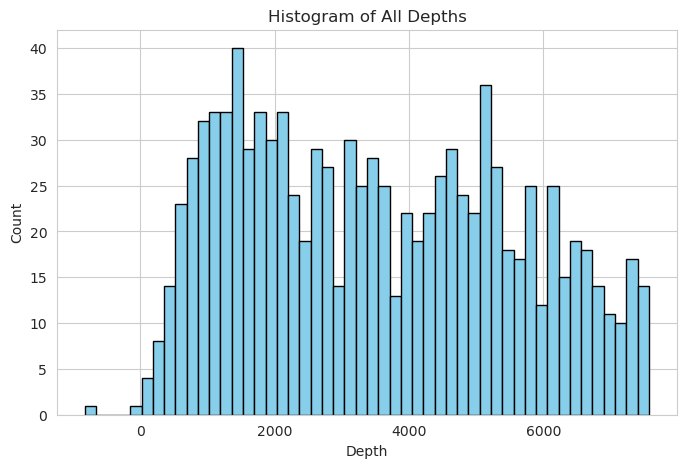

Insertion IDs with depth > 0: [9, 24]
Neuron (insertion_idx, neuron_idx, unit_id_in_spike_times, region, opercular) with depth > 0:
{'insertion_idx': 9, 'neuron_idx': 3, 'unit_id_in_spike_times': 30, 'region': 'aMTG', 'opercular': 1}
{'insertion_idx': 24, 'neuron_idx': 22, 'unit_id_in_spike_times': 491, 'region': 'vPrCG', 'opercular': 1}


In [85]:
# histogram plot
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

plt.figure(figsize=(8,5))
plt.hist([d for session_depths in depthAll for d in session_depths], bins=50, color='skyblue', edgecolor='k')
plt.xlabel('Depth')
plt.ylabel('Count')
plt.title('Histogram of All Depths')
#plt.savefig("depth_histogram.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Find the insertion indices where any neuron has depth > 0
insertion_ids_with_depth_gt_0 = []
for i, session_depths in enumerate(depthAll):
    if any(d < 0 for d in session_depths):
        insertion_ids_with_depth_gt_0.append(i)
print("Insertion IDs with depth > 0:", insertion_ids_with_depth_gt_0)

# Find the indices (in terms of insertion index and neuron index) where neuron depth > 0
# Also show region and opercular status
neuron_ids_with_depth_gt_0 = []
for insertion_idx, session_depths in enumerate(depthAll):
    for neuron_idx, d in enumerate(session_depths):
        if d < 0:
            # Try to extract the original unit_id from indicesAll if available
            try:
                unit_id = indicesAll[insertion_idx][neuron_idx]
            except Exception:
                unit_id = None
            # Try to extract region and opercular status
            try:
                region = region_list[insertion_idx]
            except Exception:
                region = None
            try:
                opercular_status = opercular_list[insertion_idx]
            except Exception:
                opercular_status = None

            neuron_ids_with_depth_gt_0.append({
                'insertion_idx': insertion_idx,
                'neuron_idx': neuron_idx,
                'unit_id_in_spike_times': unit_id,
                'region': region,
                'opercular': opercular_status
            })
print("Neuron (insertion_idx, neuron_idx, unit_id_in_spike_times, region, opercular) with depth > 0:")
for n in neuron_ids_with_depth_gt_0:
    print(n)


In [86]:
# CLUSTERING ANALYSIS - prepare data > define metrics > collect and standardize > cluster



# 1. prepare data
print("\n=== PREPARING DATA FOR CLUSTERING ===")

# Flatten all data into single arrays
waveforms_flat = []
firing_rates_flat = []
bursting_metrics_flat = []
autocorr_vectors_flat = []
spike_times_flat = []  # NEW: Flatten spike times
metadata_flat = []

for insertion_idx in range(len(waveformAll)):
    for neuron_idx in range(len(waveformAll[insertion_idx])):
        waveforms_flat.append(waveformAll[insertion_idx][neuron_idx])
        firing_rates_flat.append(firingRatesAll[insertion_idx][neuron_idx])
        bursting_metrics_flat.append(burstingMetricsAll[insertion_idx][neuron_idx])
        autocorr_vectors_flat.append(autocorrVectorsAll[insertion_idx][neuron_idx])
        spike_times_flat.append(spikeTimesAll[insertion_idx][neuron_idx])  # NEW
        
        metadata_flat.append({
            'insertion_idx': insertion_idx,
            'unit_id': indicesAll[insertion_idx][neuron_idx],  # Store unit_id for proper matching
            'subj': subj_list[insertion_idx],
            'grade': grade_list[insertion_idx],
            'pathology': path_list[insertion_idx],
            'yield': yield_list[insertion_idx],
            'opercular': opercular_list[insertion_idx],
            'region': region_list[insertion_idx],
            'age': age_list[insertion_idx],
            'gender': gender_list[insertion_idx],
            'depth': depthAll[insertion_idx][neuron_idx]
        })

# Convert to numpy arrays
waveforms_array = np.array(waveforms_flat)
firing_rates_array = np.array(firing_rates_flat)
autocorr_vectors_array = np.array(autocorr_vectors_flat)

print(f"Total neurons: {len(waveforms_flat)}")
print(f"Waveform array shape: {waveforms_array.shape}")
print(f"Firing rates array shape: {firing_rates_array.shape}")
print(f"Autocorr vectors array shape: {autocorr_vectors_array.shape}")
print(f"Spike times data: {len(spike_times_flat)} neurons")  # NEW

# Extract individual bursting metrics
burst_indices = np.array([bm['burst_index'] for bm in bursting_metrics_flat])
refractory_violations = np.array([bm['refractory_violation'] for bm in bursting_metrics_flat])
burst_peak_heights = np.array([bm['burst_peak_height'] for bm in bursting_metrics_flat])
burst_peak_widths = np.array([bm['burst_peak_width'] for bm in bursting_metrics_flat])
autocorr_skewness = np.array([bm['autocorr_skewness'] for bm in bursting_metrics_flat])
short_isi_ratios = np.array([bm['short_isi_ratio'] for bm in bursting_metrics_flat])

print(f"\nBursting metrics extracted:")
print(f"Burst indices: mean={np.mean(burst_indices):.3f}, std={np.std(burst_indices):.3f}")
print(f"Refractory violations: mean={np.mean(refractory_violations):.3f}, std={np.std(refractory_violations):.3f}")
print(f"Burst peak heights: mean={np.mean(burst_peak_heights):.3f}, std={np.std(burst_peak_heights):.3f}")
print(f"Burst peak widths: mean={np.mean(burst_peak_widths):.3f}, std={np.std(burst_peak_widths):.3f}")
print(f"Autocorr skewness: mean={np.mean(autocorr_skewness):.3f}, std={np.std(autocorr_skewness):.3f}")
print(f"Short ISI ratios: mean={np.mean(short_isi_ratios):.3f}, std={np.std(short_isi_ratios):.3f}")

# Standardize waveforms
waveform_scaler = StandardScaler()
waveforms_scaled = waveform_scaler.fit_transform(waveforms_array)
print(f"\nWaveforms standardized: shape={waveforms_scaled.shape}")

# Prepare spiking data (firing rates + bursting metrics)
spiking_data = np.column_stack([
    firing_rates_array,
    burst_indices,
    refractory_violations,
    burst_peak_heights,
    burst_peak_widths,
    autocorr_skewness,
    short_isi_ratios
])

# Standardize spiking data
spiking_scaler = StandardScaler()
spiking_data_scaled = spiking_scaler.fit_transform(spiking_data)
print(f"Spiking data standardized: shape={spiking_data_scaled.shape}")

# Prepare combined data (waveforms + spiking metrics)
# First standardize each component separately, then combine
combined_data = np.column_stack([
    waveforms_scaled,
    spiking_data_scaled
])

print(f"Combined data prepared: shape={combined_data.shape}")
print("Data preparation complete!")



### 2. Define metrics
# COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS
# Based on literature review for distinguishing interneurons vs pyramidal neurons

print("\n=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===")
print("Selected metrics based on literature review:")
print("Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time")
print("Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation")

# Import additional libraries for comprehensive analysis
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.patches as mpatches

def calculate_spike_width(waveform):
    """Calculate spike width (trough-to-peak duration)"""
    # Find peak and trough
    peak_idx = np.argmax(waveform)
    trough_idx = np.argmin(waveform)
    
    # Calculate width in samples (assuming 30kHz sampling rate)
    width_samples = abs(peak_idx - trough_idx)
    width_ms = width_samples / 30.0  # Convert to milliseconds
    
    return width_ms

def calculate_spike_amplitude(waveform):
    """Calculate spike amplitude (peak-to-trough amplitude).
    Returns positive if abs(peak) > abs(trough), negative if abs(trough) > abs(peak)."""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    amplitude = peak_amp - trough_amp
    if abs(trough_amp) > abs(peak_amp):
        amplitude = -abs(amplitude)
    return amplitude

def calculate_spike_asymmetry(waveform):
    """Calculate spike asymmetry (peak/trough ratio)"""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    
    # Avoid division by zero
    if abs(trough_amp) < 1e-10:
        return np.inf
    
    asymmetry = abs(peak_amp / trough_amp)
    return asymmetry

def calculate_spike_rise_time(waveform):
    """Calculate spike rise time (baseline to peak)"""
    # Find baseline (first 10% of waveform)
    baseline_end = len(waveform) // 10
    baseline = np.mean(waveform[:baseline_end])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going up
    rising_phase = waveform[:peak_idx]
    baseline_crossings = np.where(np.diff(np.sign(rising_phase - baseline)) > 0)[0]
    
    if len(baseline_crossings) > 0:
        rise_start = baseline_crossings[-1]  # Last crossing before peak
        rise_time_samples = peak_idx - rise_start
        rise_time_ms = rise_time_samples / 30.0  # Convert to milliseconds
    else:
        rise_time_ms = peak_idx / 30.0  # Fallback
    
    return rise_time_ms

def calculate_spike_decay_time(waveform):
    """Calculate spike decay time (peak to baseline)"""
    # Find baseline (last 10% of waveform)
    baseline_start = int(len(waveform) * 0.9)
    baseline = np.mean(waveform[baseline_start:])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going down after peak
    decay_phase = waveform[peak_idx:]
    baseline_crossings = np.where(np.diff(np.sign(decay_phase - baseline)) < 0)[0]
    
    if len(baseline_crossings) > 0:
        decay_end = baseline_crossings[0]  # First crossing after peak
        decay_time_samples = decay_end
        decay_time_ms = decay_time_samples / 30.0  # Convert to milliseconds
    else:
        decay_time_ms = (len(waveform) - peak_idx) / 30.0  # Fallback
    
    return decay_time_ms

def calculate_isi_cv(spike_times):
    """Calculate ISI coefficient of variation"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    if len(isis) == 0:
        return 0
    
    mean_isi = np.mean(isis)
    if mean_isi == 0:
        return 0
    
    cv = np.std(isis) / mean_isi
    return cv

def calculate_isi_violation_rate(spike_times, refractory_period=0.002):
    """Calculate ISI violation rate (spikes within refractory period)"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    violations = np.sum(isis < refractory_period)
    total_spikes = len(spike_times)
    
    violation_rate = violations / total_spikes if total_spikes > 0 else 0
    return violation_rate

def calculate_spike_frequency_adaptation(spike_times, window_size=1.0):
    """Calculate spike frequency adaptation"""
    if len(spike_times) < 10:
        return 0
    
    # Divide spike train into windows
    total_time = spike_times[-1] - spike_times[0]
    n_windows = int(total_time / window_size)
    
    if n_windows < 2:
        return 0
    
    window_firing_rates = []
    for i in range(n_windows):
        window_start = spike_times[0] + i * window_size
        window_end = window_start + window_size
        
        spikes_in_window = np.sum((spike_times >= window_start) & (spike_times < window_end))
        firing_rate = spikes_in_window / window_size
        window_firing_rates.append(firing_rate)
    
    if len(window_firing_rates) < 2:
        return 0
    
    # Calculate adaptation as decrease in firing rate over time
    early_rate = np.mean(window_firing_rates[:len(window_firing_rates)//2])
    late_rate = np.mean(window_firing_rates[len(window_firing_rates)//2:])
    
    if early_rate == 0:
        return 0
    
    adaptation = (early_rate - late_rate) / early_rate
    return adaptation

print("Spike characteristic calculation functions defined!")



### 3. Collect and standarize spike metrics
# COLLECT COMPREHENSIVE SPIKE CHARACTERISTICS DATA (CORRECTED VERSION)
print("\n=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===")

# Initialize lists for comprehensive characteristics
comprehensive_waveform_metrics = []
comprehensive_firing_rate_metrics = []
comprehensive_metadata = []

print("Processing all neurons for comprehensive spike characteristics...")

# Process each neuron to extract comprehensive metrics
for neuron_idx in range(len(waveforms_flat)):
    if neuron_idx % 100 == 0:
        print(f"Processing neuron {neuron_idx+1}/{len(waveforms_flat)}")
    
    # Get waveform
    waveform = waveforms_flat[neuron_idx]
    
    # Calculate waveform characteristics
    spike_width = calculate_spike_width(waveform)
    spike_amplitude = calculate_spike_amplitude(waveform)
    spike_asymmetry = calculate_spike_asymmetry(waveform)
    spike_rise_time = calculate_spike_rise_time(waveform)
    spike_decay_time = calculate_spike_decay_time(waveform)
    
    waveform_metrics = [spike_width, spike_amplitude, spike_asymmetry, spike_rise_time, spike_decay_time]
    comprehensive_waveform_metrics.append(waveform_metrics)
    
    # Get firing rate characteristics
    firing_rate = firing_rates_flat[neuron_idx]
    burst_index = bursting_metrics_flat[neuron_idx]['burst_index']
    
    # Calculate additional firing rate characteristics using actual spike times
    spike_times_unit = spike_times_flat[neuron_idx]
    
    # Calculate ISI CV from actual spike times
    isi_cv = calculate_isi_cv(spike_times_unit)
    
    # Calculate ISI violation rate from actual spike times
    isi_violation_rate = calculate_isi_violation_rate(spike_times_unit)
    
    # Calculate spike frequency adaptation from actual spike times
    spike_frequency_adaptation = calculate_spike_frequency_adaptation(spike_times_unit)
    
    firing_rate_metrics = [firing_rate, burst_index, isi_cv, isi_violation_rate, spike_frequency_adaptation]
    comprehensive_firing_rate_metrics.append(firing_rate_metrics)
    
    # Store metadata
    comprehensive_metadata.append(metadata_flat[neuron_idx])

# Convert to numpy arrays
comprehensive_waveform_array = np.array(comprehensive_waveform_metrics)
comprehensive_firing_rate_array = np.array(comprehensive_firing_rate_metrics)

print(f"\nComprehensive metrics collected:")
print(f"Waveform metrics shape: {comprehensive_waveform_array.shape}")
print(f"Firing rate metrics shape: {comprehensive_firing_rate_array.shape}")

# Display summary statistics
waveform_metric_names = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_metric_names = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']

print("\nWaveform Metrics Summary:")
for i, name in enumerate(waveform_metric_names):
    mean_val = np.mean(comprehensive_waveform_array[:, i])
    std_val = np.std(comprehensive_waveform_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nFiring Rate Metrics Summary:")
for i, name in enumerate(firing_rate_metric_names):
    mean_val = np.mean(comprehensive_firing_rate_array[:, i])
    std_val = np.std(comprehensive_firing_rate_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nComprehensive data collection complete!")

# STANDARDIZE COMPREHENSIVE METRICS AND PREPARE FOR CLUSTERING
print("\n=== STANDARDIZING COMPREHENSIVE METRICS ===")

# Standardize waveform metrics
waveform_scaler_comprehensive = StandardScaler()
comprehensive_waveform_scaled = waveform_scaler_comprehensive.fit_transform(comprehensive_waveform_array)

# Standardize firing rate metrics
firing_rate_scaler_comprehensive = StandardScaler()
comprehensive_firing_rate_scaled = firing_rate_scaler_comprehensive.fit_transform(comprehensive_firing_rate_array)

# Create combined dataset
comprehensive_combined_data = np.column_stack([
    comprehensive_waveform_scaled,
    comprehensive_firing_rate_scaled
])

print(f"Standardized waveform metrics shape: {comprehensive_waveform_scaled.shape}")
print(f"Standardized firing rate metrics shape: {comprehensive_firing_rate_scaled.shape}")
print(f"Combined comprehensive data shape: {comprehensive_combined_data.shape}")



### 4. CLUSTER
# Apply UMAP dimensionality reduction to comprehensive metrics
print("\n=== APPLYING UMAP TO COMPREHENSIVE METRICS ===")

# UMAP parameters
n_neighbors = 15
min_dist = 0.1
n_components = 2
random_state = 42

# UMAP on comprehensive waveform metrics
print("Applying UMAP to comprehensive waveform metrics...")
umap_waveform_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
waveform_comprehensive_umap = umap_waveform_comprehensive.fit_transform(comprehensive_waveform_scaled)

# UMAP on comprehensive firing rate metrics
print("Applying UMAP to comprehensive firing rate metrics...")
umap_firing_rate_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
firing_rate_comprehensive_umap = umap_firing_rate_comprehensive.fit_transform(comprehensive_firing_rate_scaled)

# UMAP on combined comprehensive data
print("Applying UMAP to combined comprehensive data...")
umap_combined_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
combined_comprehensive_umap = umap_combined_comprehensive.fit_transform(comprehensive_combined_data)

print(f"Comprehensive waveform UMAP shape: {waveform_comprehensive_umap.shape}")
print(f"Comprehensive firing rate UMAP shape: {firing_rate_comprehensive_umap.shape}")
print(f"Comprehensive combined UMAP shape: {combined_comprehensive_umap.shape}")

print("UMAP dimensionality reduction complete!")


=== PREPARING DATA FOR CLUSTERING ===
Total neurons: 1018
Waveform array shape: (1018, 90)
Firing rates array shape: (1018,)
Autocorr vectors array shape: (1018, 200)
Spike times data: 1018 neurons

Bursting metrics extracted:
Burst indices: mean=0.232, std=0.379
Refractory violations: mean=0.004, std=0.004
Burst peak heights: mean=0.019, std=0.021
Burst peak widths: mean=0.012, std=0.005
Autocorr skewness: mean=0.112, std=1.872
Short ISI ratios: mean=0.072, std=0.066

Waveforms standardized: shape=(1018, 90)
Spiking data standardized: shape=(1018, 7)
Combined data prepared: shape=(1018, 97)
Data preparation complete!

=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===
Selected metrics based on literature review:
Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time
Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation
Spike characteristic calculation functions defined!

=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===



=== COMPREHENSIVE CLUSTERING ANALYSIS ===

--- METHOD 1: UMAP + K-means Clustering ---
Testing optimal k for comprehensive waveform UMAP:
k=2: Silhouette Score = 0.570, Inertia = 20732.8
k=3: Silhouette Score = 0.579, Inertia = 10573.3
k=4: Silhouette Score = 0.639, Inertia = 4610.2
k=5: Silhouette Score = 0.652, Inertia = 2609.4
k=6: Silhouette Score = 0.620, Inertia = 1961.6
k=7: Silhouette Score = 0.622, Inertia = 1525.1
Optimal number of clusters: 5
Testing optimal k for comprehensive firing rate UMAP:
k=2: Silhouette Score = 0.414, Inertia = 7220.2
k=3: Silhouette Score = 0.458, Inertia = 4136.6
k=4: Silhouette Score = 0.453, Inertia = 2972.7
k=5: Silhouette Score = 0.437, Inertia = 2348.6
k=6: Silhouette Score = 0.418, Inertia = 1953.2
k=7: Silhouette Score = 0.398, Inertia = 1634.6
Optimal number of clusters: 3
Testing optimal k for comprehensive combined UMAP:
k=2: Silhouette Score = 0.563, Inertia = 8854.8
k=3: Silhouette Score = 0.646, Inertia = 2996.6
k=4: Silhouette Score 

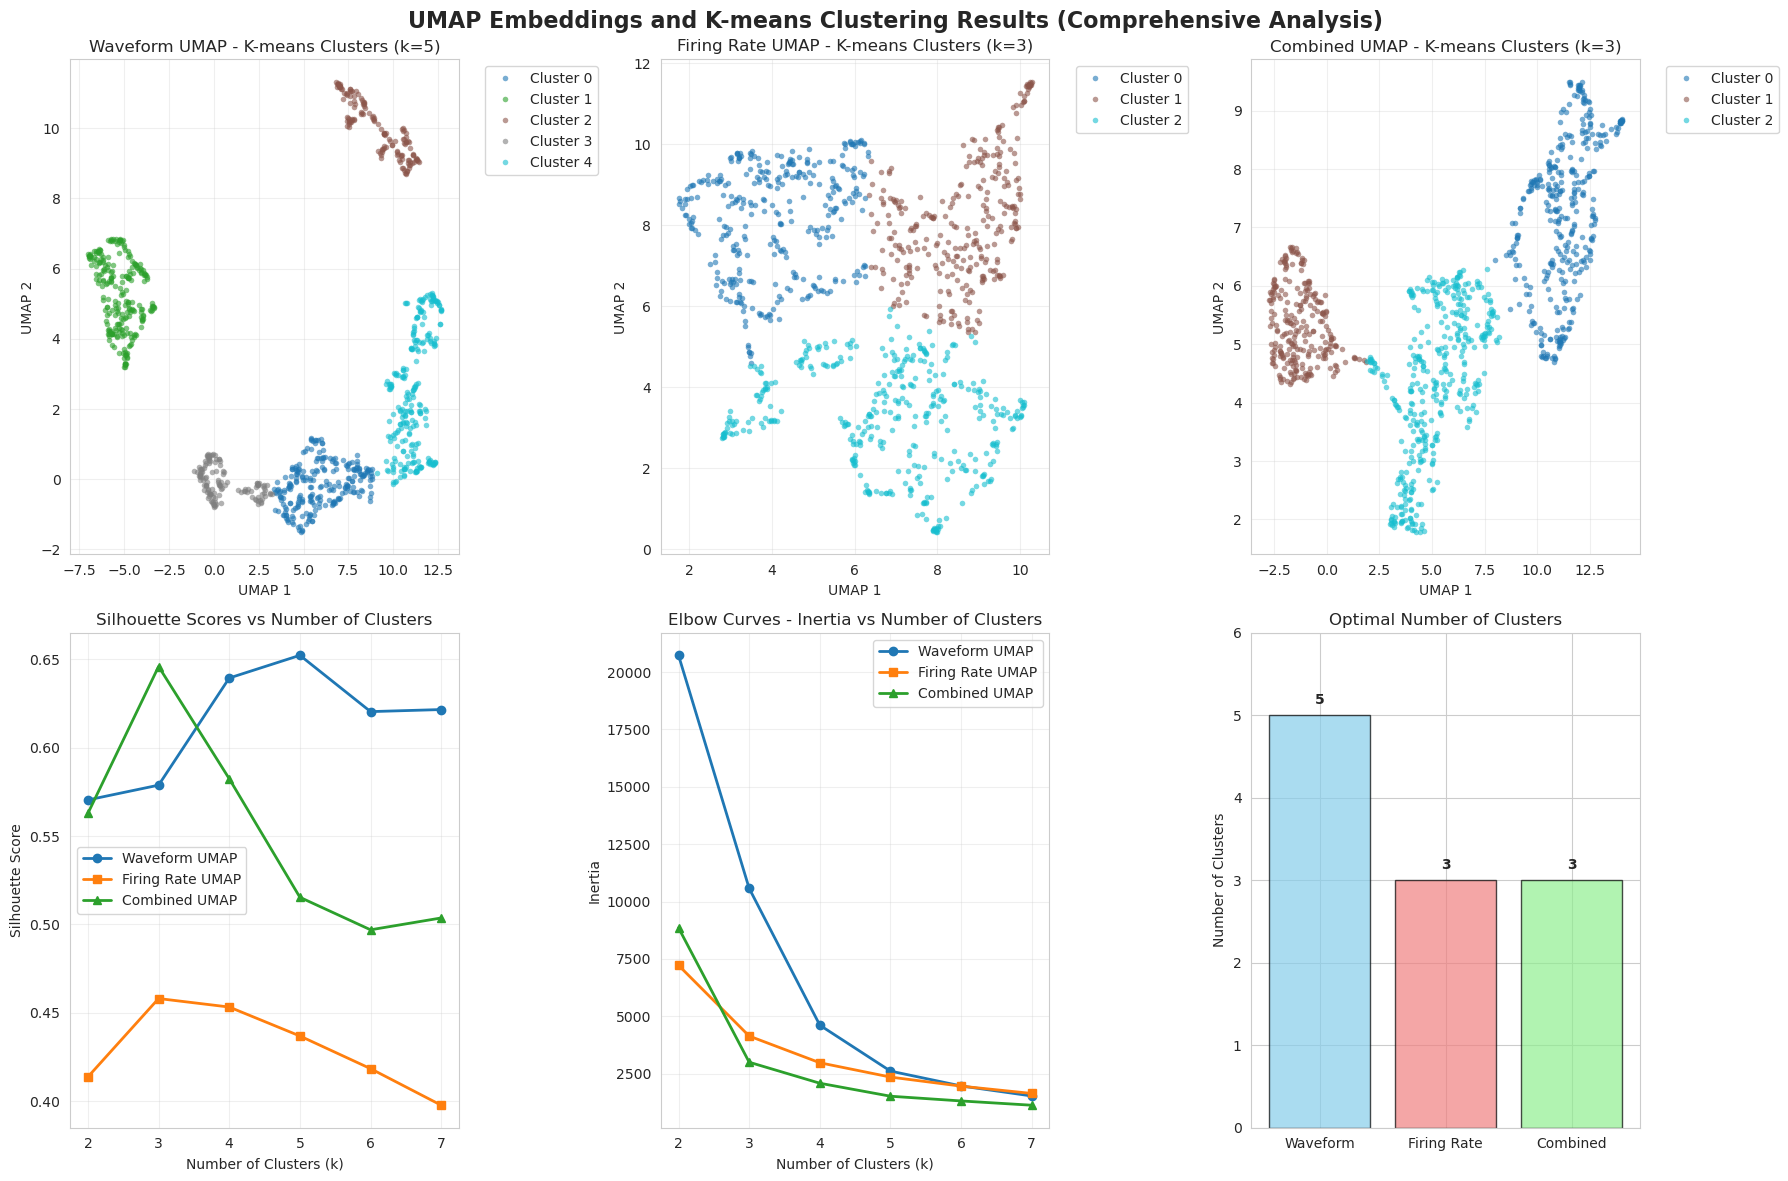


=== DETAILED CLUSTER ANALYSIS ===

Waveform UMAP Cluster Analysis:
  Cluster 0 (n=245):
    Waveform Metrics:
      Spike Width: 0.661 ± 0.094 ms
      Spike Amplitude: -46.626 ± 23.041
      Spike Asymmetry: 0.358 ± 0.154
      Rise Time: 0.349 ± 0.062 ms
      Decay Time: 1.061 ± 0.156 ms
    Firing Rate Metrics:
      Firing Rate: 4.23 ± 6.10 Hz
      Burst Index: 0.308 ± 0.591
      ISI CV: 2.126 ± 1.160
      ISI Violation Rate: 0.005 ± 0.005
      Spike Frequency Adaptation: -0.045 ± 0.804
  Cluster 1 (n=252):
    Waveform Metrics:
      Spike Width: 0.404 ± 0.141 ms
      Spike Amplitude: 57.563 ± 37.422
      Spike Asymmetry: 3.218 ± 1.242
      Rise Time: 0.290 ± 0.142 ms
      Decay Time: 0.199 ± 0.082 ms
    Firing Rate Metrics:
      Firing Rate: 6.04 ± 7.04 Hz
      Burst Index: 0.170 ± 0.155
      ISI CV: 2.965 ± 2.532
      ISI Violation Rate: 0.004 ± 0.004
      Spike Frequency Adaptation: -0.160 ± 0.638
  Cluster 2 (n=146):
    Waveform Metrics:
      Spike Width: 0.1

In [87]:
# COMPREHENSIVE CLUSTERING ANALYSIS
print("\n=== COMPREHENSIVE CLUSTERING ANALYSIS ===")

# Method 1: UMAP + K-means Clustering
print("\n--- METHOD 1: UMAP + K-means Clustering ---")

def find_optimal_k_comprehensive(data, k_range, method_name):
    """Find optimal number of clusters using silhouette score"""
    silhouette_scores = []
    inertias = []
    
    print(f"Testing optimal k for {method_name}:")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        
        silhouette_avg = silhouette_score(data, labels)
        inertia = kmeans.inertia_
        
        silhouette_scores.append(silhouette_avg)
        inertias.append(inertia)
        
        print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}, Inertia = {inertia:.1f}")
    
    optimal_k = k_range[np.argmax(silhouette_scores)]
    print(f"Optimal number of clusters: {optimal_k}")
    
    return optimal_k, silhouette_scores, inertias

# Test different k values
k_range = range(2, 8)

# Find optimal k for each UMAP embedding
optimal_k_waveform_comp, silhouette_scores_waveform_comp, inertias_waveform_comp = find_optimal_k_comprehensive(
    waveform_comprehensive_umap, k_range, "comprehensive waveform UMAP"
)

optimal_k_firing_rate_comp, silhouette_scores_firing_rate_comp, inertias_firing_rate_comp = find_optimal_k_comprehensive(
    firing_rate_comprehensive_umap, k_range, "comprehensive firing rate UMAP"
)

optimal_k_combined_comp, silhouette_scores_combined_comp, inertias_combined_comp = find_optimal_k_comprehensive(
    combined_comprehensive_umap, k_range, "comprehensive combined UMAP"
)

# Perform final clustering with optimal k values
print("\nPerforming final UMAP + K-means clustering...")

# Waveform clustering
kmeans_waveform_comp_final = KMeans(n_clusters=optimal_k_waveform_comp, random_state=42, n_init=10)
waveform_comp_labels = kmeans_waveform_comp_final.fit_predict(waveform_comprehensive_umap)
print(f"Comprehensive waveform clustering completed with {optimal_k_waveform_comp} clusters")

# Firing rate clustering
kmeans_firing_rate_comp_final = KMeans(n_clusters=optimal_k_firing_rate_comp, random_state=42, n_init=10)
firing_rate_comp_labels = kmeans_firing_rate_comp_final.fit_predict(firing_rate_comprehensive_umap)
print(f"Comprehensive firing rate clustering completed with {optimal_k_firing_rate_comp} clusters")

# Combined clustering
kmeans_combined_comp_final = KMeans(n_clusters=optimal_k_combined_comp, random_state=42, n_init=10)
combined_comp_labels = kmeans_combined_comp_final.fit_predict(combined_comprehensive_umap)
print(f"Comprehensive combined clustering completed with {optimal_k_combined_comp} clusters")

print("UMAP + K-means clustering complete!")



# VISUALIZE UMAP CLUSTERS FOR ALL METHODS WITH COLOR KEYS
print("\n=== UMAP CLUSTER VISUALIZATIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Create figure with subplots for all UMAP embeddings and clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('UMAP Embeddings and K-means Clustering Results (Comprehensive Analysis)', fontsize=16, fontweight='bold')

# Plot 1: Waveform UMAP with clustering
ax1 = axes[0, 0]
# Use plot instead of scatter for cleaner dots without outlines
for cluster_id in range(optimal_k_waveform_comp):
    mask = waveform_comp_labels == cluster_id
    ax1.plot(waveform_comprehensive_umap[mask, 0], waveform_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_waveform_comp - 1)),
             label=f'Cluster {cluster_id}')
ax1.set_title(f'Waveform UMAP - K-means Clusters (k={optimal_k_waveform_comp})')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Firing Rate UMAP with clustering
ax2 = axes[0, 1]
for cluster_id in range(optimal_k_firing_rate_comp):
    mask = firing_rate_comp_labels == cluster_id
    ax2.plot(firing_rate_comprehensive_umap[mask, 0], firing_rate_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_firing_rate_comp - 1)),
             label=f'Cluster {cluster_id}')
ax2.set_title(f'Firing Rate UMAP - K-means Clusters (k={optimal_k_firing_rate_comp})')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Combined UMAP with clustering
ax3 = axes[0, 2]
for cluster_id in range(optimal_k_combined_comp):
    mask = combined_comp_labels == cluster_id
    ax3.plot(combined_comprehensive_umap[mask, 0], combined_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_combined_comp - 1)),
             label=f'Cluster {cluster_id}')
ax3.set_title(f'Combined UMAP - K-means Clusters (k={optimal_k_combined_comp})')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 4: Silhouette scores comparison
ax4 = axes[1, 0]
ax4.plot(k_range, silhouette_scores_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax4.set_title('Silhouette Scores vs Number of Clusters')
ax4.set_xlabel('Number of Clusters (k)')
ax4.set_ylabel('Silhouette Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Elbow curves comparison
ax5 = axes[1, 1]
ax5.plot(k_range, inertias_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax5.set_title('Elbow Curves - Inertia vs Number of Clusters')
ax5.set_xlabel('Number of Clusters (k)')
ax5.set_ylabel('Inertia')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Cluster size comparison
ax6 = axes[1, 2]
cluster_counts = [optimal_k_waveform_comp, optimal_k_firing_rate_comp, optimal_k_combined_comp]
methods = ['Waveform', 'Firing Rate', 'Combined']
colors = ['skyblue', 'lightcoral', 'lightgreen']

bars = ax6.bar(methods, cluster_counts, color=colors, alpha=0.7, edgecolor='black')
ax6.set_title('Optimal Number of Clusters')
ax6.set_ylabel('Number of Clusters')
ax6.set_ylim(0, max(cluster_counts) + 1)

# Add value labels on bars
for bar, count in zip(bars, cluster_counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("cluster_results.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed cluster analysis
print("\n=== DETAILED CLUSTER ANALYSIS ===")

def analyze_cluster_characteristics_comprehensive(labels, data_name, n_clusters, waveform_data, firing_rate_data):
    """Analyze characteristics of each cluster"""
    print(f"\n{data_name} Cluster Analysis:")
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_size = np.sum(cluster_mask)
        
        if cluster_size > 0:
            # Analyze waveform characteristics for this cluster
            cluster_waveform_metrics = comprehensive_waveform_array[cluster_mask]
            cluster_firing_rate_metrics = comprehensive_firing_rate_array[cluster_mask]
            
            print(f"  Cluster {cluster_id} (n={cluster_size}):")
            
            # Waveform characteristics
            print(f"    Waveform Metrics:")
            print(f"      Spike Width: {np.mean(cluster_waveform_metrics[:, 0]):.3f} ± {np.std(cluster_waveform_metrics[:, 0]):.3f} ms")
            print(f"      Spike Amplitude: {np.mean(cluster_waveform_metrics[:, 1]):.3f} ± {np.std(cluster_waveform_metrics[:, 1]):.3f}")
            print(f"      Spike Asymmetry: {np.mean(cluster_waveform_metrics[:, 2]):.3f} ± {np.std(cluster_waveform_metrics[:, 2]):.3f}")
            print(f"      Rise Time: {np.mean(cluster_waveform_metrics[:, 3]):.3f} ± {np.std(cluster_waveform_metrics[:, 3]):.3f} ms")
            print(f"      Decay Time: {np.mean(cluster_waveform_metrics[:, 4]):.3f} ± {np.std(cluster_waveform_metrics[:, 4]):.3f} ms")
            
            # Firing rate characteristics
            print(f"    Firing Rate Metrics:")
            print(f"      Firing Rate: {np.mean(cluster_firing_rate_metrics[:, 0]):.2f} ± {np.std(cluster_firing_rate_metrics[:, 0]):.2f} Hz")
            print(f"      Burst Index: {np.mean(cluster_firing_rate_metrics[:, 1]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 1]):.3f}")
            print(f"      ISI CV: {np.mean(cluster_firing_rate_metrics[:, 2]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 2]):.3f}")
            print(f"      ISI Violation Rate: {np.mean(cluster_firing_rate_metrics[:, 3]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 3]):.3f}")
            print(f"      Spike Frequency Adaptation: {np.mean(cluster_firing_rate_metrics[:, 4]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 4]):.3f}")

# Analyze each clustering method
analyze_cluster_characteristics_comprehensive(waveform_comp_labels, "Waveform UMAP", optimal_k_waveform_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(firing_rate_comp_labels, "Firing Rate UMAP", optimal_k_firing_rate_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(combined_comp_labels, "Combined UMAP", optimal_k_combined_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)

print("\nUMAP cluster visualizations complete!")

In [ ]:
# BAR PLOTS FOR ALL VARIABLES BY CLUSTER WITH STATISTICAL TESTS
print("\n=== VARIABLE ANALYSIS BY CLUSTER ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu

# Define variable names
waveform_vars = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_vars = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']
all_vars = waveform_vars + firing_rate_vars

# Get the data arrays
waveform_data = comprehensive_waveform_array  # Shape: (n_neurons, 5)
firing_rate_data = comprehensive_firing_rate_array  # Shape: (n_neurons, 5)
combined_data = np.hstack([waveform_data, firing_rate_data])  # Shape: (n_neurons, 10)

# Get cluster labels
cluster_labels = combined_comp_labels

# Show cluster 0, 1, 2 for plotting,
# but only do statistical tests to compare cluster 1 and 2 (not including 0 in stats)
plot_cluster_ids = [0, 1, 2]
stats_cluster_ids = [1, 2]

# Create figure with subplots for all variables
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Variable Analysis by Cluster (Combined UMAP)', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Function to perform statistical tests
def perform_statistical_tests(data_cluster1, data_cluster2, test_name):
    """Perform t-test and Mann-Whitney U test"""
    if len(data_cluster1) == 0 or len(data_cluster2) == 0:
        return None, None
    
    # T-test
    t_stat, t_p = ttest_ind(data_cluster1, data_cluster2)
    
    # Mann-Whitney U test
    u_stat, u_p = mannwhitneyu(data_cluster1, data_cluster2, alternative='two-sided')
    
    return {'t_test': (t_stat, t_p), 'mannwhitney': (u_stat, u_p)}

# Plot each variable
for var_idx in range(10):
    ax = axes_flat[var_idx]
    
    # Get data for this variable
    var_data = combined_data[:, var_idx]
    
    # Calculate means and standard errors for each cluster (0, 1, 2)
    cluster_means = []
    cluster_stds = []
    cluster_sizes = []
    cluster_data = []
    
    for cluster_id in plot_cluster_ids:
        cluster_mask = cluster_labels == cluster_id
        cluster_var_data = var_data[cluster_mask]
        
        if len(cluster_var_data) > 0:
            cluster_means.append(np.mean(cluster_var_data))
            cluster_stds.append(np.std(cluster_var_data))
            cluster_sizes.append(len(cluster_var_data))
            cluster_data.append(cluster_var_data)
        else:
            cluster_means.append(0)
            cluster_stds.append(0)
            cluster_sizes.append(0)
            cluster_data.append(np.array([]))
    
    # Create bar plot
    x_pos = np.arange(len(plot_cluster_ids))
    bars = ax.bar(x_pos, cluster_means, yerr=cluster_stds, capsize=5, 
                  color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, mean, std, size) in enumerate(zip(bars, cluster_means, cluster_stds, cluster_sizes)):
        if size > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01, 
                   f'{mean:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # Perform statistical tests only between cluster 1 and 2, not including 0
    idx_1 = plot_cluster_ids.index(1)
    idx_2 = plot_cluster_ids.index(2)
    data_1 = cluster_data[idx_1]
    data_2 = cluster_data[idx_2]

    if len(data_1) > 0 and len(data_2) > 0:
        stats_results = perform_statistical_tests(data_1, data_2, all_vars[var_idx])
        
        if stats_results:
            t_stat, t_p = stats_results['t_test']
            u_stat, u_p = stats_results['mannwhitney']
            
            # Add significance annotation above clusters 1 & 2
            annotation_y = max(cluster_means[idx_1] + cluster_stds[idx_1], 
                               cluster_means[idx_2] + cluster_stds[idx_2]) + 0.05 * (
                max(cluster_means) - min(cluster_means)
            )
            significance = "***" if t_p < 0.001 else "**" if t_p < 0.01 else "*" if t_p < 0.05 else "ns"
            # Draw line and annotation between cluster 1 and 2
            ax.plot([1, 2], [annotation_y, annotation_y], color='k', linewidth=1)
            ax.text(1.5, annotation_y + 0.01, f"T-test p = {t_p:.4f} {significance}", 
                    ha='center', va='bottom', fontweight='bold', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Set plot properties
    ax.set_title(all_vars[var_idx], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Value')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Cluster {i}' for i in plot_cluster_ids])
    ax.grid(axis='y', alpha=0.3)
    
    # Print detailed statistics for all clusters
    print(f"\n{all_vars[var_idx]}:")
    for idx, cluster_id in enumerate(plot_cluster_ids):
        if cluster_sizes[idx] > 0:
            print(f"  Cluster {cluster_id}: mean = {cluster_means[idx]:.3f} ± {cluster_stds[idx]:.3f} (n={cluster_sizes[idx]})")
    
    # Print statistical test results for 1 vs 2 only
    if len(data_1) > 0 and len(data_2) > 0:
        print(f"  Cluster 1 vs 2: T-test p = {t_p:.4f}, Mann-Whitney p = {u_p:.4f}")

plt.tight_layout()
plt.savefig("summary_stats_clusters.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics table
print("\n=== SUMMARY STATISTICS TABLE ===")
header = "Variable".ljust(25) + "\t" + "\t".join([f"Cluster {i}" for i in plot_cluster_ids])
print(header)
print("-" * (len(header)+20))

for var_idx in range(10):
    var_name = all_vars[var_idx]
    padded_name = var_name.ljust(25)
    
    # Get cluster data for all clusters
    cluster_data_stats = []
    for cluster_id in plot_cluster_ids:
        cluster_mask = cluster_labels == cluster_id
        cluster_var_data = combined_data[cluster_mask, var_idx]
        cluster_data_stats.append(cluster_var_data)
    
    # Format means and standard deviations
    cluster_stats = []
    for idx in range(len(plot_cluster_ids)):
        if len(cluster_data_stats[idx]) > 0:
            mean_val = np.mean(cluster_data_stats[idx])
            std_val = np.std(cluster_data_stats[idx])
            cluster_stats.append(f"{mean_val:.3f} ± {std_val:.3f}")
        else:
            cluster_stats.append("N/A")
    
    print(f"{padded_name}\t" + "\t".join(cluster_stats))

# Statistical significance summary (just for 1 vs 2)
print("\n=== STATISTICAL SIGNIFICANCE SUMMARY (Cluster 1 vs 2) ===")
print("Variable\t\t\tT-test p-value\t\tMann-Whitney p-value")
print("-" * 70)

for var_idx in range(10):
    var_name = all_vars[var_idx]
    padded_name = var_name.ljust(25)
    
    # Get cluster data for 1 and 2 only
    cluster_mask_1 = cluster_labels == 1
    cluster_mask_2 = cluster_labels == 2
    cluster_data_1 = combined_data[cluster_mask_1, var_idx]
    cluster_data_2 = combined_data[cluster_mask_2, var_idx]
    
    if len(cluster_data_1) > 0 and len(cluster_data_2) > 0:
        # T-test
        t_stat, t_p = ttest_ind(cluster_data_1, cluster_data_2)
        
        # Mann-Whitney U test
        u_stat, u_p = mannwhitneyu(cluster_data_1, cluster_data_2, alternative='two-sided')
        
        print(f"{padded_name}\t{t_p:.4f}\t\t\t{u_p:.4f}")
    else:
        print(f"{padded_name}\tN/A\t\t\tN/A")

print("\nVariable analysis complete!")


=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===
Comprehensive visualization functions defined!

=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===

--- Combined UMAP + K-means Clustering ---


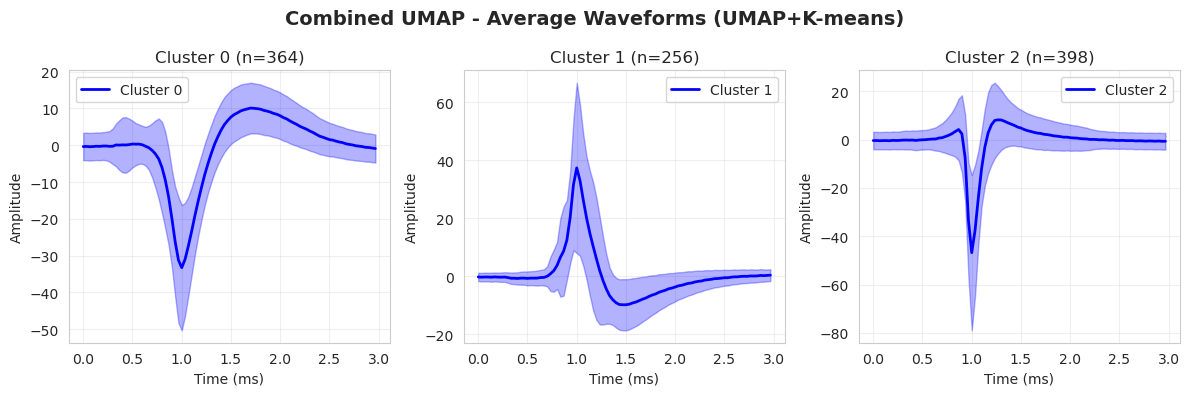

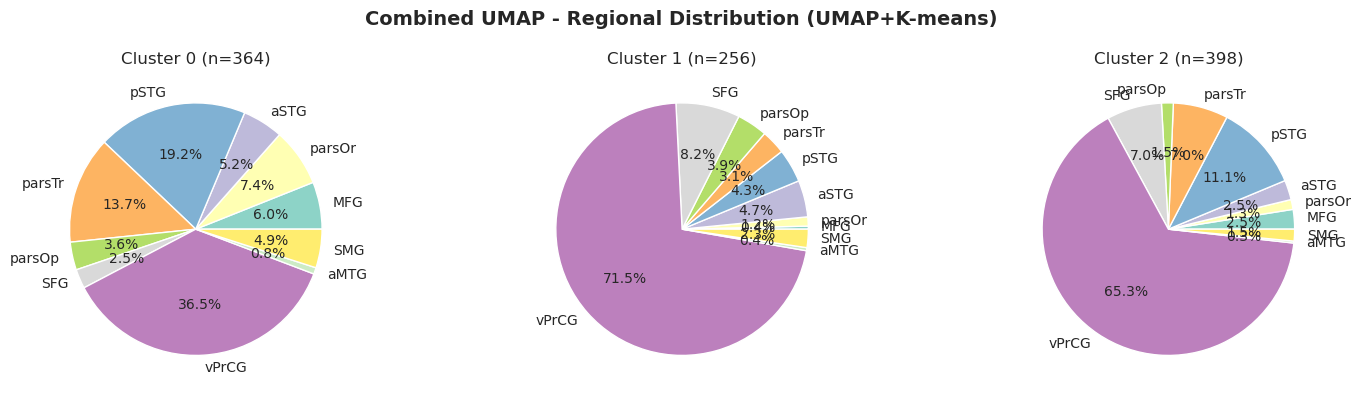

In [88]:
# Visualizaiton cell



#  1. DEFINE COMPREHENSIVE VISUALIZATION FUNCTIONS
print("\n=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

def plot_cluster_waveforms_comprehensive(labels, waveforms_array, title_prefix, n_clusters, method_name):
    """Plot average waveforms for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Average Waveforms ({method_name})', fontsize=14, fontweight='bold')
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_waveforms = waveforms_array[cluster_mask]
        
        if len(cluster_waveforms) > 0:
            # Calculate average waveform
            avg_waveform = np.mean(cluster_waveforms, axis=0)
            std_waveform = np.std(cluster_waveforms, axis=0)
            
            # Plot average waveform with error bars
            x_vals = np.arange(len(avg_waveform)) / 30.0  # Convert to ms
            axes[cluster_id].plot(x_vals, avg_waveform, 'b-', linewidth=2, label=f'Cluster {cluster_id}')
            axes[cluster_id].fill_between(x_vals, 
                                        avg_waveform - std_waveform, 
                                        avg_waveform + std_waveform, 
                                        alpha=0.3, color='blue')
            
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_waveforms)})')
            axes[cluster_id].set_xlabel('Time (ms)')
            axes[cluster_id].set_ylabel('Amplitude')
            axes[cluster_id].grid(True, alpha=0.3)
            axes[cluster_id].legend()
    
    plt.tight_layout()
    plt.savefig("cluster_waveforms.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

def plot_region_pie_charts(labels, metadata, title_prefix, n_clusters, method_name):
    """Plot pie charts showing regional distribution for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Regional Distribution ({method_name})', fontsize=14, fontweight='bold')
    
    # Get unique regions
    all_regions = [meta['region'] for meta in metadata]
    unique_regions = list(set(all_regions))
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_metadata = [metadata[i] for i in range(len(metadata)) if cluster_mask[i]]
        
        if len(cluster_metadata) > 0:
            # Count regions in this cluster
            cluster_regions = [meta['region'] for meta in cluster_metadata]
            region_counts = {region: cluster_regions.count(region) for region in unique_regions}
            
            # Create pie chart
            labels_pie = list(region_counts.keys())
            sizes = list(region_counts.values())
            colors = plt.cm.Set3(np.linspace(0, 1, len(labels_pie)))
            
            axes[cluster_id].pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors)
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_metadata)})')
    
    plt.tight_layout()
    plt.savefig("cluster_region.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

print("Comprehensive visualization functions defined!")



# 2. COMPREHENSIVE VISUALIZATIONS FOR UMAP + K-MEANS CLUSTERING
print("\n=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Convert waveforms_flat to numpy array for visualization
waveforms_array_for_viz = np.array(waveforms_flat)

# Combined UMAP + K-means visualizations
print("\n--- Combined UMAP + K-means Clustering ---")
plot_cluster_waveforms_comprehensive(combined_comp_labels, waveforms_array_for_viz, 
                                    "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
plot_region_pie_charts(combined_comp_labels, comprehensive_metadata, 
                      "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_depth_histograms(combined_comp_labels, comprehensive_metadata, 
#                     "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_subgroup_bar_charts(combined_comp_labels, comprehensive_metadata, 
#                        "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")



=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===
ET-dense regions: ['vPrCG', 'PoCG']
ET-sparse regions: ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']
ET-dense neurons: 576
ET-sparse neurons: 442

=== ET-DENSE REGIONS VISUALIZATION ===
Analyzing 576 neurons from ET-dense regions (vPrCG, PoCG)

--- ET-Dense: Waveform Analysis ---


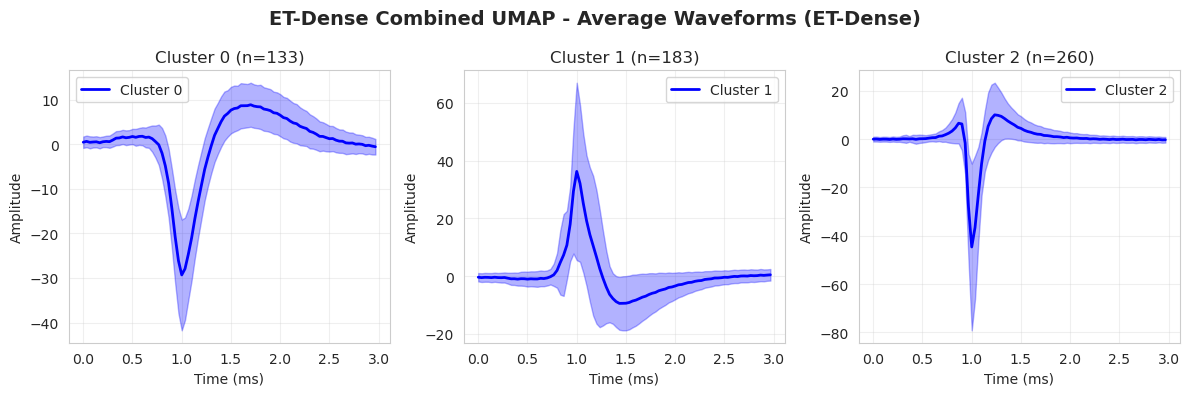


--- ET-Dense: Region Distribution ---


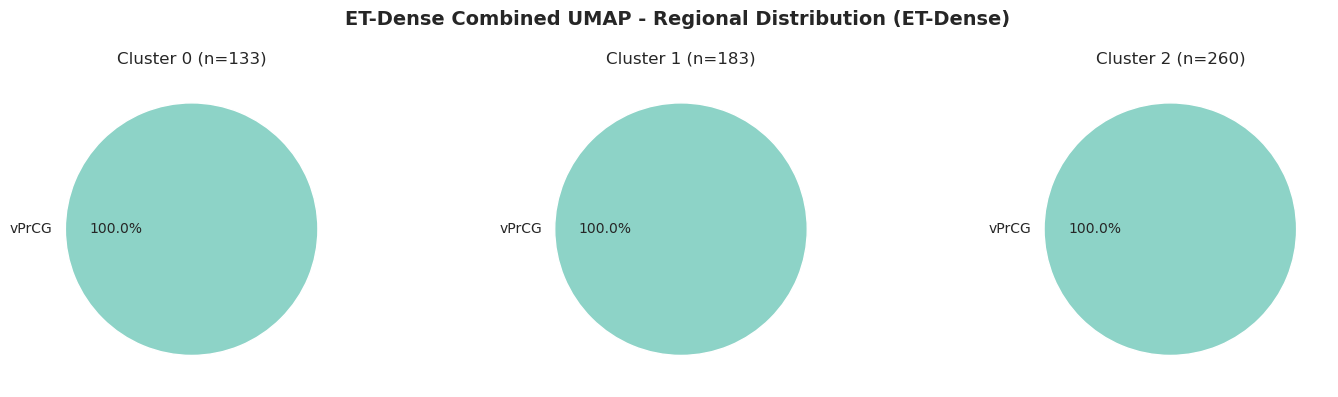


=== ET-SPARSE REGIONS VISUALIZATION ===
Analyzing 442 neurons from ET-sparse regions (all others)

--- ET-Sparse: Waveform Analysis ---


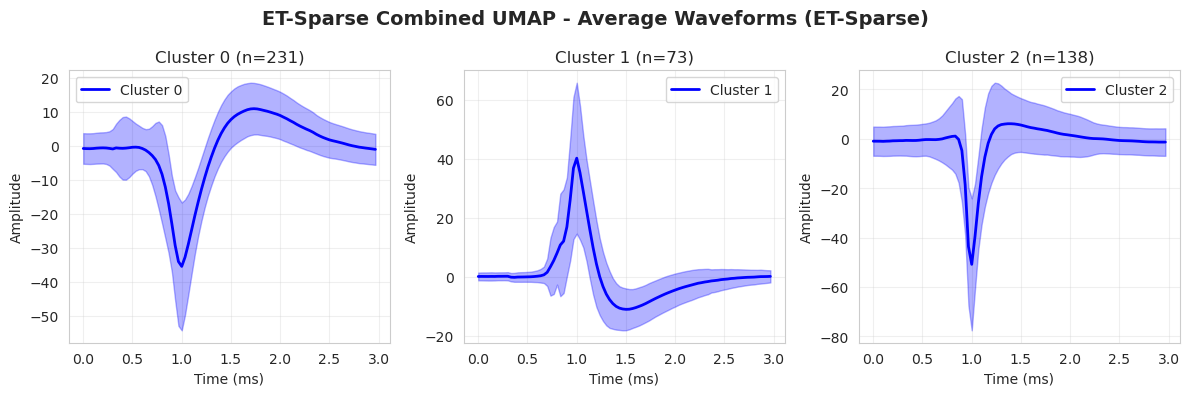


--- ET-Sparse: Region Distribution ---


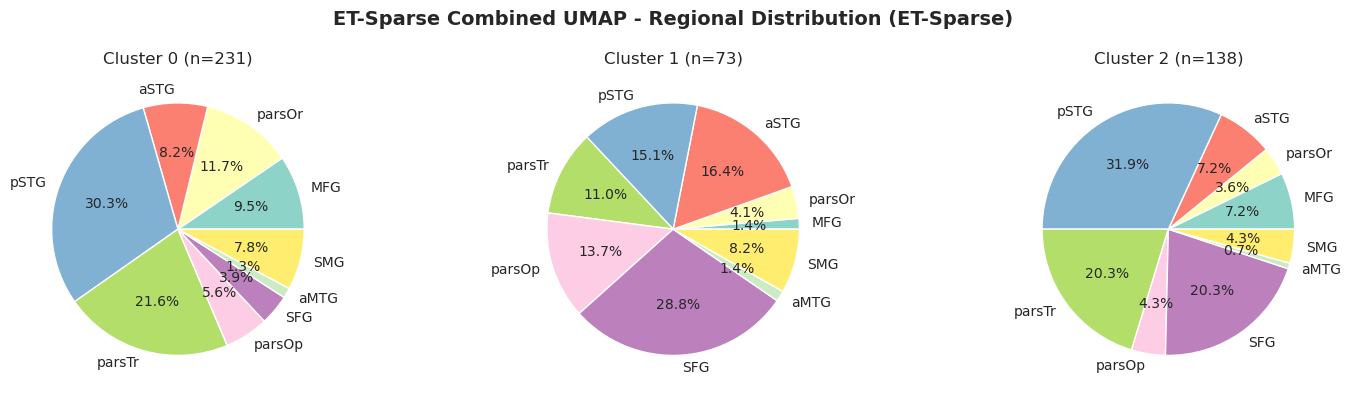

In [89]:
# ET sparse specific visualizations
print("\n=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===")



# 0. Define ET-dense and ET-sparse regions
et_dense_regions = ['vPrCG', 'PoCG']  # Motor and somatosensory cortex
et_sparse_regions = ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']

print(f"ET-dense regions: {et_dense_regions}")
print(f"ET-sparse regions: {et_sparse_regions}")

# Create masks for ET-dense and ET-sparse regions
et_dense_mask = np.array([neuron['region'] in et_dense_regions for neuron in comprehensive_metadata])
et_sparse_mask = np.array([neuron['region'] in et_sparse_regions for neuron in comprehensive_metadata])

print(f"ET-dense neurons: {np.sum(et_dense_mask)}")
print(f"ET-sparse neurons: {np.sum(et_sparse_mask)}")

# Separate the combined clustering data
et_dense_labels = combined_comp_labels[et_dense_mask]
et_sparse_labels = combined_comp_labels[et_sparse_mask]

et_dense_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_dense_mask[i]]
et_sparse_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_sparse_mask[i]]

et_dense_waveforms = waveforms_array_for_viz[et_dense_mask]
et_sparse_waveforms = waveforms_array_for_viz[et_sparse_mask]



# 1. ET-DENSE REGIONS VISUALIZATION
print("\n=== ET-DENSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_dense_labels)} neurons from ET-dense regions (vPrCG, PoCG)")

# 1. Waveform visualizations for ET-dense
print("\n--- ET-Dense: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_dense_labels, et_dense_waveforms, 
                                    "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")

# 2. Region pie charts for ET-dense
print("\n--- ET-Dense: Region Distribution ---")
plot_region_pie_charts(et_dense_labels, et_dense_metadata, 
                      "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")



# 2. ET-SPARSE REGIONS VISUALIZATION
print("\n=== ET-SPARSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_sparse_labels)} neurons from ET-sparse regions (all others)")

# 1. Waveform visualizations for ET-sparse
print("\n--- ET-Sparse: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_sparse_labels, et_sparse_waveforms, 
                                    "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

# 2. Region pie charts for ET-sparse
print("\n--- ET-Sparse: Region Distribution ---")
plot_region_pie_charts(et_sparse_labels, et_sparse_metadata, 
                      "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

PER-ASSEMBLY LOGISTIC REGRESSION — PRODUCTION REGIONS (parsOp, parsTr)
Prod vs baseline | information capacity computed locally
Running 1000 iterations with different baseline samples

Found 4 production-region insertions with ProdSpeechWords

Pre-computing assemblies and production-trial expression (4 insertions)...
  [1/4] insertion_idx=12 region=parsOp | NP128_B1.nwb | NP128_B1_g0_imec1_KS4_Th=12
    good neurons: 29
    rate matrix: T=83480 bins, N=29 neurons
    PCA+ICA done in 0.8s (5 assemblies)
  [2/4] insertion_idx=18 region=parsTr | NP139_B1.nwb | NP139_B1_g0_imec0_KS4
    good neurons: 34
    rate matrix: T=55840 bins, N=34 neurons
    PCA+ICA done in 0.7s (5 assemblies)
  [3/4] insertion_idx=20 region=parsTr | NP139_B2.nwb | NP139_B2_g0_imec0_KS4
    good neurons: 42
    rate matrix: T=25880 bins, N=42 neurons
    PCA+ICA done in 0.4s (5 assemblies)
  [4/4] insertion_idx=22 region=parsTr | NP150_B1.nwb | NP150_B1_g0_imec0_KS4_Th=12
    good neurons: 10
    rate matrix: T=45

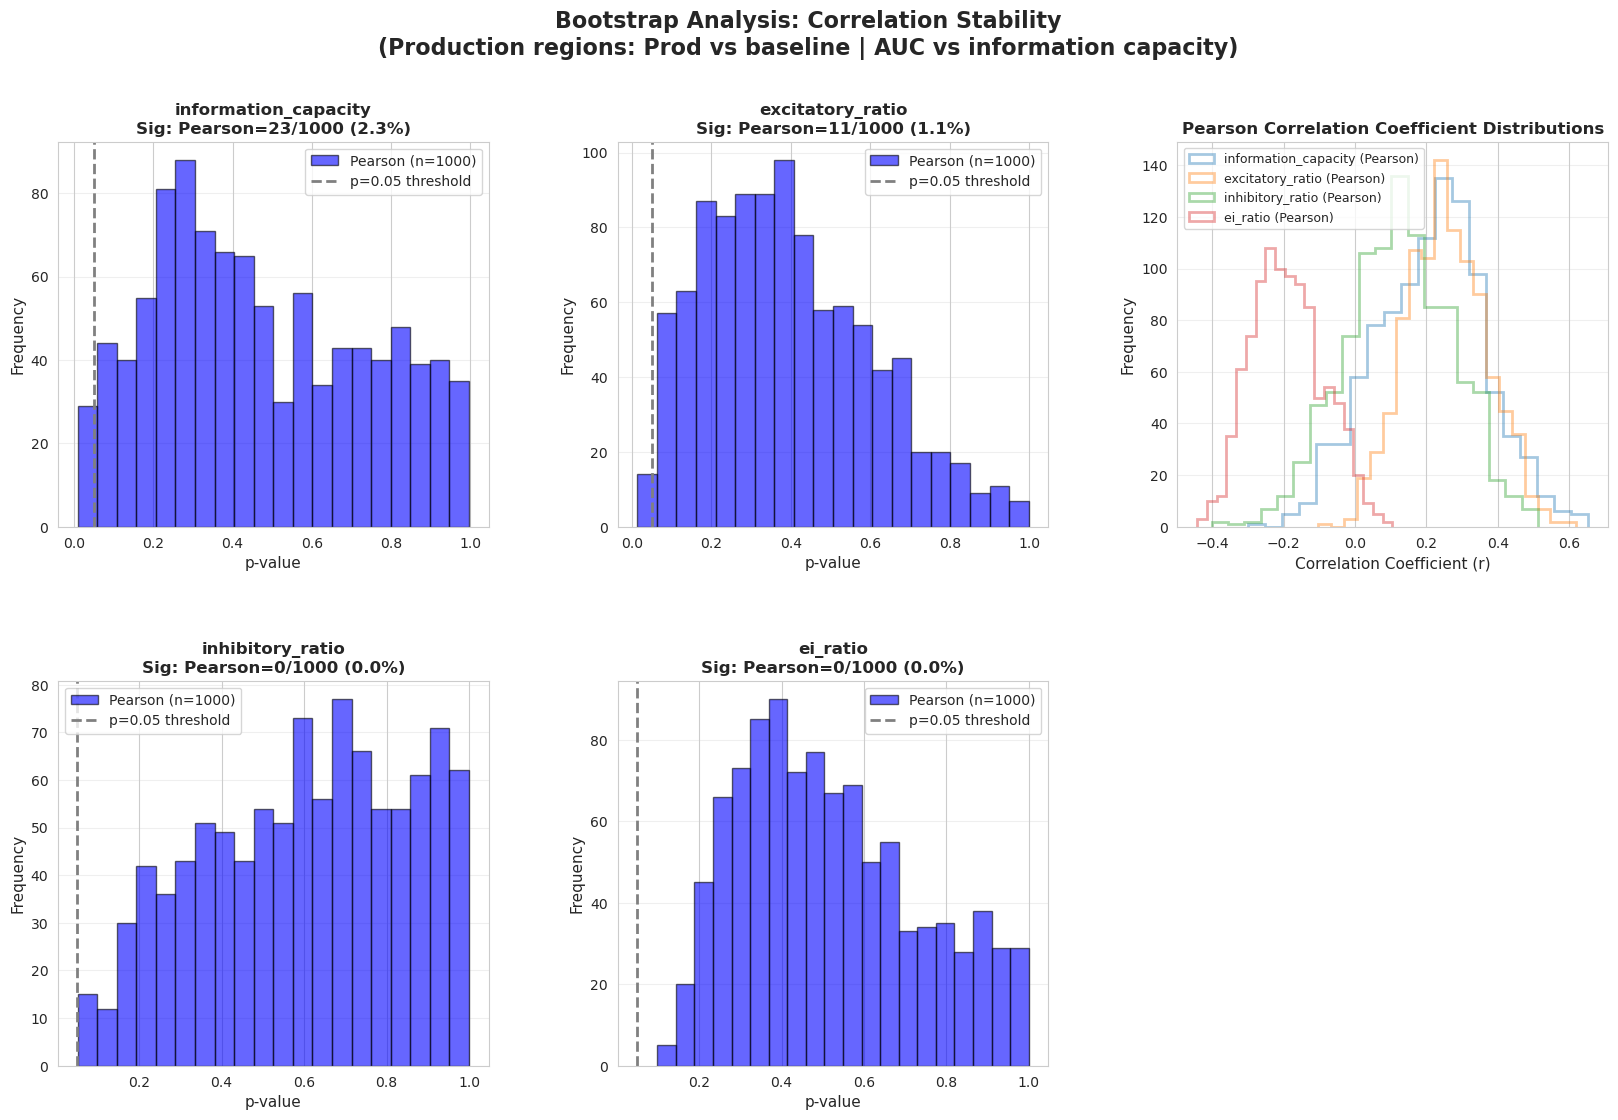


Created visualization showing p-value distributions and correlation stability

ANALYSIS COMPLETE


In [68]:
# [Live-sync header] Production-network bootstrap: ProdSpeechWords vs null baseline. Local information capacity; no E/I covariates.

# PER-ASSEMBLY LOGISTIC REGRESSION (LR) — BOOTSTRAP
# Production-network regions (vPrCG, parsOp, parsTr): speech PRODUCTION vs null/baseline.
# Classifier: logistic regression on ICA assembly coordinate (production trials vs baseline windows).
# Information capacity: computed locally per assembly (5_ensemble_4_information.ipynb method).
# All insertions included (FLAIR+ and FLAIR−); no E/I metrics.

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, kstest, spearmanr, pearsonr
from scipy.linalg import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.decomposition import FastICA
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import re
import fnmatch
import os
warnings.filterwarnings('ignore')

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("PER-ASSEMBLY LOGISTIC REGRESSION — PRODUCTION REGIONS (parsOp, parsTr)")
print("Prod vs baseline | information capacity computed locally")
print("Running 1000 iterations with different baseline samples")
print("=" * 80)

# Information capacity: computed locally (same method as 5_ensemble_4_information.ipynb)

def calculate_mutual_information(x, y, bins=20):
    """Mutual information between two variables (histogram), as in 5_ensemble_4_information.ipynb."""
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    if np.sum(valid_mask) < 2:
        return np.nan
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    hist_2d, _, _ = np.histogram2d(x_valid, y_valid, bins=bins)
    hist_x = np.sum(hist_2d, axis=1)
    hist_y = np.sum(hist_2d, axis=0)
    p_xy = hist_2d / np.sum(hist_2d)
    p_x = hist_x / np.sum(hist_x)
    p_y = hist_y / np.sum(hist_y)
    mi = 0.0
    for i in range(len(p_x)):
        for j in range(len(p_y)):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mi += p_xy[i, j] * np.log2(p_xy[i, j] / (p_x[i] * p_y[j]))
    return mi


def calculate_information_capacity(data, time_bins, min_samples=10):
    """Same method as 5_ensemble_4_information.ipynb (entropy minus temporal MI of assembly expression)."""
    valid_mask = ~np.isnan(data)
    if np.sum(valid_mask) < min_samples:
        return {
            'entropy': np.nan,
            'mutual_info_temporal': np.nan,
            'capacity': np.nan,
            'n_valid_samples': np.sum(valid_mask),
            'data_range': np.nan,
            'data_std': np.nan
        }
    valid_data = data[valid_mask]
    n_bins = min(20, len(valid_data) // 5)
    if n_bins < 5:
        n_bins = 5
    hist, _ = np.histogram(valid_data, bins=n_bins)
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]
    if len(prob) < 2:
        entropy_val = np.nan
    else:
        entropy_val = -np.sum(prob * np.log2(prob))
    if len(valid_data) > 1:
        try:
            mi_temporal = calculate_mutual_information(
                valid_data[:-1],
                valid_data[1:],
                bins=min(10, max(2, len(valid_data) // 10))
            )
        except Exception:
            mi_temporal = np.nan
    else:
        mi_temporal = np.nan
    if not np.isnan(entropy_val) and not np.isnan(mi_temporal):
        capacity = entropy_val - mi_temporal
    elif not np.isnan(entropy_val):
        capacity = entropy_val
    else:
        capacity = np.nan
    data_range = np.max(valid_data) - np.min(valid_data) if len(valid_data) > 0 else np.nan
    data_std = np.std(valid_data) if len(valid_data) > 0 else np.nan
    return {
        'entropy': entropy_val,
        'mutual_info_temporal': mi_temporal,
        'capacity': capacity,
        'n_valid_samples': np.sum(valid_mask),
        'data_range': data_range,
        'data_std': data_std
    }

def calculate_expression_strength(firingRateMatrix, ap_norm_matrix):
    """Calculate expression strength"""
    n_time_bins, n_neurons = firingRateMatrix.shape
    n_assemblies = ap_norm_matrix.shape[0]
    expression_strength = np.zeros((n_time_bins, n_assemblies))
    
    for assembly_idx in range(n_assemblies):
        weight_vector = ap_norm_matrix[assembly_idx, :]
        outer_product = np.outer(weight_vector, weight_vector)
        for time_bin in range(n_time_bins):
            firing_rate_vector = firingRateMatrix[time_bin, :]
            expression_strength[time_bin, assembly_idx] = firing_rate_vector.T @ outer_product @ firing_rate_vector
    
    return expression_strength

def imec_key_sorter(key):
    """Extract the number after 'imec'"""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

MIN_BEHAVIOR_MINUTES = 10.0

def _behavior_duration_seconds(task_times_obj):
    starts = np.asarray(task_times_obj.start, dtype=float).ravel()
    ends = np.asarray(task_times_obj.end, dtype=float).ravel()
    if starts.size != ends.size:
        return np.nan
    return float(np.sum(ends - starts))

def _ks_time_bounds_full_recording(spike_times_obj):
    """Min/max time for uniform KS (full recording)."""
    tmin, tmax = np.inf, -np.inf
    for u in range(len(spike_times_obj)):
        idx = spike_times_obj[u].as_series().index.values
        if len(idx):
            tmin = min(tmin, float(np.min(idx)))
            tmax = max(tmax, float(np.max(idx)))
    if np.isfinite(tmin) and np.isfinite(tmax):
        return tmin, tmax
    return np.nan, np.nan


def find_valid_baseline_windows(task_start, task_end, all_language_starts, all_language_ends, 
                                buffer, baseline_duration, bin_starts, bin_ends):
    """
    Pre-compute all valid baseline windows that don't overlap with language events.
    Returns list of (start, end) tuples for valid baseline periods.
    """
    valid_windows = []
    
    # Create a fine grid of potential start times
    step_size = 0.01  # 10ms steps
    potential_starts = np.arange(task_start, task_end - baseline_duration + step_size, step_size)
    
    for start_candidate in potential_starts:
        end_candidate = start_candidate + baseline_duration
        
        # Check if this window overlaps with any language event
        overlaps = False
        for lang_start, lang_end in zip(all_language_starts, all_language_ends):
            if not (end_candidate < lang_start - buffer or start_candidate > lang_end + buffer):
                overlaps = True
                break
        
        if not overlaps:
            # Check if we have bins that cover this window
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                valid_windows.append((start_candidate, end_candidate))
    
    return valid_windows

# Production-network insertions: parsOp, parsTr with ProdSpeechWords (all FLAIR groups), not including vPrCG
PRODUCTION_REGIONS = {'parsOp', 'parsTr'}
production_insertions = []
insertion_counter = 0

for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)
    
    for s in range(len(keys)):
        if insertion_counter < len(region_list):
            region = region_list[insertion_counter]
            if region in PRODUCTION_REGIONS:
                has_prod = "ProdSpeechWords" in data
                if has_prod:
                    production_insertions.append({
                        'nwb_idx': i,
                        'session_idx': s,
                        'insertion_idx': insertion_counter,
                        'region': region,
                    })
        insertion_counter += 1

print(f"\nFound {len(production_insertions)} production-region insertions with ProdSpeechWords")

# PRE-COMPUTE ALL ASSEMBLIES AND DATA (ONCE, OUTSIDE BOOTSTRAP LOOP)
n_ins_pre = len(production_insertions)
print(f"\nPre-computing assemblies and production-trial expression ({n_ins_pre} insertions)...", flush=True)

assembly_data = {}  # Store pre-computed data for each assembly

for ins_num, ins_info in enumerate(production_insertions, start=1):
    nwb_idx = ins_info['nwb_idx']
    session_idx = ins_info['session_idx']
    insertion_idx = ins_info['insertion_idx']
    region = ins_info['region']
    t_ins = time.perf_counter()
    # Load data first; keys[session_idx] must index this file's sorted analyzer list (printing before load used stale keys).
    data = nap.load_file(nwb_paths[nwb_idx])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[nwb_idx]) or 'NP139_B2' in str(nwb_paths[nwb_idx]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)

    if session_idx >= len(keys):
        print(f"  [{ins_num}/{n_ins_pre}] insertion_idx={insertion_idx} region={region} | {nwb_paths[nwb_idx].name} | SKIP: session_idx={session_idx} >= len(keys)={len(keys)}", flush=True)
        continue
    print(f"  [{ins_num}/{n_ins_pre}] insertion_idx={insertion_idx} region={region} | {nwb_paths[nwb_idx].name} | {keys[session_idx]}", flush=True)

    spike_times = data[keys[session_idx]]
    
    has_prod = "ProdSpeechWords" in data
    has_sens = "StimSpeechWords" in data
    
    if not has_prod:
        continue
    
    # Filter to good neurons (behavior length: full recording vs TaskTimes; KS matches R_EI.ipynb)
    firingRates_all = spike_times.metadata["rate"]
    if "TaskTimes" in data.keys():
        task_times = data["TaskTimes"]
    else:
        task_times = data["task_times"]

    start_time = task_times.start
    end_time = task_times.end
    beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)

    beh_sec = _behavior_duration_seconds(task_times)
    beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
    use_full_recording = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)

    if use_full_recording:
        spike_times_beh = spike_times
        firingRates_beh = firingRates_all
        min_time, max_time = _ks_time_bounds_full_recording(spike_times)
        if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
            print(f"  Short behavior ({beh_min:.2f} min) but could not get recording bounds; skipping insertion")
            continue
    else:
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]
        min_time = float(np.asarray(start_time).ravel()[0])
        max_time = float(np.asarray(end_time).ravel()[-1])

    ks_stats = np.zeros(len(spike_times))
    ks_pvals = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        test = spike_times[u].as_series().index.values
        if len(test) > 1:
            normalized_spike_times = (test - min_time) / (max_time - min_time)
            ks_result = kstest(normalized_spike_times, "uniform")
            ks_stats[u] = ks_result.statistic
            ks_pvals[u] = ks_result.pvalue
        else:
            ks_stats[u] = np.nan
            ks_pvals[u] = np.nan

    violationThreshold = 3/1000
    violationPct = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        unit = spike_times[u]
        unit = unit.as_series().index
        if len(unit) < 100:
            violationPct[u] = 1
        else:
            isi = unit.diff()[1:len(unit)]
            violations = np.where(isi<violationThreshold)
            violations = np.array(violations)
            violationPct[u] = violations.size/len(isi)
    
    if "KSLabel" in spike_times.metadata:
        KSLabels = spike_times.metadata["KSLabel"]
    else:
        KSLabels = spike_times.metadata["quality"]
    firingRates = firingRates_beh
    mask1 = violationPct<3/100
    mask2 = firingRates>0.5
    mask3 = KSLabels!="noise"
    mask4 = ks_stats < 0.3
    mask = mask1 & mask2 & mask3 & mask4
    indicesFinal = firingRates.index[mask]
    
    if insertion_idx < len(manual_exclude_lists):
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
    
    spike_times_good = spike_times[indicesFinal]
    n_neurons = len(spike_times_good)
    print(f"    good neurons: {n_neurons}", flush=True)

    if n_neurons == 0:
        continue

    # ---- E/I cluster labels for this insertion (aligned with indicesFinal order) ----
    # Requires et_sparse_labels and et_sparse_metadata from the E/I clustering section above.
    # Convention: excitatory = cluster 0, inhibitory = cluster 2 (cluster 1 = "other").
    insertion_cluster_labels = []
    if 'et_sparse_labels' in globals() and 'et_sparse_metadata' in globals():
        matching_neurons = [(idx, neuron) for idx, neuron in enumerate(et_sparse_metadata)
                            if neuron.get('insertion_idx') == insertion_idx]
        for local_neuron_idx in range(len(indicesFinal)):
            cluster_label = -1
            if local_neuron_idx < len(matching_neurons):
                global_idx = matching_neurons[local_neuron_idx][0]
                cluster_label = et_sparse_labels[global_idx]
            insertion_cluster_labels.append(cluster_label)
    else:
        print("    WARNING: et_sparse_labels/et_sparse_metadata not in globals -> using -1", flush=True)
        insertion_cluster_labels = [-1] * len(indicesFinal)
    insertion_cluster_labels = np.array(insertion_cluster_labels)

    # Make spike rate matrix
    timescale = 25/1000
    spikeCountMatrix = spike_times_good.count(bin_size=timescale)
    bin_edges = spikeCountMatrix.index.values
    bin_centers = bin_edges[:-1] + np.diff(bin_edges)/2
    if len(bin_centers) < len(bin_edges):
        last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
        last_center = bin_edges[-1] - last_width/2
        bin_centers = np.append(bin_centers, last_center)
    spikeCountMatrix = spikeCountMatrix.values
    firingRateMatrix = spikeCountMatrix/timescale
    firingRateMatrix = stats.zscore(firingRateMatrix, axis=0)
    print(f"    rate matrix: T={firingRateMatrix.shape[0]} bins, N={firingRateMatrix.shape[1]} neurons", flush=True)
    t_pca0 = time.perf_counter()
    # Calculate assemblies
    pca = PCA()
    firingRateMatrix_pca = pca.fit_transform(firingRateMatrix)
    eigenvalues = pca.explained_variance_
    upperbound = (1+np.sqrt(firingRateMatrix.shape[1]/firingRateMatrix.shape[0]))**2
    assemblyIndices = np.where(eigenvalues>upperbound)
    assemblyEigenvalues = eigenvalues[assemblyIndices]
    n_pcs = len(assemblyEigenvalues)
    
    if n_pcs == 0:
        continue
    
    # Orthogonalize with ICA
    pc_vectors = pca.components_[:n_pcs, :]
    projections = firingRateMatrix @ pc_vectors.T
    
    fastica = FastICA(n_components=n_pcs, algorithm='parallel', whiten='unit-variance',
                     max_iter=500, tol=1e-7, random_state=1)
    ica_components = fastica.fit_transform(projections)
    unmixing_matrix = fastica.components_
    ica_assembly_patterns = unmixing_matrix @ pc_vectors
    
    # Normalize assembly patterns
    ap_norm_matrix = ica_assembly_patterns.copy()
    for ii in range(n_pcs):
        ap = ica_assembly_patterns[ii,:]
        ap_norm = ap/norm(ap)
        maxW = max(ap_norm)
        minW = min(ap_norm)
        if abs(minW) > maxW:
            ap_norm = ap_norm*-1
        ap_norm_matrix[ii,:] = ap_norm
    
    print(f"    PCA+ICA done in {time.perf_counter() - t_pca0:.1f}s ({n_pcs} assemblies)", flush=True)
    # (skipped calculate_expression_strength: unused here and very slow)
    # Task boundaries for baseline (task_times already set above: TaskTimes vs task_times)
    if isinstance(task_times.start, np.ndarray):
        task_start = task_times.start[0]
        task_end = task_times.end[-1]
    else:
        task_start = task_times.start.values[0]
        task_end = task_times.end.values[-1]

    # Stimulus speech windows (exclude from baseline if present)
    if has_sens:
        sens_rel_start = 0
        sens_rel_end = 0.10
        speech_sens_times = data["StimSpeechWords"]
        sens_onsets = nap.Ts(speech_sens_times.start)
        sens_offsets = nap.Ts(speech_sens_times.end)
        sens_starts = (sens_onsets.as_series().index + sens_rel_start).values
        sens_ends = (sens_offsets.as_series().index + sens_rel_end).values
    else:
        sens_starts = np.array([])
        sens_ends = np.array([])

    # Production speech windows (positive class)
    prod_rel_start = -0.10
    prod_rel_end = 0
    speech_prod_times = data["ProdSpeechWords"]
    prod_onsets = nap.Ts(speech_prod_times.start)
    prod_offsets = nap.Ts(speech_prod_times.end)
    prod_starts = (prod_onsets.as_series().index + prod_rel_start).values
    prod_ends = (prod_offsets.as_series().index + prod_rel_end).values

    # Pre-compute bin boundaries
    bin_starts = bin_centers - timescale / 2
    bin_ends = bin_centers + timescale / 2

    # Baseline must avoid both reception and production speech
    all_language_starts = list(sens_starts) + list(prod_starts)
    all_language_ends = list(sens_ends) + list(prod_ends)
    
    buffer = 0.1
    baseline_duration = 0.1
    
    valid_baseline_windows = find_valid_baseline_windows(
        task_start, task_end, all_language_starts, all_language_ends,
        buffer, baseline_duration, bin_starts, bin_ends
    )
    
    # For each assembly, pre-compute everything except baseline sampling
    for asm_idx in range(n_pcs):
        assembly_expression = ica_components[:, asm_idx]
        
        cap_dict = calculate_information_capacity(assembly_expression, bin_centers, min_samples=10)
        info_capacity = cap_dict['capacity']

        # Production-trial expression values (same for all bootstrap iterations)
        prod_expression_values = []
        for u in range(len(prod_starts)):
            interval_start = prod_starts[u]
            interval_end = prod_ends[u]
            mask = (bin_starts >= interval_start) & (bin_ends <= interval_end)
            if np.any(mask):
                trial_expression = np.mean(assembly_expression[mask])
                prod_expression_values.append(trial_expression)

        # ---- E/I composition of this assembly ----
        # Convention: excitatory = cluster 0, inhibitory = cluster 2
        assembly_weights = ap_norm_matrix[asm_idx, :]
        excitatory_tone  = np.sum(assembly_weights[insertion_cluster_labels == 0])
        inhibitory_tone  = np.sum(assembly_weights[insertion_cluster_labels == 2])
        total_tone       = np.sum(np.abs(assembly_weights))
        excitatory_ratio = np.abs(excitatory_tone) / (total_tone + 1e-10)
        inhibitory_ratio = np.abs(inhibitory_tone) / (total_tone + 1e-10)
        if (excitatory_ratio < 0.01) or (inhibitory_ratio < 0.01):
            excitatory_ratio = np.nan
            inhibitory_ratio = np.nan
            ei_ratio = np.nan
            info_capacity = np.nan  # this affects all metrics for this assembly
            prod_expression_values = [np.nan for _ in prod_expression_values]
        else:
            ei_ratio = excitatory_ratio / (inhibitory_ratio + 1e-10)
   

        assembly_id = (insertion_idx, asm_idx)
        assembly_data[assembly_id] = {
            'insertion_idx': insertion_idx,
            'assembly_idx': asm_idx,
            'region': region,
            'assembly_expression': assembly_expression,
            'prod_expression_values': prod_expression_values,
            'valid_baseline_windows': valid_baseline_windows,
            'bin_starts': bin_starts,
            'bin_ends': bin_ends,
            'info_capacity': info_capacity,
            'n_neurons': n_neurons,
            'excitatory_ratio': excitatory_ratio,
            'inhibitory_ratio': inhibitory_ratio,
            'ei_ratio': ei_ratio,
        }

print(f"    insertion wall time: {time.perf_counter() - t_ins:.1f}s | assemblies in dict: {len(assembly_data)}", flush=True)
print(f"Pre-computed data for {len(assembly_data)} assemblies")

# Number of bootstrap iterations
n_bootstrap = 1000

# Storage for bootstrap results
bootstrap_results = {
    'run': [],
    'assembly_id': [],
    'auc': [],
    'information_capacity': [],
    'excitatory_ratio': [],
    'inhibitory_ratio': [],
    'ei_ratio': [],
    'fpr': [],
    'tpr': []
}

# Storage for correlation results across runs
correlation_results = {
    'run': [],
    'metric': [],
    'pearson_r': [],
    'pearson_p': []
}

print(f"\nRunning {n_bootstrap} bootstrap iterations...")

# Run bootstrap iterations - ONLY baseline sampling and correlation calculation
for bootstrap_iter in range(n_bootstrap):
    print(f"Iteration {bootstrap_iter + 1}/{n_bootstrap}...", end=' ', flush=True)
    
    # Set random seed for this iteration
    np.random.seed(bootstrap_iter)
    
    # Process each assembly
    for assembly_id, asm_data in assembly_data.items():
        prod_expression_values = asm_data['prod_expression_values']
        valid_baseline_windows = asm_data['valid_baseline_windows']
        assembly_expression = asm_data['assembly_expression']
        bin_starts = asm_data['bin_starts']
        bin_ends = asm_data['bin_ends']
        
        if len(valid_baseline_windows) == 0:
            continue
        
        # Sample baseline periods from pre-computed valid windows
        baseline_expression_values = []
        n_baseline_samples = len(prod_expression_values)
        
        # Sample with replacement from valid windows
        if len(valid_baseline_windows) >= n_baseline_samples:
            selected_windows = np.random.choice(len(valid_baseline_windows), 
                                               size=n_baseline_samples, replace=False)
        else:
            selected_windows = np.random.choice(len(valid_baseline_windows), 
                                               size=n_baseline_samples, replace=True)
        
        for window_idx in selected_windows:
            start_candidate, end_candidate = valid_baseline_windows[window_idx]
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                baseline_expression = np.mean(assembly_expression[mask])
                baseline_expression_values.append(baseline_expression)
        
        if len(prod_expression_values) < 3 or len(baseline_expression_values) < 3:
            continue
        
        # Prepare data
        X_all = np.array(prod_expression_values + baseline_expression_values).reshape(-1, 1)
        y_all = np.array([1] * len(prod_expression_values) + [0] * len(baseline_expression_values))
        
        # Cross-validation with Logistic Regression
        try:
            n_pos = np.sum(y_all == 1)
            n_baseline = np.sum(y_all == 0)
            n_splits = min(5, min(n_pos, n_baseline))
            
            if n_splits < 2:
                continue
            
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_aucs = []
            
            for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
                X_train_cv, X_val_cv = X_all[train_idx], X_all[val_idx]
                y_train_cv, y_val_cv = y_all[train_idx], y_all[val_idx]
                
                lr = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', random_state=42, max_iter=1000)
                lr.fit(X_train_cv, y_train_cv)
                y_pred_proba_cv = lr.predict_proba(X_val_cv)[:, 1]
                auc_cv = roc_auc_score(y_val_cv, y_pred_proba_cv)
                cv_aucs.append(auc_cv)
            
            cv_aucs = np.array(cv_aucs)
            cv_auc_mean = np.mean(cv_aucs)
            
            # Train final model on all data for ROC curve
            lr_final = LogisticRegression(
                C=1.0,
                penalty='l2',
                class_weight='balanced',
                random_state=42,
                max_iter=1000
            )
            lr_final.fit(X_all, y_all)
            y_pred_proba_all = lr_final.predict_proba(X_all)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_all, y_pred_proba_all)
            
            # Store results for this bootstrap iteration
            bootstrap_results['run'].append(bootstrap_iter)
            bootstrap_results['assembly_id'].append(assembly_id)
            bootstrap_results['auc'].append(cv_auc_mean)
            bootstrap_results['information_capacity'].append(asm_data['info_capacity'])
            bootstrap_results['excitatory_ratio'].append(asm_data['excitatory_ratio'])
            bootstrap_results['inhibitory_ratio'].append(asm_data['inhibitory_ratio'])
            bootstrap_results['ei_ratio'].append(asm_data['ei_ratio'])
            bootstrap_results['fpr'].append(fpr)
            bootstrap_results['tpr'].append(tpr)
            
        except Exception as e:
            continue
    
    # Calculate correlations for this bootstrap iteration
    # Get only results from this iteration
    start_idx = len([r for r in bootstrap_results['run'] if r < bootstrap_iter])
    end_idx = len([r for r in bootstrap_results['run'] if r <= bootstrap_iter])
    
    if end_idx > start_idx:
        df_iter = pd.DataFrame({
            'auc': bootstrap_results['auc'][start_idx:end_idx],
            'information_capacity': bootstrap_results['information_capacity'][start_idx:end_idx],
            'excitatory_ratio': bootstrap_results['excitatory_ratio'][start_idx:end_idx],
            'inhibitory_ratio': bootstrap_results['inhibitory_ratio'][start_idx:end_idx],
            'ei_ratio': bootstrap_results['ei_ratio'][start_idx:end_idx],
        })
        
        metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
        
        for metric in metrics_to_correlate:
            valid_data = df_iter.dropna(subset=[metric, 'auc'])
            if len(valid_data) > 1:
                r_pearson, p_pearson = pearsonr(valid_data[metric], valid_data['auc'])
                
                correlation_results['run'].append(bootstrap_iter)
                correlation_results['metric'].append(metric)
                correlation_results['pearson_r'].append(r_pearson)
                correlation_results['pearson_p'].append(p_pearson)
    
    print("Done")

print(f"\n{'='*80}")
print("BOOTSTRAP ANALYSIS COMPLETE")
print(f"{'='*80}")

# Create DataFrames
df_bootstrap = pd.DataFrame(bootstrap_results)
df_correlations = pd.DataFrame(correlation_results)
# Save results for comparison
df_bootstrap_production_regions = df_bootstrap.copy()
df_correlations_production_regions = df_correlations.copy()
print(f"✓ Saved production-region bootstrap results: {len(df_bootstrap_production_regions)} rows")


# Analyze correlation stability
print(f"\n{'='*80}")
print("CORRELATION STABILITY ANALYSIS")
print(f"{'='*80}")

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']

for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        print(f"  Pearson r: mean = {metric_corrs['pearson_r'].mean():.4f} ± {metric_corrs['pearson_r'].std():.4f}")
        print(f"  Pearson p: mean = {metric_corrs['pearson_p'].mean():.4f}, median = {metric_corrs['pearson_p'].median():.4f}")
        
        # Count how many runs are significant
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        print(f"  Significant runs (p < 0.05): Pearson = {n_sig_pearson}/{len(metric_corrs)} ({100*n_sig_pearson/len(metric_corrs):.1f}%)")
        
        # Percentiles
        print(f"  Pearson p percentiles: 5th = {np.percentile(metric_corrs['pearson_p'], 5):.4f}, "
              f"95th = {np.percentile(metric_corrs['pearson_p'], 95):.4f}")

# Statistical tests for overall significance
print(f"\n{'='*80}")
print("STATISTICAL TESTS FOR OVERALL SIGNIFICANCE")
print(f"{'='*80}")
print("\nMultiple approaches to assess significance across bootstrap runs:")
print("  1. Bootstrap CI on correlation (RECOMMENDED): Tests if 95% CI excludes zero")
print("  2. Fisher's combined test: Combines all p-values into single test")
print("  3. Mean/median p-value tests: Assess if p-values are systematically < 0.05")
print("  4. Binomial test: Tests proportion significant (note: assumes independence)\n")

from scipy.stats import binomtest, ttest_1samp, wilcoxon, chi2

for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        
        # Test Pearson p-values
        p_values = metric_corrs['pearson_p'].values
        n = len(p_values)
        n_sig = np.sum(p_values < 0.05)
        prop_sig = n_sig / n
        
        print(f"\n  Pearson p-values:")
        
        # 1. Binomial test: Is proportion of significant results > 5%?
        # NOTE: This test assumes independence between bootstrap runs, which is not strictly true
        # since all runs share the same event data. Use with caution - primarily for comparison.
        # H0: proportion = 0.05 (expected under null hypothesis)
        # H1: proportion > 0.05 (more significant results than expected by chance)
        binom_result = binomtest(n_sig, n, p=0.05, alternative='greater')
        print(f"    Binomial test (prop > 0.05):")
        print(f"      Proportion significant: {prop_sig:.1%} ({n_sig}/{n})")
        print(f"      p-value: {binom_result.pvalue:.6f}")
        if binom_result.pvalue < 0.05:
            print(f"      ✓ Significant: More than 5% of runs are significant (p < 0.05)")
        else:
            print(f"      ✗ Not significant: Proportion not significantly > 5%")
        
        # 2. One-sample t-test: Is mean p-value < 0.05?
        # H0: mean p-value = 0.05
        # H1: mean p-value < 0.05
        t_stat, t_pval = ttest_1samp(p_values, 0.05, alternative='less')
        print(f"\n    One-sample t-test (mean < 0.05):")
        print(f"      Mean p-value: {np.mean(p_values):.6f}")
        print(f"      t-statistic: {t_stat:.4f}, p-value: {t_pval:.6f}")
        if t_pval < 0.05:
            print(f"      ✓ Significant: Mean p-value is significantly < 0.05")
        else:
            print(f"      ✗ Not significant: Mean p-value not significantly < 0.05")
        
        # 3. Wilcoxon signed-rank test: Is median p-value < 0.05?
        # H0: median p-value = 0.05
        # H1: median p-value < 0.05
        # Note: wilcoxon tests if median of (p_values - 0.05) < 0
        diff_from_threshold = p_values - 0.05
        w_pval = None
        if np.all(diff_from_threshold == 0):
            print(f"\n    Wilcoxon signed-rank test: Cannot compute (all p-values = 0.05)")
        else:
            w_stat, w_pval = wilcoxon(diff_from_threshold, alternative='less')
            print(f"\n    Wilcoxon signed-rank test (median < 0.05):")
            print(f"      Median p-value: {np.median(p_values):.6f}")
            print(f"      W-statistic: {w_stat:.4f}, p-value: {w_pval:.6f}")
            if w_pval < 0.05:
                print(f"      ✓ Significant: Median p-value is significantly < 0.05")
            else:
                print(f"      ✗ Not significant: Median p-value not significantly < 0.05")
        
        # 4. Fisher's combined probability test
        # Combines all p-values: X² = -2 * sum(ln(p_i)) ~ χ²(2n)
        # H0: All p-values are uniformly distributed (no effect)
        # H1: P-values are systematically small (effect exists)
        # Note: This test requires p-values > 0, so we handle zeros
        p_values_for_fisher = p_values.copy()
        # Replace zeros with a very small value (e.g., machine epsilon)
        p_values_for_fisher[p_values_for_fisher == 0] = np.finfo(float).eps
        
        chi2_stat = -2 * np.sum(np.log(p_values_for_fisher))
        df_fisher = 2 * n
        fisher_pval = 1 - chi2.cdf(chi2_stat, df_fisher)
        
        print(f"\n    Fisher's combined probability test:")
        print(f"      χ² statistic: {chi2_stat:.4f} (df={df_fisher})")
        print(f"      p-value: {fisher_pval:.6f}")
        if fisher_pval < 0.05:
            print(f"      ✓ Significant: Combined evidence suggests real effect")
        else:
            print(f"      ✗ Not significant: Combined evidence does not suggest real effect")
        
        # 5. Bootstrap Confidence Interval on Correlation Coefficient
        # This is the most direct and interpretable test: bootstrap the correlation itself
        # If the 95% CI excludes zero, the correlation is significant
        corr_values = metric_corrs['pearson_r'].values
        
        # Compute confidence intervals using percentile method
        ci_lower = np.percentile(corr_values, 2.5)  # 2.5th percentile
        ci_upper = np.percentile(corr_values, 97.5)  # 97.5th percentile
        median_corr = np.median(corr_values)
        mean_corr = np.mean(corr_values)
        std_corr = np.std(corr_values)
        
        print(f"\n    Bootstrap Confidence Interval on Correlation Coefficient:")
        print(f"      Mean correlation: {mean_corr:.4f} ± {std_corr:.4f}")
        print(f"      Median correlation: {median_corr:.4f}")
        print(f"      95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        
        # Test if CI excludes zero
        if ci_lower > 0 and ci_upper > 0:
            print(f"      ✓ Significant: 95% CI excludes zero (positive correlation)")
            ci_significant = True
        elif ci_lower < 0 and ci_upper < 0:
            print(f"      ✓ Significant: 95% CI excludes zero (negative correlation)")
            ci_significant = True
        else:
            print(f"      ✗ Not significant: 95% CI includes zero")
            ci_significant = False
        
        # Also compute 90% and 99% CIs for more information
        ci_90_lower = np.percentile(corr_values, 5)
        ci_90_upper = np.percentile(corr_values, 95)
        ci_99_lower = np.percentile(corr_values, 0.5)
        ci_99_upper = np.percentile(corr_values, 99.5)
        
        print(f"      90% CI: [{ci_90_lower:.4f}, {ci_90_upper:.4f}]")
        print(f"      99% CI: [{ci_99_lower:.4f}, {ci_99_upper:.4f}]")
            
        # Summary recommendation
        print(f"\n    Summary for Pearson:")
        significant_tests = []
        if ci_significant:
            significant_tests.append("Bootstrap CI (RECOMMENDED)")
        if fisher_pval < 0.05:
            significant_tests.append("Fisher's combined")
        if t_pval < 0.05:
            significant_tests.append("t-test (mean p-value)")
        if w_pval is not None and np.any(diff_from_threshold != 0) and w_pval < 0.05:
            significant_tests.append("Wilcoxon (median p-value)")
        if binom_result.pvalue < 0.05:
            significant_tests.append("Binomial (note: assumes independence)")
        
        if len(significant_tests) > 0:
            print(f"      ✓ Overall significant: {len(significant_tests)}/{5} tests significant")
            print(f"        Significant tests: {', '.join(significant_tests)}")
            if ci_significant:
                print(f"        → PRIMARY CONCLUSION: Correlation is significant (95% CI excludes zero)")
            elif fisher_pval < 0.05:
                print(f"        → PRIMARY CONCLUSION: Combined evidence suggests significant correlation")
        else:
            print(f"      ✗ Overall not significant: 0/5 tests significant")
            print(f"        → PRIMARY CONCLUSION: No consistent evidence for significant correlation")

# Visualizations
print(f"\n{'='*80}")
print("CREATING VISUALIZATIONS")
print(f"{'='*80}")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

fig.suptitle('Bootstrap Analysis: Correlation Stability\n(Production regions: Prod vs baseline | AUC vs information capacity)', 
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    ax = fig.add_subplot(gs[row, col])
    
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    
    if len(metric_corrs) > 0:
        # Plot distribution of p-values
        ax.hist(metric_corrs['pearson_p'], bins=20, alpha=0.6, label=f"Pearson (n={len(metric_corrs)})", 
               color='blue', edgecolor='black')
        ax.axvline(0.05, color='gray', linestyle='--', linewidth=2, label='p=0.05 threshold')
        
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        
        ax.set_xlabel('p-value', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{metric}\nSig: Pearson={n_sig_pearson}/{len(metric_corrs)} ({100*n_sig_pearson/len(metric_corrs):.1f}%)', 
                    fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

# Plot correlation coefficient distributions
ax = fig.add_subplot(gs[0, 2])
for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        ax.hist(metric_corrs['pearson_r'], bins=20, alpha=0.4, label=f"{metric} (Pearson)", 
               histtype='step', linewidth=2)
ax.set_xlabel('Correlation Coefficient (r)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Pearson Correlation Coefficient Distributions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Removed Spearman correlation plot - only using Pearson

plt.tight_layout()
plt.savefig("bootstrap_correlation_stability.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCreated visualization showing p-value distributions and correlation stability")
print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print("=" * 80)


In [92]:
# ============================================================================
# TWO-BIN PRODUCTION BOOTSTRAP
# Alternative preprocessing to cell 11: same classifier (class-balanced L2 LR,
# 5-fold CV, same E/I pipeline), but each event is summarized as TWO features:
#   pre  : mean assembly expression over [onset - 0.10, onset]
#   peri : mean assembly expression over [onset, offset]  (= duration of event)
# Baselines are per-trial matched: total length = 0.10 + that trial's duration,
# with the first 0.10 s scored as pre and the remaining peri.
# Overwrites df_bootstrap / df_correlations / assembly_data in the same shape
# as cell 11 so cell 12 visualizes whichever of the two cells ran most recently.
# Cell 11 must have run once in this kernel (for helper functions & globals).
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kstest, pearsonr
from scipy.linalg import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import roc_auc_score, roc_curve
import time
import fnmatch
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TWO-BIN PRODUCTION BOOTSTRAP")
print("  pre  = mean expression in [-0.10, 0] s relative to vocalization onset")
print("  peri = mean expression in [0, duration] s relative to vocalization onset")
print("  baselines: per-trial matched (0.10 + duration), split into pre / peri")
print("  classifier: class-balanced L2 LR, 5-fold CV (unchanged)")
print("=" * 80)

# Helpers are defined in cell 11 — require it to have run.
for _name in ('find_valid_baseline_windows', 'calculate_information_capacity',
              'imec_key_sorter', '_ks_time_bounds_full_recording',
              '_behavior_duration_seconds', 'manual_exclude_lists',
              'nwb_paths', 'region_list'):
    if _name not in globals():
        raise RuntimeError(f"'{_name}' is missing; run cell 11 first.")

MIN_BEHAVIOR_MINUTES = 10.0
PRODUCTION_REGIONS   = {'parsOp', 'parsTr'}
PRE_DUR              = 0.10    # pre-vocalization window length (seconds)
PERI_DUR             = 0.10    # baseline peri window length (seconds) — matches 6_waveform 100 ms convention

# ---- enumerate production insertions --------------------------------------
production_insertions_2b = []
insertion_counter = 0
for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = list(data.keys())
    keys = [k for k in keys if fnmatch.fnmatch(k, "*imec*")]
    ks_keys = [k for k in keys if "KS4" in k]
    if ks_keys: keys = ks_keys
    th8_keys = [k for k in keys if "Th=8" in k]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [k for k in keys if "Th=" in k]
        if th_keys: keys = th_keys
    keys = [k for k in keys if not fnmatch.fnmatch(k, "*sentgen*")
                           and not fnmatch.fnmatch(k, "*_auto*")]
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [k for k in keys if 'imec1' not in k]
    keys = sorted(keys, key=imec_key_sorter)

    for s in range(len(keys)):
        if insertion_counter < len(region_list):
            region = region_list[insertion_counter]
            if region in PRODUCTION_REGIONS and "ProdSpeechWords" in data:
                production_insertions_2b.append({
                    'nwb_idx':       i,
                    'session_idx':   s,
                    'insertion_idx': insertion_counter,
                    'region':        region,
                })
        insertion_counter += 1

print(f"\nFound {len(production_insertions_2b)} production insertions with ProdSpeechWords")

# ---- per-insertion: load, filter, PCA+ICA, compute 2-bin features --------
assembly_data = {}
n_ins = len(production_insertions_2b)

for ins_num, ins_info in enumerate(production_insertions_2b, start=1):
    nwb_idx       = ins_info['nwb_idx']
    session_idx   = ins_info['session_idx']
    insertion_idx = ins_info['insertion_idx']
    region        = ins_info['region']
    t0 = time.perf_counter()

    data = nap.load_file(nwb_paths[nwb_idx])
    keys = list(data.keys())
    keys = [k for k in keys if fnmatch.fnmatch(k, "*imec*")]
    ks_keys = [k for k in keys if "KS4" in k]
    if ks_keys: keys = ks_keys
    th8_keys = [k for k in keys if "Th=8" in k]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [k for k in keys if "Th=" in k]
        if th_keys: keys = th_keys
    keys = [k for k in keys if not fnmatch.fnmatch(k, "*sentgen*")
                           and not fnmatch.fnmatch(k, "*_auto*")]
    if 'NP137' in str(nwb_paths[nwb_idx]) or 'NP139_B2' in str(nwb_paths[nwb_idx]):
        keys = [k for k in keys if 'imec1' not in k]
    keys = sorted(keys, key=imec_key_sorter)
    if session_idx >= len(keys):
        continue
    print(f"  [{ins_num}/{n_ins}] insertion_idx={insertion_idx} region={region} | "
          f"{nwb_paths[nwb_idx].name} | {keys[session_idx]}", flush=True)

    spike_times = data[keys[session_idx]]
    if "ProdSpeechWords" not in data:
        continue

    task_times = data["TaskTimes"] if "TaskTimes" in data.keys() else data["task_times"]
    beh_sec = _behavior_duration_seconds(task_times)
    beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
    use_full = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)
    if use_full:
        firingRates_beh = spike_times.metadata["rate"]
        min_time, max_time = _ks_time_bounds_full_recording(spike_times)
        if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
            continue
    else:
        beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]
        min_time = float(np.asarray(task_times.start).ravel()[0])
        max_time = float(np.asarray(task_times.end).ravel()[-1])

    # Neuron quality mask (same as cell 11)
    ks_stats_arr = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        t = spike_times[u].as_series().index.values
        if len(t) > 1:
            normt = (t - min_time) / (max_time - min_time)
            ks_stats_arr[u] = kstest(normt, "uniform").statistic
        else:
            ks_stats_arr[u] = np.nan
    violThresh = 3 / 1000
    violPct = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        unit = spike_times[u].as_series().index
        if len(unit) < 100:
            violPct[u] = 1
        else:
            isi = unit.diff()[1:len(unit)]
            violPct[u] = np.where(isi < violThresh)[0].size / len(isi)
    KSLabels = spike_times.metadata["KSLabel"] if "KSLabel" in spike_times.metadata else spike_times.metadata["quality"]
    mask = (violPct < 3/100) & (firingRates_beh > 0.5) & (KSLabels != "noise") & (ks_stats_arr < 0.3)
    indicesFinal = firingRates_beh.index[mask]
    if insertion_idx < len(manual_exclude_lists):
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
    spike_times_good = spike_times[indicesFinal]
    n_neurons = len(spike_times_good)
    print(f"    good neurons: {n_neurons}", flush=True)
    if n_neurons == 0:
        continue

    # E/I cluster labels (excitatory = 0, inhibitory = 2, other = 1)
    insertion_cluster_labels = []
    if 'et_sparse_labels' in globals() and 'et_sparse_metadata' in globals():
        matching_neurons = [(idx, neuron) for idx, neuron in enumerate(et_sparse_metadata)
                            if neuron.get('insertion_idx') == insertion_idx]
        for local_neuron_idx in range(len(indicesFinal)):
            cl = -1
            if local_neuron_idx < len(matching_neurons):
                cl = et_sparse_labels[matching_neurons[local_neuron_idx][0]]
            insertion_cluster_labels.append(cl)
    else:
        print("    WARNING: et_sparse_labels/et_sparse_metadata not in globals -> using -1", flush=True)
        insertion_cluster_labels = [-1] * len(indicesFinal)
    insertion_cluster_labels = np.array(insertion_cluster_labels)

    # Rate matrix, z-scored per neuron
    timescale = 25 / 1000
    spikeCountMatrix = spike_times_good.count(bin_size=timescale)
    bin_edges = spikeCountMatrix.index.values
    bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
    if len(bin_centers) < len(bin_edges):
        last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
        bin_centers = np.append(bin_centers, bin_edges[-1] - last_width / 2)
    firingRateMatrix = stats.zscore(spikeCountMatrix.values / timescale, axis=0)
    T, N = firingRateMatrix.shape
    print(f"    rate matrix: T={T} bins, N={N} neurons", flush=True)

    t_pca0 = time.perf_counter()
    pca = PCA()
    pca.fit_transform(firingRateMatrix)
    eigenvalues = pca.explained_variance_
    upperbound = (1 + np.sqrt(N / T)) ** 2
    n_pcs = int(np.sum(eigenvalues > upperbound))
    if n_pcs == 0:
        continue
    pc_vectors = pca.components_[:n_pcs, :]
    projections = firingRateMatrix @ pc_vectors.T
    fastica = FastICA(n_components=n_pcs, algorithm='parallel', whiten='unit-variance',
                      max_iter=500, tol=1e-7, random_state=1)
    ica_components = fastica.fit_transform(projections)
    ica_assembly_patterns = fastica.components_ @ pc_vectors
    ap_norm_matrix = ica_assembly_patterns.copy()
    for ii in range(n_pcs):
        ap_norm = ica_assembly_patterns[ii, :] / norm(ica_assembly_patterns[ii, :])
        if abs(min(ap_norm)) > max(ap_norm):
            ap_norm = -ap_norm
        ap_norm_matrix[ii, :] = ap_norm
    print(f"    PCA+ICA done in {time.perf_counter() - t_pca0:.1f}s ({n_pcs} assemblies)", flush=True)

    # Task boundaries
    if isinstance(task_times.start, np.ndarray):
        task_start, task_end = task_times.start[0], task_times.end[-1]
    else:
        task_start, task_end = task_times.start.values[0], task_times.end.values[-1]

    # Stimulus speech windows (exclude from baseline if present)
    if "StimSpeechWords" in data:
        sens_times  = data["StimSpeechWords"]
        sens_starts = nap.Ts(sens_times.start).as_series().index.values
        sens_ends   = (nap.Ts(sens_times.end).as_series().index + 0.10).values
    else:
        sens_starts = np.array([])
        sens_ends   = np.array([])

    # RAW vocalization onsets/offsets — pre/peri are defined relative to onset.
    speech_prod_times = data["ProdSpeechWords"]
    prod_onsets  = nap.Ts(speech_prod_times.start).as_series().index.values
    prod_offsets = nap.Ts(speech_prod_times.end).as_series().index.values
    trial_durations = prod_offsets - prod_onsets

    # Exclude full [onset - PRE_DUR, offset] window from baselines.
    prod_excl_starts = prod_onsets - PRE_DUR
    prod_excl_ends   = prod_offsets

    bin_starts = bin_centers - timescale / 2
    bin_ends   = bin_centers + timescale / 2

    all_language_starts = list(sens_starts) + list(prod_excl_starts)
    all_language_ends   = list(sens_ends)   + list(prod_excl_ends)
    buffer = 0.1

    # Single fixed-length baseline pool per insertion (matches 6_waveform / cell 11 / cell 14).
    # Total length PRE_DUR + PERI_DUR: first PRE_DUR becomes baseline pre, remainder becomes baseline peri.
    baseline_total_dur = PRE_DUR + PERI_DUR
    valid_baseline_windows = find_valid_baseline_windows(
        task_start, task_end, all_language_starts, all_language_ends,
        buffer, baseline_total_dur, bin_starts, bin_ends
    )

    for asm_idx in range(n_pcs):
        assembly_expression = ica_components[:, asm_idx]
        cap_dict = calculate_information_capacity(assembly_expression, bin_centers, min_samples=10)
        info_capacity = cap_dict['capacity']

        # Two-bin features per production trial: (pre, peri).
        # pre uses exactly PRE_DUR; peri uses the trial's exact duration [onset, offset].
        prod_features = []
        for u in range(len(prod_onsets)):
            onset  = prod_onsets[u]
            offset = prod_offsets[u]
            pre_mask  = (bin_starts >= onset - PRE_DUR) & (bin_ends <= onset)
            peri_mask = (bin_starts >= onset)           & (bin_ends <= offset)
            if np.any(pre_mask) and np.any(peri_mask):
                pre_val  = float(np.mean(assembly_expression[pre_mask]))
                peri_val = float(np.mean(assembly_expression[peri_mask]))
                prod_features.append((pre_val, peri_val))

        # E/I composition (same convention as cell 11: exc=0, inh=2)
        aw = ap_norm_matrix[asm_idx, :]
        exc_tone   = float(np.sum(aw[insertion_cluster_labels == 0]))
        inh_tone   = float(np.sum(aw[insertion_cluster_labels == 2]))
        total_tone = float(np.sum(np.abs(aw)))
        exc_ratio  = abs(exc_tone) / (total_tone + 1e-10)
        inh_ratio  = abs(inh_tone) / (total_tone + 1e-10)
        if (exc_ratio < 0.01) or (inh_ratio < 0.01):
            exc_ratio = np.nan
            inh_ratio = np.nan
            ei_ratio  = np.nan
            info_capacity = np.nan
            prod_features = [(np.nan, np.nan) for _ in prod_features]
        else:
            ei_ratio = exc_ratio / (inh_ratio + 1e-10)

        assembly_id = (insertion_idx, asm_idx)
        assembly_data[assembly_id] = {
            'insertion_idx':        insertion_idx,
            'assembly_idx':         asm_idx,
            'region':               region,
            'assembly_expression':  assembly_expression,
            'prod_features':        prod_features,            # list of (pre, peri)
            'valid_baseline_windows': valid_baseline_windows,  # shared pool, fixed length PRE_DUR + PERI_DUR
            'bin_starts':           bin_starts,
            'bin_ends':             bin_ends,
            'info_capacity':        info_capacity,
            'n_neurons':            n_neurons,
            'excitatory_ratio':     exc_ratio,
            'inhibitory_ratio':     inh_ratio,
            'ei_ratio':             ei_ratio,
        }
    print(f"    insertion wall time: {time.perf_counter() - t0:.1f}s", flush=True)

print(f"\nPre-computed 2-bin data for {len(assembly_data)} assemblies")

# ---- bootstrap loop ------------------------------------------------------
n_bootstrap = 1000
bootstrap_results = {
    'run': [], 'assembly_id': [], 'auc': [],
    'information_capacity': [], 'excitatory_ratio': [],
    'inhibitory_ratio':     [], 'ei_ratio': [],
    'fpr': [], 'tpr': []
}
correlation_results = {
    'run': [], 'metric': [], 'pearson_r': [], 'pearson_p': []
}
metrics_to_correlate = ['information_capacity', 'excitatory_ratio',
                        'inhibitory_ratio', 'ei_ratio']

print(f"\nRunning {n_bootstrap} bootstrap iterations...")
for bootstrap_iter in range(n_bootstrap):
    print(f"Iteration {bootstrap_iter + 1}/{n_bootstrap}...", end=' ', flush=True)
    np.random.seed(bootstrap_iter)

    for assembly_id, asm_data in assembly_data.items():
        prod_features          = asm_data['prod_features']
        valid_baseline_windows = asm_data['valid_baseline_windows']
        assembly_expression    = asm_data['assembly_expression']
        bin_starts             = asm_data['bin_starts']
        bin_ends               = asm_data['bin_ends']

        if len(prod_features) < 3 or len(valid_baseline_windows) == 0:
            continue

        # Sample N baseline windows (same idiom as cell 11 / cell 14 / 6_waveform):
        # replace=False if pool is large enough, otherwise with replacement.
        n_baseline_samples = len(prod_features)
        if len(valid_baseline_windows) >= n_baseline_samples:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=False)
        else:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=True)

        baseline_features = []
        for window_idx in selected_windows:
            wstart, wend = valid_baseline_windows[window_idx]
            pre_end  = wstart + PRE_DUR
            pre_mask  = (bin_starts >= wstart)  & (bin_ends <= pre_end)
            peri_mask = (bin_starts >= pre_end) & (bin_ends <= wend)
            if np.any(pre_mask) and np.any(peri_mask):
                baseline_features.append((
                    float(np.mean(assembly_expression[pre_mask])),
                    float(np.mean(assembly_expression[peri_mask])),
                ))

        if len(baseline_features) < 3:
            continue

        X_prod = np.array(prod_features, dtype=float)
        valid_prod = ~np.isnan(X_prod).any(axis=1)
        X_prod = X_prod[valid_prod]
        X_base = np.array(baseline_features, dtype=float)

        if X_prod.shape[0] < 3 or X_base.shape[0] < 3:
            continue

        X_all = np.vstack([X_prod, X_base])
        y_all = np.concatenate([np.ones(X_prod.shape[0], dtype=int),
                                np.zeros(X_base.shape[0], dtype=int)])

        try:
            n_pos = int(np.sum(y_all == 1))
            n_neg = int(np.sum(y_all == 0))
            n_splits = min(5, min(n_pos, n_neg))
            if n_splits < 2:
                continue

            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_aucs = []
            for train_idx, val_idx in skf.split(X_all, y_all):
                lr = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced',
                                        random_state=42, max_iter=1000)
                lr.fit(X_all[train_idx], y_all[train_idx])
                cv_aucs.append(roc_auc_score(
                    y_all[val_idx],
                    lr.predict_proba(X_all[val_idx])[:, 1]
                ))
            cv_auc_mean = float(np.mean(cv_aucs))

            lr_final = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced',
                                          random_state=42, max_iter=1000)
            lr_final.fit(X_all, y_all)
            y_pred_proba_all = lr_final.predict_proba(X_all)[:, 1]
            fpr, tpr, _ = roc_curve(y_all, y_pred_proba_all)

            bootstrap_results['run'].append(bootstrap_iter)
            bootstrap_results['assembly_id'].append(assembly_id)
            bootstrap_results['auc'].append(cv_auc_mean)
            bootstrap_results['information_capacity'].append(asm_data['info_capacity'])
            bootstrap_results['excitatory_ratio'].append(asm_data['excitatory_ratio'])
            bootstrap_results['inhibitory_ratio'].append(asm_data['inhibitory_ratio'])
            bootstrap_results['ei_ratio'].append(asm_data['ei_ratio'])
            bootstrap_results['fpr'].append(fpr)
            bootstrap_results['tpr'].append(tpr)
        except Exception:
            continue

    start_idx = len([r for r in bootstrap_results['run'] if r < bootstrap_iter])
    end_idx   = len([r for r in bootstrap_results['run'] if r <= bootstrap_iter])
    if end_idx > start_idx:
        df_iter = pd.DataFrame({
            'auc':                  bootstrap_results['auc'][start_idx:end_idx],
            'information_capacity': bootstrap_results['information_capacity'][start_idx:end_idx],
            'excitatory_ratio':     bootstrap_results['excitatory_ratio'][start_idx:end_idx],
            'inhibitory_ratio':     bootstrap_results['inhibitory_ratio'][start_idx:end_idx],
            'ei_ratio':             bootstrap_results['ei_ratio'][start_idx:end_idx],
        })
        for metric in metrics_to_correlate:
            valid = df_iter.dropna(subset=[metric, 'auc'])
            if len(valid) > 1:
                r_p, p_p = pearsonr(valid[metric], valid['auc'])
                correlation_results['run'].append(bootstrap_iter)
                correlation_results['metric'].append(metric)
                correlation_results['pearson_r'].append(r_p)
                correlation_results['pearson_p'].append(p_p)
    print("Done")

print(f"\n{'='*80}")
print("TWO-BIN BOOTSTRAP COMPLETE")
print(f"{'='*80}")

df_bootstrap    = pd.DataFrame(bootstrap_results)
df_correlations = pd.DataFrame(correlation_results)
df_bootstrap_production_regions_2bin    = df_bootstrap.copy()
df_correlations_production_regions_2bin = df_correlations.copy()
print(f"✓ Saved 2-bin production bootstrap: {len(df_bootstrap_production_regions_2bin)} rows")

# Quick summary: per-assembly mean AUC and per-metric correlation 95% CI.
print(f"\nPer-assembly mean AUC (across {df_bootstrap['run'].nunique()} runs):")
per_asm_auc = df_bootstrap.groupby('assembly_id')['auc'].mean().sort_values(ascending=False)
for aid, a in per_asm_auc.items():
    print(f"  {aid}: {a:.3f}")
print(f"  ---- grand mean across assemblies: {per_asm_auc.mean():.3f} ----")

print(f"\nCorrelation 95% CIs (Pearson r across {df_correlations['run'].nunique()} runs):")
for metric in metrics_to_correlate:
    m = df_correlations[df_correlations['metric'] == metric]
    if len(m) == 0:
        continue
    rvals = m['pearson_r'].values
    lo, hi = np.percentile(rvals, [2.5, 97.5])
    excl_zero = "✓ excludes 0" if (lo > 0 or hi < 0) else "✗ includes 0"
    print(f"  {metric:24s} r = {rvals.mean():+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  {excl_zero}")


TWO-BIN PRODUCTION BOOTSTRAP
  pre  = mean expression in [-0.10, 0] s relative to vocalization onset
  peri = mean expression in [0, duration] s relative to vocalization onset
  baselines: per-trial matched (0.10 + duration), split into pre / peri
  classifier: class-balanced L2 LR, 5-fold CV (unchanged)



Found 4 production insertions with ProdSpeechWords
  [1/4] insertion_idx=12 region=parsOp | NP128_B1.nwb | NP128_B1_g0_imec1_KS4_Th=12
    good neurons: 29
    rate matrix: T=83480 bins, N=29 neurons
    PCA+ICA done in 0.7s (5 assemblies)
    insertion wall time: 68.0s
  [2/4] insertion_idx=18 region=parsTr | NP139_B1.nwb | NP139_B1_g0_imec0_KS4
    good neurons: 34
    rate matrix: T=55840 bins, N=34 neurons
    PCA+ICA done in 0.7s (5 assemblies)
    insertion wall time: 19.9s
  [3/4] insertion_idx=20 region=parsTr | NP139_B2.nwb | NP139_B2_g0_imec0_KS4
    good neurons: 42
    rate matrix: T=25880 bins, N=42 neurons
    PCA+ICA done in 0.4s (5 assemblies)
    insertion wall time: 6.7s
  [4/4] insertion_idx=22 region=parsTr | NP150_B1.nwb | NP150_B1_g0_imec0_KS4_Th=12
    good neurons: 10
    rate matrix: T=45558 bins, N=10 neurons
    PCA+ICA done in 0.1s (1 assemblies)
    insertion wall time: 29.3s

Pre-computed 2-bin data for 16 assemblies

Running 1000 bootstrap iterations...



COMPREHENSIVE BOOTSTRAP VISUALIZATIONS

  metrics available for visualization: ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']


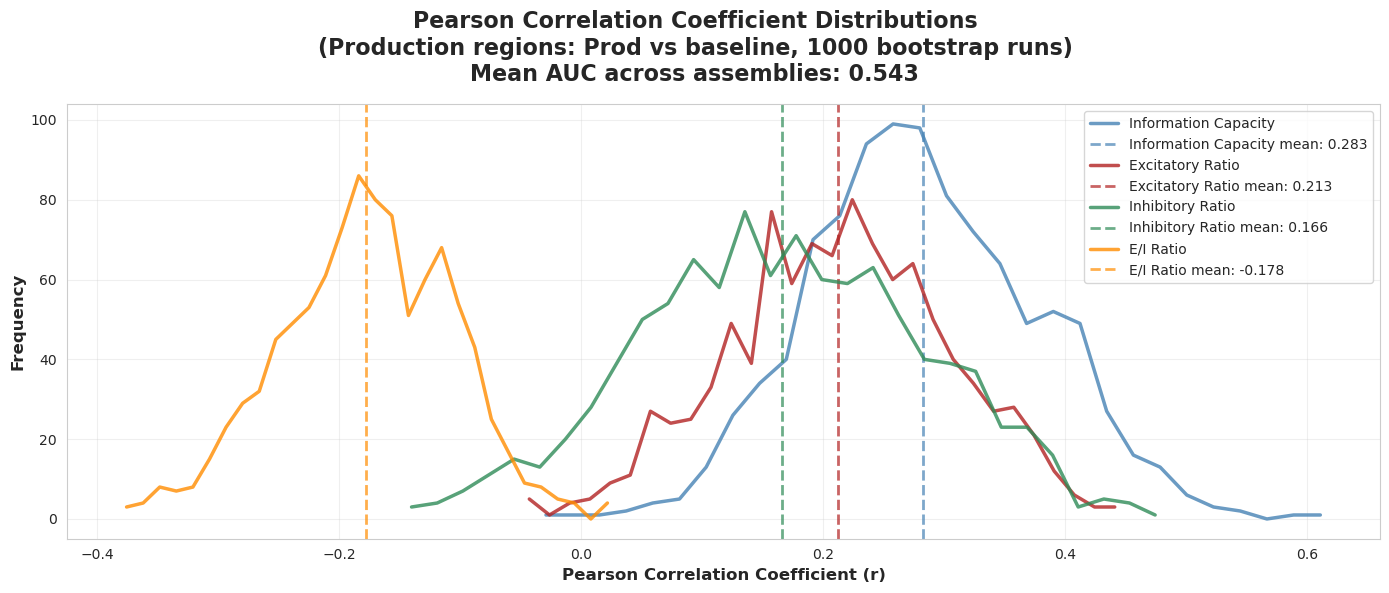

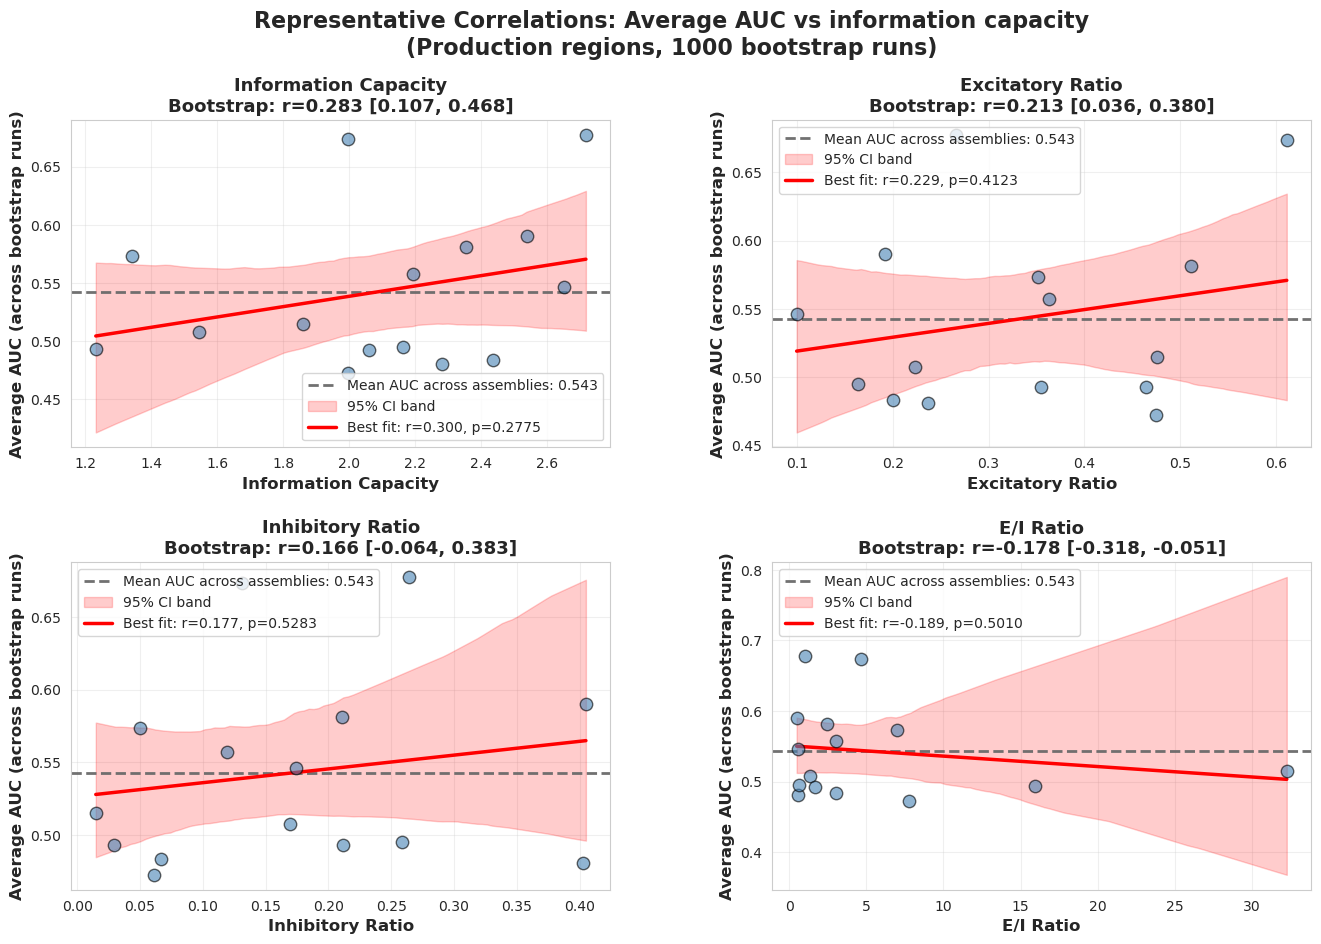

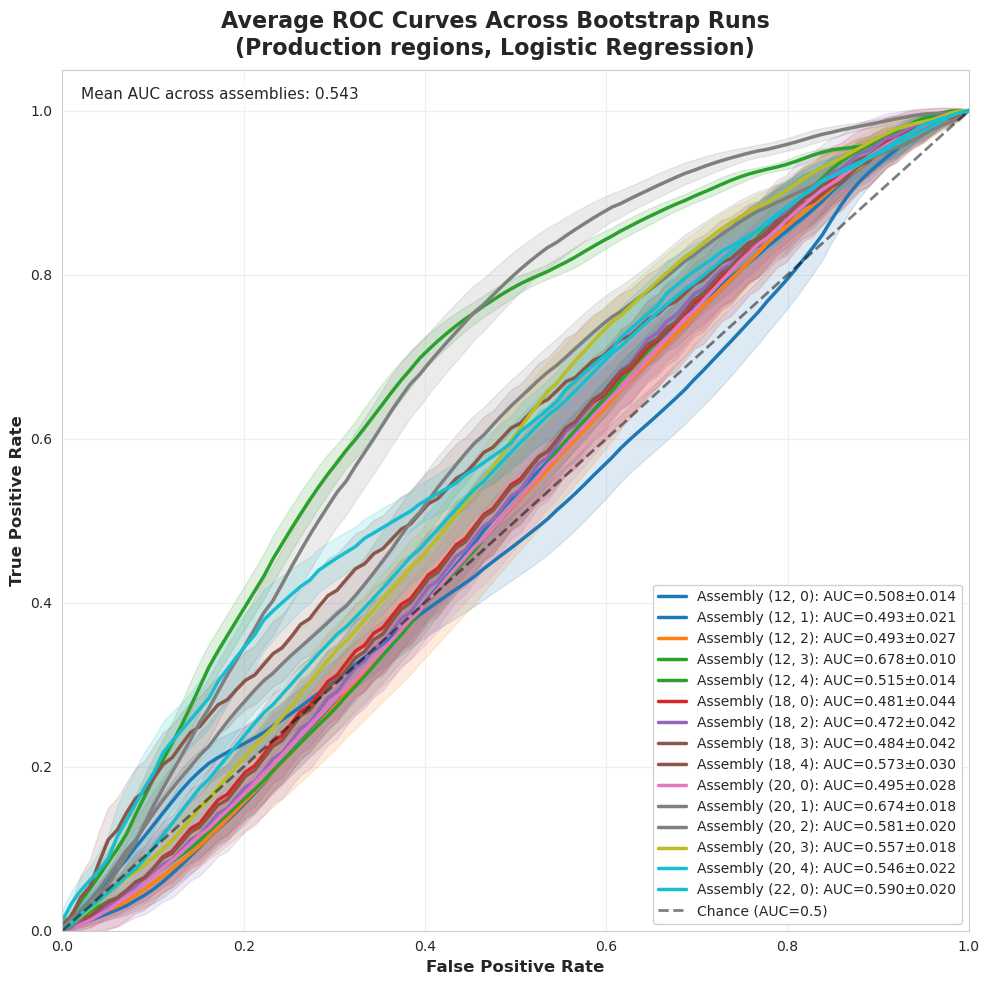


✓ Visualizations complete!
  - Mean AUC across assemblies: 0.543
  - Correlation distributions: 4 metrics
  - Representative scatter plots: 4 metrics
  - Average ROC curves: 15 assemblies


In [93]:
# COMPREHENSIVE VISUALIZATIONS FOR BOOTSTRAP ANALYSIS
# 1. Correlation coefficient distributions with means
# 2. Representative correlation scatter plots with best fit lines
# 3. Representative ROC curves (if available)

print(f"\n{'='*80}")
print("COMPREHENSIVE BOOTSTRAP VISUALIZATIONS")
print(f"{'='*80}\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc
from scipy.interpolate import interp1d

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

_auc_mean_per_asm = df_bootstrap.groupby('assembly_id')['auc'].mean()
grand_mean_auc_across_assemblies = float(_auc_mean_per_asm.mean())

# ============================================================================
# 1. PEARSON CORRELATION COEFFICIENT DISTRIBUTIONS (line plots with means)
# ============================================================================

fig1 = plt.figure(figsize=(14, 6))
ax1 = fig1.add_subplot(1, 1, 1)

fig1.suptitle(
    'Pearson Correlation Coefficient Distributions\n(Production regions: Prod vs baseline, 1000 bootstrap runs)\n'
    f'Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}',
    fontsize=16, fontweight='bold', y=0.98)

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
# Keep only metrics that the current df_bootstrap AND df_correlations both know about.
# This makes the cell safe to re-run against any vintage of the bootstrap output.
_boot_cols = set(df_bootstrap.columns)
_corr_metrics = set(df_correlations['metric'].unique()) if 'metric' in df_correlations.columns else set()
metrics_to_correlate = [m for m in metrics_to_correlate if m in _boot_cols and m in _corr_metrics]
if not metrics_to_correlate:
    raise RuntimeError("No correlation metrics available in both df_bootstrap and df_correlations - re-run the bootstrap cell above.")
print(f"  metrics available for visualization: {metrics_to_correlate}")

metric_labels = {
    'information_capacity': 'Information Capacity',
    'excitatory_ratio':     'Excitatory Ratio',
    'inhibitory_ratio':     'Inhibitory Ratio',
    'ei_ratio':             'E/I Ratio',
}

_full_colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange']
colors = _full_colors[:len(metrics_to_correlate)]
for idx, metric in enumerate(metrics_to_correlate):
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) == 0:
        continue
    pearson_rs = metric_corrs['pearson_r'].values
    
    # Create histogram data
    counts, bins = np.histogram(pearson_rs, bins=30)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Plot as line plot (step plot)
    ax1.plot(bin_centers, counts, linewidth=2.5, color=colors[idx], 
            label=metric_labels[metric], alpha=0.8)
    
    # Add mean line
    mean_r = np.mean(pearson_rs)
    ax1.axvline(mean_r, color=colors[idx], linestyle='--', linewidth=2, 
               alpha=0.7, label=f'{metric_labels[metric]} mean: {mean_r:.3f}')

ax1.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_coefficients.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 2. REPRESENTATIVE CORRELATION SCATTER PLOTS
# (Average AUC across bootstrap runs vs each metric)
# ============================================================================

# Compute average AUC for each assembly across all bootstrap runs
avg_auc_by_assembly = df_bootstrap.groupby('assembly_id')['auc'].mean().reset_index()
avg_auc_by_assembly.columns = ['assembly_id', 'avg_auc']

# Get metric values (same for all runs, so just take first run)
first_run_data = df_bootstrap[df_bootstrap['run'] == df_bootstrap['run'].min()].copy()
_am_cols = ['assembly_id'] + [m for m in metrics_to_correlate if m in first_run_data.columns]
assembly_metrics = first_run_data[_am_cols].copy()

# Merge
plot_data = avg_auc_by_assembly.merge(assembly_metrics, on='assembly_id', how='inner')

fig2 = plt.figure(figsize=(16, 10))
gs2 = fig2.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

fig2.suptitle('Representative Correlations: Average AUC vs information capacity\n(Production regions, 1000 bootstrap runs)', 
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    ax = fig2.add_subplot(gs2[row, col])
    
    # Get data for this metric
    if metric not in plot_data.columns:
        continue
    x = plot_data[metric].values
    y = plot_data['avg_auc'].values
    
    # Remove NaN values
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]
    
    if len(x_clean) > 1:
        # Scatter plot
        ax.scatter(x_clean, y_clean, alpha=0.6, s=80, color='steelblue', edgecolors='black', linewidth=1, zorder=3)
        ax.axhline(grand_mean_auc_across_assemblies, color='dimgray', linestyle='--', linewidth=2, alpha=0.95,
                   label=f'Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}', zorder=2)
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
        
        # Create line of best fit
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        y_line = slope * x_line + intercept
        
        # Calculate confidence interval for the regression line
        # Using bootstrap method for CI
        n_boot = 1000
        slopes = []
        intercepts = []
        for _ in range(n_boot):
            indices = np.random.choice(len(x_clean), len(x_clean), replace=True)
            x_boot = x_clean[indices]
            y_boot = y_clean[indices]
            try:
                s, i, _, _, _ = stats.linregress(x_boot, y_boot)
                slopes.append(s)
                intercepts.append(i)
            except:
                continue
        
        slopes = np.array(slopes)
        intercepts = np.array(intercepts)
        
        # Calculate CI for each x point
        y_line_lower = np.zeros_like(x_line)
        y_line_upper = np.zeros_like(x_line)
        for i, x_val in enumerate(x_line):
            y_vals = slopes * x_val + intercepts
            y_line_lower[i] = np.percentile(y_vals, 2.5)
            y_line_upper[i] = np.percentile(y_vals, 97.5)
        
        # Plot CI band
        ax.fill_between(x_line, y_line_lower, y_line_upper, alpha=0.2, color='red', 
                       label='95% CI band')
        
        # Plot best fit line
        ax.plot(x_line, y_line, 'r-', linewidth=2.5, label=f'Best fit: r={r_value:.3f}, p={p_value:.4f}')
        
        # Get correlation from bootstrap analysis
        metric_corrs = df_correlations[df_correlations['metric'] == metric]
        bootstrap_mean_r = metric_corrs['pearson_r'].mean()
        bootstrap_ci_lower = np.percentile(metric_corrs['pearson_r'], 2.5)
        bootstrap_ci_upper = np.percentile(metric_corrs['pearson_r'], 97.5)
        
        ax.set_xlabel(metric_labels[metric], fontsize=12, fontweight='bold')
        ax.set_ylabel('Average AUC (across bootstrap runs)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric_labels[metric]}\n'
                    f'Bootstrap: r={bootstrap_mean_r:.3f} [{bootstrap_ci_lower:.3f}, {bootstrap_ci_upper:.3f}]', 
                    fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', 
               transform=ax.transAxes, fontsize=14)
        ax.set_title(metric_labels[metric], fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("bootstrap_correlations.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. AVERAGE ROC CURVES FOR EACH ASSEMBLY (ALL ON SAME AXES)
# ============================================================================

# Get unique assemblies
unique_assemblies = df_bootstrap['assembly_id'].unique()

# Create single figure with one axes
fig3 = plt.figure(figsize=(10, 10))
ax3 = fig3.add_subplot(1, 1, 1)

fig3.suptitle('Average ROC Curves Across Bootstrap Runs\n(Production regions, Logistic Regression)', 
             fontsize=16, fontweight='bold', y=0.98)
ax3.text(0.02, 0.98, f'Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}',
         transform=ax3.transAxes, fontsize=11, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Use a colormap to get different colors for each assembly
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_assemblies)))

# Interpolate all ROC curves to common FPR points
all_fpr = np.linspace(0, 1, 100)

for idx, assembly_id in enumerate(unique_assemblies):
    # Get all ROC curves for this assembly across all bootstrap runs
    assembly_mask = df_bootstrap['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            # Handle case where fpr/tpr might be stored as lists
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                # Interpolate
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            std_tpr = np.std(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            std_auc = np.std(assembly_aucs)
            
            # Plot mean with confidence interval
            ax3.plot(all_fpr, mean_tpr, color=colors[idx], lw=2.5, 
                   label=f'Assembly {assembly_id}: AUC={mean_auc:.3f}±{std_auc:.3f}')
            ax3.fill_between(all_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                           color=colors[idx], alpha=0.15)

# Plot chance line (only once)
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Chance (AUC=0.5)')

ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_roc_curves.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualizations complete!")
print(f"  - Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}")
print(f"  - Correlation distributions: {len(metrics_to_correlate)} metrics")
print(f"  - Representative scatter plots: {len(metrics_to_correlate)} metrics")
print(f"  - Average ROC curves: {len(unique_assemblies)} assemblies")


In [ ]:
# [Live-sync header] Non-production regions (pSTG excluded): same Prod vs null pipeline as above.

# PER-ASSEMBLY LOGISTIC REGRESSION (LR) — BOOTSTRAP
# Non-production regions (excluding pSTG — analyzed separately — and vPrCG/parsOp/parsTr/PoCG).
# Speech PRODUCTION vs null/baseline; information capacity computed locally.
# All FLAIR groups included.

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, kstest, spearmanr, pearsonr
from scipy.linalg import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import re
import fnmatch
import os

warnings.filterwarnings('ignore')

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("PER-ASSEMBLY LOGISTIC REGRESSION — NON-PRODUCTION REGIONS (excl. pSTG)")
print("Prod vs baseline | information capacity computed locally")
print("Running 1000 iterations with different baseline samples")
print("=" * 80)

# Information capacity: computed locally (same method as 5_ensemble_4_information.ipynb)

def calculate_mutual_information(x, y, bins=20):
    """Mutual information between two variables (histogram), as in 5_ensemble_4_information.ipynb."""
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    if np.sum(valid_mask) < 2:
        return np.nan
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    hist_2d, _, _ = np.histogram2d(x_valid, y_valid, bins=bins)
    hist_x = np.sum(hist_2d, axis=1)
    hist_y = np.sum(hist_2d, axis=0)
    p_xy = hist_2d / np.sum(hist_2d)
    p_x = hist_x / np.sum(hist_x)
    p_y = hist_y / np.sum(hist_y)
    mi = 0.0
    for i in range(len(p_x)):
        for j in range(len(p_y)):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mi += p_xy[i, j] * np.log2(p_xy[i, j] / (p_x[i] * p_y[j]))
    return mi


def calculate_information_capacity(data, time_bins, min_samples=10):
    """Same method as 5_ensemble_4_information.ipynb (entropy minus temporal MI of assembly expression)."""
    valid_mask = ~np.isnan(data)
    if np.sum(valid_mask) < min_samples:
        return {
            'entropy': np.nan,
            'mutual_info_temporal': np.nan,
            'capacity': np.nan,
            'n_valid_samples': np.sum(valid_mask),
            'data_range': np.nan,
            'data_std': np.nan
        }
    valid_data = data[valid_mask]
    n_bins = min(20, len(valid_data) // 5)
    if n_bins < 5:
        n_bins = 5
    hist, _ = np.histogram(valid_data, bins=n_bins)
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]
    if len(prob) < 2:
        entropy_val = np.nan
    else:
        entropy_val = -np.sum(prob * np.log2(prob))
    if len(valid_data) > 1:
        try:
            mi_temporal = calculate_mutual_information(
                valid_data[:-1],
                valid_data[1:],
                bins=min(10, max(2, len(valid_data) // 10))
            )
        except Exception:
            mi_temporal = np.nan
    else:
        mi_temporal = np.nan
    if not np.isnan(entropy_val) and not np.isnan(mi_temporal):
        capacity = entropy_val - mi_temporal
    elif not np.isnan(entropy_val):
        capacity = entropy_val
    else:
        capacity = np.nan
    data_range = np.max(valid_data) - np.min(valid_data) if len(valid_data) > 0 else np.nan
    data_std = np.std(valid_data) if len(valid_data) > 0 else np.nan
    return {
        'entropy': entropy_val,
        'mutual_info_temporal': mi_temporal,
        'capacity': capacity,
        'n_valid_samples': np.sum(valid_mask),
        'data_range': data_range,
        'data_std': data_std
    }

def calculate_expression_strength(firingRateMatrix, ap_norm_matrix):
    """Calculate expression strength"""
    n_time_bins, n_neurons = firingRateMatrix.shape
    n_assemblies = ap_norm_matrix.shape[0]
    expression_strength = np.zeros((n_time_bins, n_assemblies))
    for assembly_idx in range(n_assemblies):
        weight_vector = ap_norm_matrix[assembly_idx, :]
        outer_product = np.outer(weight_vector, weight_vector)
        for time_bin in range(n_time_bins):
            firing_rate_vector = firingRateMatrix[time_bin, :]
            expression_strength[time_bin, assembly_idx] = firing_rate_vector.T @ outer_product @ firing_rate_vector
    return expression_strength

def imec_key_sorter(key):
    """Extract the number after 'imec'"""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

MIN_BEHAVIOR_MINUTES = 10.0

def _behavior_duration_seconds(task_times_obj):
    starts = np.asarray(task_times_obj.start, dtype=float).ravel()
    ends = np.asarray(task_times_obj.end, dtype=float).ravel()
    if starts.size != ends.size:
        return np.nan
    return float(np.sum(ends - starts))

def _ks_time_bounds_full_recording(spike_times_obj):
    """Min/max time for uniform KS (full recording)."""
    tmin, tmax = np.inf, -np.inf
    for u in range(len(spike_times_obj)):
        idx = spike_times_obj[u].as_series().index.values
        if len(idx):
            tmin = min(tmin, float(np.min(idx)))
            tmax = max(tmax, float(np.max(idx)))
    if np.isfinite(tmin) and np.isfinite(tmax):
        return tmin, tmax
    return np.nan, np.nan


def find_valid_baseline_windows(task_start, task_end, all_language_starts, all_language_ends,
                               buffer, baseline_duration, bin_starts, bin_ends):
    """
    Pre-compute all valid baseline windows that don't overlap with language events.
    Returns list of (start, end) tuples for valid baseline periods.
    """
    valid_windows = []
    # Create a fine grid of potential start times
    step_size = 0.01  # 10ms steps
    potential_starts = np.arange(task_start, task_end - baseline_duration + step_size, step_size)
    for start_candidate in potential_starts:
        end_candidate = start_candidate + baseline_duration
        # Check if this window overlaps with any language event
        overlaps = False
        for lang_start, lang_end in zip(all_language_starts, all_language_ends):
            if not (end_candidate < lang_start - buffer or start_candidate > lang_end + buffer):
                overlaps = True
                break
        if not overlaps:
            # Check if we have bins that cover this window
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                valid_windows.append((start_candidate, end_candidate))
    return valid_windows

# Other regions: not pSTG (separate analysis), not production-network (vPrCG, parsOp, parsTr), not PoCG
PRODUCTION_REGIONS = {'vPrCG', 'parsOp', 'parsTr'}
EXCLUDED_REGIONS = {'pSTG','PoCG'} | PRODUCTION_REGIONS
other_region_insertions = []
insertion_counter = 0

for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)
    for s in range(len(keys)):
        if insertion_counter < len(region_list):
            region = region_list[insertion_counter]
            if region not in EXCLUDED_REGIONS:
                has_prod = "ProdSpeechWords" in data
                if has_prod:
                    other_region_insertions.append({
                        'nwb_idx': i,
                        'session_idx': s,
                        'insertion_idx': insertion_counter,
                        'region': region,
                    })
        insertion_counter += 1

print(f"Found {len(other_region_insertions)} non-production insertions (excl. pSTG) with ProdSpeechWords")

# PRE-COMPUTE ALL ASSEMBLIES AND DATA (ONCE, OUTSIDE BOOTSTRAP LOOP)
n_ins_other = len(other_region_insertions)
print(f"\nPre-computing assemblies and production-trial expression ({n_ins_other} insertions, non-production regions)...", flush=True)

assembly_data = {}  # Store pre-computed data for each assembly

for ins_num, ins_info in enumerate(other_region_insertions, start=1):
    nwb_idx = ins_info['nwb_idx']
    session_idx = ins_info['session_idx']
    insertion_idx = ins_info['insertion_idx']
    region = ins_info['region']
    t_ins = time.perf_counter()
    # Load data first; keys[session_idx] must index this file's sorted analyzer list (printing before load used stale keys).
    data = nap.load_file(nwb_paths[nwb_idx])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[nwb_idx]) or 'NP139_B2' in str(nwb_paths[nwb_idx]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)

    if session_idx >= len(keys):
        print(f"  [{ins_num}/{n_ins_other}] insertion_idx={insertion_idx} region={region} | {nwb_paths[nwb_idx].name} | SKIP: session_idx={session_idx} >= len(keys)={len(keys)}", flush=True)
        continue
    print(f"  [{ins_num}/{n_ins_other}] insertion_idx={insertion_idx} region={region} | {nwb_paths[nwb_idx].name} | {keys[session_idx]}", flush=True)

    spike_times = data[keys[session_idx]]
    has_prod = "ProdSpeechWords" in data
    has_sens = "StimSpeechWords" in data
    if not has_prod:
        continue
    # Filter to good neurons (behavior length: full recording vs TaskTimes; KS matches R_EI.ipynb)
    firingRates_all = spike_times.metadata["rate"]
    if "TaskTimes" in data.keys():
        task_times = data["TaskTimes"]
    else:
        task_times = data["task_times"]

    start_time = task_times.start
    end_time = task_times.end
    beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)

    beh_sec = _behavior_duration_seconds(task_times)
    beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
    use_full_recording = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)

    if use_full_recording:
        spike_times_beh = spike_times
        firingRates_beh = firingRates_all
        min_time, max_time = _ks_time_bounds_full_recording(spike_times)
        if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
            print(f"  Short behavior ({beh_min:.2f} min) but could not get recording bounds; skipping insertion")
            continue
    else:
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]
        min_time = float(np.asarray(start_time).ravel()[0])
        max_time = float(np.asarray(end_time).ravel()[-1])

    ks_stats = np.zeros(len(spike_times))
    ks_pvals = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        test = spike_times[u].as_series().index.values
        if len(test) > 1:
            normalized_spike_times = (test - min_time) / (max_time - min_time)
            ks_result = kstest(normalized_spike_times, "uniform")
            ks_stats[u] = ks_result.statistic
            ks_pvals[u] = ks_result.pvalue
        else:
            ks_stats[u] = np.nan
            ks_pvals[u] = np.nan

    violationThreshold = 3 / 1000
    violationPct = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        unit = spike_times[u]
        unit = unit.as_series().index
        if len(unit) < 100:
            violationPct[u] = 1
        else:
            isi = unit.diff()[1:len(unit)]
            violations = np.where(isi < violationThreshold)
            violations = np.array(violations)
            violationPct[u] = violations.size / len(isi)
    if "KSLabel" in spike_times.metadata:
        KSLabels = spike_times.metadata["KSLabel"]
    else:
        KSLabels = spike_times.metadata["quality"]
    firingRates = firingRates_beh
    mask1 = violationPct < 3 / 100
    mask2 = firingRates > 0.5
    mask3 = KSLabels != "noise"
    mask4 = ks_stats < 0.3
    mask = mask1 & mask2 & mask3 & mask4
    indicesFinal = firingRates.index[mask]
    if insertion_idx < len(manual_exclude_lists):
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
    spike_times_good = spike_times[indicesFinal]
    n_neurons = len(spike_times_good)
    print(f"    good neurons: {n_neurons}", flush=True)
    if n_neurons == 0:
        continue

    # ---- E/I cluster labels for this insertion (aligned with indicesFinal order) ----
    # Requires et_sparse_labels and et_sparse_metadata from the E/I clustering section above.
    # Convention: excitatory = cluster 0, inhibitory = cluster 2 (cluster 1 = "other").
    insertion_cluster_labels = []
    if 'et_sparse_labels' in globals() and 'et_sparse_metadata' in globals():
        matching_neurons = [(idx, neuron) for idx, neuron in enumerate(et_sparse_metadata)
                            if neuron.get('insertion_idx') == insertion_idx]
        for local_neuron_idx in range(len(indicesFinal)):
            cluster_label = -1
            if local_neuron_idx < len(matching_neurons):
                global_idx = matching_neurons[local_neuron_idx][0]
                cluster_label = et_sparse_labels[global_idx]
            insertion_cluster_labels.append(cluster_label)
    else:
        print("    WARNING: et_sparse_labels/et_sparse_metadata not in globals -> using -1", flush=True)
        insertion_cluster_labels = [-1] * len(indicesFinal)
    insertion_cluster_labels = np.array(insertion_cluster_labels)

    # Make spike rate matrix
    timescale = 25 / 1000
    spikeCountMatrix = spike_times_good.count(bin_size=timescale)
    bin_edges = spikeCountMatrix.index.values
    bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
    if len(bin_centers) < len(bin_edges):
        last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
        last_center = bin_edges[-1] - last_width / 2
        bin_centers = np.append(bin_centers, last_center)
    spikeCountMatrix = spikeCountMatrix.values
    firingRateMatrix = spikeCountMatrix / timescale
    firingRateMatrix = stats.zscore(firingRateMatrix, axis=0)
    print(f"    rate matrix: T={firingRateMatrix.shape[0]} bins, N={firingRateMatrix.shape[1]} neurons", flush=True)
    t_pca0 = time.perf_counter()
    # Calculate assemblies
    pca = PCA()
    firingRateMatrix_pca = pca.fit_transform(firingRateMatrix)
    eigenvalues = pca.explained_variance_
    upperbound = (1 + np.sqrt(firingRateMatrix.shape[1] / firingRateMatrix.shape[0])) ** 2
    assemblyIndices = np.where(eigenvalues > upperbound)
    assemblyEigenvalues = eigenvalues[assemblyIndices]
    n_pcs = len(assemblyEigenvalues)
    if n_pcs == 0:
        continue
    # Orthogonalize with ICA
    pc_vectors = pca.components_[:n_pcs, :]
    projections = firingRateMatrix @ pc_vectors.T
    fastica = FastICA(n_components=n_pcs, algorithm='parallel', whiten='unit-variance',
                      max_iter=500, tol=1e-7, random_state=1)
    ica_components = fastica.fit_transform(projections)
    unmixing_matrix = fastica.components_
    ica_assembly_patterns = unmixing_matrix @ pc_vectors
    # Normalize assembly patterns
    ap_norm_matrix = ica_assembly_patterns.copy()
    for ii in range(n_pcs):
        ap = ica_assembly_patterns[ii, :]
        ap_norm = ap / norm(ap)
        maxW = max(ap_norm)
        minW = min(ap_norm)
        if abs(minW) > maxW:
            ap_norm = ap_norm * -1
        ap_norm_matrix[ii, :] = ap_norm
    print(f"    PCA+ICA done in {time.perf_counter() - t_pca0:.1f}s ({n_pcs} assemblies)", flush=True)
    # (skipped calculate_expression_strength: unused here and very slow)
    # Task boundaries for baseline (task_times already set above: TaskTimes vs task_times)
    if isinstance(task_times.start, np.ndarray):
        task_start = task_times.start[0]
        task_end = task_times.end[-1]
    else:
        task_start = task_times.start.values[0]
        task_end = task_times.end.values[-1]

    if has_sens:
        sens_rel_start = 0
        sens_rel_end = 0.10
        speech_sens_times = data["StimSpeechWords"]
        sens_onsets = nap.Ts(speech_sens_times.start)
        sens_offsets = nap.Ts(speech_sens_times.end)
        sens_starts = (sens_onsets.as_series().index + sens_rel_start).values
        sens_ends = (sens_offsets.as_series().index + sens_rel_end).values
    else:
        sens_starts = np.array([])
        sens_ends = np.array([])

    prod_rel_start = -0.10
    prod_rel_end = 0
    speech_prod_times = data["ProdSpeechWords"]
    prod_onsets = nap.Ts(speech_prod_times.start)
    prod_offsets = nap.Ts(speech_prod_times.end)
    prod_starts = (prod_onsets.as_series().index + prod_rel_start).values
    prod_ends = (prod_offsets.as_series().index + prod_rel_end).values

    bin_starts = bin_centers - timescale / 2
    bin_ends = bin_centers + timescale / 2

    all_language_starts = list(sens_starts) + list(prod_starts)
    all_language_ends = list(sens_ends) + list(prod_ends)
    buffer = 0.1
    baseline_duration = 0.1
    valid_baseline_windows = find_valid_baseline_windows(
        task_start, task_end, all_language_starts, all_language_ends,
        buffer, baseline_duration, bin_starts, bin_ends
    )
    # For each assembly, pre-compute everything except baseline sampling
    for asm_idx in range(n_pcs):
        if asm_idx == 0:
            t_asm0 = time.perf_counter()
        elif asm_idx == n_pcs - 1:
            print(f"      assemblies 1..{n_pcs} (capacity + prod trials) last one...", flush=True)
        assembly_expression = ica_components[:, asm_idx]
        cap_dict = calculate_information_capacity(assembly_expression, bin_centers, min_samples=10)
        info_capacity = cap_dict['capacity']

        prod_expression_values = []
        for u in range(len(prod_starts)):
            interval_start = prod_starts[u]
            interval_end = prod_ends[u]
            mask = (bin_starts >= interval_start) & (bin_ends <= interval_end)
            if np.any(mask):
                trial_expression = np.mean(assembly_expression[mask])
                prod_expression_values.append(trial_expression)

        # ---- E/I composition of this assembly ----
        # Convention: excitatory = cluster 0, inhibitory = cluster 2
        assembly_weights = ap_norm_matrix[asm_idx, :]
        excitatory_tone  = np.sum(assembly_weights[insertion_cluster_labels == 0])
        inhibitory_tone  = np.sum(assembly_weights[insertion_cluster_labels == 2])
        total_tone       = np.sum(np.abs(assembly_weights))
        excitatory_ratio = np.abs(excitatory_tone) / (total_tone + 1e-10)
        inhibitory_ratio = np.abs(inhibitory_tone) / (total_tone + 1e-10)
        ei_ratio         = excitatory_ratio / (inhibitory_ratio + 1e-10)

        assembly_id = (insertion_idx, asm_idx)
        assembly_data[assembly_id] = {
            'insertion_idx': insertion_idx,
            'assembly_idx': asm_idx,
            'region': region,
            'assembly_expression': assembly_expression,
            'prod_expression_values': prod_expression_values,
            'valid_baseline_windows': valid_baseline_windows,
            'bin_starts': bin_starts,
            'bin_ends': bin_ends,
            'info_capacity': info_capacity,
            'n_neurons': n_neurons,
            'excitatory_ratio': excitatory_ratio,
            'inhibitory_ratio': inhibitory_ratio,
            'ei_ratio': ei_ratio,
        }

print(f"    insertion wall time: {time.perf_counter() - t_ins:.1f}s | assemblies in dict: {len(assembly_data)}", flush=True)
print(f"Pre-computed data for {len(assembly_data)} assemblies")

# Number of bootstrap iterations
n_bootstrap = 1000

# Storage for bootstrap results
bootstrap_results = {
    'run': [],
    'assembly_id': [],
    'auc': [],
    'information_capacity': [],
    'excitatory_ratio': [],
    'inhibitory_ratio': [],
    'ei_ratio': [],
    'fpr': [],
    'tpr': []
}

# Storage for correlation results across runs
correlation_results = {
    'run': [],
    'metric': [],
    'pearson_r': [],
    'pearson_p': []
}

print(f"\nRunning {n_bootstrap} bootstrap iterations...")

# Run bootstrap iterations - ONLY baseline sampling and correlation calculation
for bootstrap_iter in range(n_bootstrap):
    print(f"Iteration {bootstrap_iter + 1}/{n_bootstrap}...", end=' ', flush=True)
    # Set random seed for this iteration
    np.random.seed(bootstrap_iter)
    # Process each assembly
    for assembly_id, asm_data in assembly_data.items():
        prod_expression_values = asm_data['prod_expression_values']
        valid_baseline_windows = asm_data['valid_baseline_windows']
        assembly_expression = asm_data['assembly_expression']
        bin_starts = asm_data['bin_starts']
        bin_ends = asm_data['bin_ends']
        if len(valid_baseline_windows) == 0:
            continue
        # Sample baseline periods from pre-computed valid windows
        baseline_expression_values = []
        n_baseline_samples = len(prod_expression_values)
        # Sample with replacement from valid windows
        if len(valid_baseline_windows) >= n_baseline_samples:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=False)
        else:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=True)
        for window_idx in selected_windows:
            start_candidate, end_candidate = valid_baseline_windows[window_idx]
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                baseline_expression = np.mean(assembly_expression[mask])
                baseline_expression_values.append(baseline_expression)
        if len(prod_expression_values) < 3 or len(baseline_expression_values) < 3:
            continue
        # Prepare data
        X_all = np.array(prod_expression_values + baseline_expression_values).reshape(-1, 1)
        y_all = np.array([1] * len(prod_expression_values) + [0] * len(baseline_expression_values))
        # Cross-validation with Logistic Regression
        try:
            n_pos = np.sum(y_all == 1)
            n_baseline = np.sum(y_all == 0)
            n_splits = min(5, min(n_pos, n_baseline))
            if n_splits < 2:
                continue
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_aucs = []
            for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
                X_train_cv, X_val_cv = X_all[train_idx], X_all[val_idx]
                y_train_cv, y_val_cv = y_all[train_idx], y_all[val_idx]
                lr = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', random_state=42, max_iter=1000)
                lr.fit(X_train_cv, y_train_cv)
                y_pred_proba_cv = lr.predict_proba(X_val_cv)[:, 1]
                auc_cv = roc_auc_score(y_val_cv, y_pred_proba_cv)
                cv_aucs.append(auc_cv)
            cv_aucs = np.array(cv_aucs)
            cv_auc_mean = np.mean(cv_aucs)
            # Train final model on all data for ROC curve
            lr_final = LogisticRegression(
                C=1.0,
                penalty='l2',
                class_weight='balanced',
                random_state=42,
                max_iter=1000
            )
            lr_final.fit(X_all, y_all)
            y_pred_proba_all = lr_final.predict_proba(X_all)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_all, y_pred_proba_all)
            # Store results for this bootstrap iteration
            bootstrap_results['run'].append(bootstrap_iter)
            bootstrap_results['assembly_id'].append(assembly_id)
            bootstrap_results['auc'].append(cv_auc_mean)
            bootstrap_results['information_capacity'].append(asm_data['info_capacity'])
            bootstrap_results['excitatory_ratio'].append(asm_data['excitatory_ratio'])
            bootstrap_results['inhibitory_ratio'].append(asm_data['inhibitory_ratio'])
            bootstrap_results['ei_ratio'].append(asm_data['ei_ratio'])
            bootstrap_results['fpr'].append(fpr)
            bootstrap_results['tpr'].append(tpr)
        except Exception as e:
            continue
    # Calculate correlations for this bootstrap iteration
    # Get only results from this iteration
    start_idx = len([r for r in bootstrap_results['run'] if r < bootstrap_iter])
    end_idx = len([r for r in bootstrap_results['run'] if r <= bootstrap_iter])
    if end_idx > start_idx:
        df_iter = pd.DataFrame({
            'auc': bootstrap_results['auc'][start_idx:end_idx],
            'information_capacity': bootstrap_results['information_capacity'][start_idx:end_idx],
            'excitatory_ratio': bootstrap_results['excitatory_ratio'][start_idx:end_idx],
            'inhibitory_ratio': bootstrap_results['inhibitory_ratio'][start_idx:end_idx],
            'ei_ratio': bootstrap_results['ei_ratio'][start_idx:end_idx],
        })
        metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
        for metric in metrics_to_correlate:
            valid_data = df_iter.dropna(subset=[metric, 'auc'])
            if len(valid_data) > 1:
                r_pearson, p_pearson = pearsonr(valid_data[metric], valid_data['auc'])
                correlation_results['run'].append(bootstrap_iter)
                correlation_results['metric'].append(metric)
                correlation_results['pearson_r'].append(r_pearson)
                correlation_results['pearson_p'].append(p_pearson)
    print("Done")

print(f"\n{'='*80}")
print("BOOTSTRAP ANALYSIS COMPLETE")
print(f"{'='*80}")

# Create DataFrames
df_bootstrap = pd.DataFrame(bootstrap_results)
df_correlations = pd.DataFrame(correlation_results)
# Save results for comparison
df_bootstrap_other = df_bootstrap.copy()
df_correlations_other = df_correlations.copy()
print(f"✓ Saved other regions bootstrap results: {len(df_bootstrap_other)} rows")


# Analyze correlation stability
print(f"\n{'='*80}")
print("CORRELATION STABILITY ANALYSIS")
print(f"{'='*80}")

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        print(f"  Pearson r: mean = {metric_corrs['pearson_r'].mean():.4f} ± {metric_corrs['pearson_r'].std():.4f}")
        print(f"  Pearson p: mean = {metric_corrs['pearson_p'].mean():.4f}, median = {metric_corrs['pearson_p'].median():.4f}")
        # Count how many runs are significant
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        print(f"  Significant runs (p < 0.05): Pearson = {n_sig_pearson}/{len(metric_corrs)} ({100*n_sig_pearson/len(metric_corrs):.1f}%)")
        # Percentiles
        print(f"  Pearson p percentiles: 5th = {np.percentile(metric_corrs['pearson_p'], 5):.4f}, "
              f"95th = {np.percentile(metric_corrs['pearson_p'], 95):.4f}")

# Statistical tests for overall significance
print(f"\n{'='*80}")
print("STATISTICAL TESTS FOR OVERALL SIGNIFICANCE")
print(f"{'='*80}")
print("\nMultiple approaches to assess significance across bootstrap runs:")
print("  1. Bootstrap CI on correlation (RECOMMENDED): Tests if 95% CI excludes zero")
print("  2. Fisher's combined test: Combines all p-values into single test")
print("  3. Mean/median p-value tests: Assess if p-values are systematically < 0.05")
print("  4. Binomial test: Tests proportion significant (note: assumes independence)\n")

from scipy.stats import binomtest, ttest_1samp, wilcoxon, chi2

for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        # Test Pearson p-values
        p_values = metric_corrs['pearson_p'].values
        n = len(p_values)
        n_sig = np.sum(p_values < 0.05)
        prop_sig = n_sig / n
        print(f"\n  Pearson p-values:")
        # 1. Binomial test: Is proportion of significant results > 5%?
        binom_result = binomtest(n_sig, n, p=0.05, alternative='greater')
        print(f"    Binomial test (prop > 0.05):")
        print(f"      Proportion significant: {prop_sig:.1%} ({n_sig}/{n})")
        print(f"      p-value: {binom_result.pvalue:.6f}")
        if binom_result.pvalue < 0.05:
            print(f"      ✓ Significant: More than 5% of runs are significant (p < 0.05)")
        else:
            print(f"      ✗ Not significant: Proportion not significantly > 5%")
        # 2. One-sample t-test: Is mean p-value < 0.05?
        t_stat, t_pval = ttest_1samp(p_values, 0.05, alternative='less')
        print(f"\n    One-sample t-test (mean < 0.05):")
        print(f"      Mean p-value: {np.mean(p_values):.6f}")
        print(f"      t-statistic: {t_stat:.4f}, p-value: {t_pval:.6f}")
        if t_pval < 0.05:
            print(f"      ✓ Significant: Mean p-value is significantly < 0.05")
        else:
            print(f"      ✗ Not significant: Mean p-value not significantly < 0.05")
        # 3. Wilcoxon signed-rank test: Is median p-value < 0.05?
        diff_from_threshold = p_values - 0.05
        w_pval = None
        if np.all(diff_from_threshold == 0):
            print(f"\n    Wilcoxon signed-rank test: Cannot compute (all p-values = 0.05)")
        else:
            w_stat, w_pval = wilcoxon(diff_from_threshold, alternative='less')
            print(f"\n    Wilcoxon signed-rank test (median < 0.05):")
            print(f"      Median p-value: {np.median(p_values):.6f}")
            print(f"      W-statistic: {w_stat:.4f}, p-value: {w_pval:.6f}")
            if w_pval < 0.05:
                print(f"      ✓ Significant: Median p-value is significantly < 0.05")
            else:
                print(f"      ✗ Not significant: Median p-value not significantly < 0.05")
        # 4. Fisher's combined probability test
        p_values_for_fisher = p_values.copy()
        p_values_for_fisher[p_values_for_fisher == 0] = np.finfo(float).eps
        chi2_stat = -2 * np.sum(np.log(p_values_for_fisher))
        df_fisher = 2 * n
        fisher_pval = 1 - chi2.cdf(chi2_stat, df_fisher)
        print(f"\n    Fisher's combined probability test:")
        print(f"      χ² statistic: {chi2_stat:.4f} (df={df_fisher})")
        print(f"      p-value: {fisher_pval:.6f}")
        if fisher_pval < 0.05:
            print(f"      ✓ Significant: Combined evidence suggests real effect")
        else:
            print(f"      ✗ Not significant: Combined evidence does not suggest real effect")
        # 5. Bootstrap Confidence Interval on Correlation Coefficient
        corr_values = metric_corrs['pearson_r'].values
        ci_lower = np.percentile(corr_values, 2.5)
        ci_upper = np.percentile(corr_values, 97.5)
        median_corr = np.median(corr_values)
        mean_corr = np.mean(corr_values)
        std_corr = np.std(corr_values)
        print(f"\n    Bootstrap Confidence Interval on Correlation Coefficient:")
        print(f"      Mean correlation: {mean_corr:.4f} ± {std_corr:.4f}")
        print(f"      Median correlation: {median_corr:.4f}")
        print(f"      95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        if ci_lower > 0 and ci_upper > 0:
            print(f"      ✓ Significant: 95% CI excludes zero (positive correlation)")
            ci_significant = True
        elif ci_lower < 0 and ci_upper < 0:
            print(f"      ✓ Significant: 95% CI excludes zero (negative correlation)")
            ci_significant = True
        else:
            print(f"      ✗ Not significant: 95% CI includes zero")
            ci_significant = False
        # Also compute 90% and 99% CIs for more information
        ci_90_lower = np.percentile(corr_values, 5)
        ci_90_upper = np.percentile(corr_values, 95)
        ci_99_lower = np.percentile(corr_values, 0.5)
        ci_99_upper = np.percentile(corr_values, 99.5)
        print(f"      90% CI: [{ci_90_lower:.4f}, {ci_90_upper:.4f}]")
        print(f"      99% CI: [{ci_99_lower:.4f}, {ci_99_upper:.4f}]")
        # Summary recommendation
        print(f"\n    Summary for Pearson:")
        significant_tests = []
        if ci_significant:
            significant_tests.append("Bootstrap CI (RECOMMENDED)")
        if fisher_pval < 0.05:
            significant_tests.append("Fisher's combined")
        if t_pval < 0.05:
            significant_tests.append("t-test (mean p-value)")
        if w_pval is not None and np.any(diff_from_threshold != 0) and w_pval < 0.05:
            significant_tests.append("Wilcoxon (median p-value)")
        if binom_result.pvalue < 0.05:
            significant_tests.append("Binomial (note: assumes independence)")
        if len(significant_tests) > 0:
            print(f"      ✓ Overall significant: {len(significant_tests)}/5 tests significant")
            print(f"        Significant tests: {', '.join(significant_tests)}")
            if ci_significant:
                print(f"        → PRIMARY CONCLUSION: Correlation is significant (95% CI excludes zero)")
            elif fisher_pval < 0.05:
                print(f"        → PRIMARY CONCLUSION: Combined evidence suggests significant correlation")
        else:
            print(f"      ✗ Overall not significant: 0/5 tests significant")
            print(f"        → PRIMARY CONCLUSION: No consistent evidence for significant correlation")

# Visualizations
print(f"\n{'='*80}")
print("CREATING VISUALIZATIONS")
print(f"{'='*80}")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

fig.suptitle('Bootstrap Analysis: Correlation Stability Across 100 Runs\n(Other Regions Sens vs Baseline, Logistic Regression)',
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    if row >= 2:
        break
    ax = fig.add_subplot(gs[row, col])
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        # Plot distribution of p-values
        ax.hist(metric_corrs['pearson_p'], bins=20, alpha=0.6, label=f"Pearson (n={len(metric_corrs)})",
                color='blue', edgecolor='black')
        ax.axvline(0.05, color='gray', linestyle='--', linewidth=2, label='p=0.05 threshold')
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        ax.set_xlabel('p-value', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{metric}\nSig: Pearson={n_sig_pearson}/{len(metric_corrs)} ({100 * n_sig_pearson / len(metric_corrs):.1f}%)',
                     fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

# Plot correlation coefficient distributions
ax = fig.add_subplot(gs[0, 2])
for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        ax.hist(metric_corrs['pearson_r'], bins=20, alpha=0.4, label=f"{metric} (Pearson)",
                histtype='step', linewidth=2)
ax.set_xlabel('Correlation Coefficient (r)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Pearson Correlation Coefficient Distributions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Removed Spearman correlation plot - only using Pearson

plt.tight_layout()
plt.show()

print(f"\nCreated visualization showing p-value distributions and correlation stability")
print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print("=" * 80)


PER-ASSEMBLY LOGISTIC REGRESSION — NON-PRODUCTION REGIONS (excl. pSTG)
Prod vs baseline | information capacity computed locally
Running 1000 iterations with different baseline samples
Found 14 non-production insertions (excl. pSTG) with ProdSpeechWords

Pre-computing assemblies and production-trial expression (14 insertions, non-production regions)...
  [1/14] insertion_idx=0 region=aSTG | NP93_B1.nwb | NP93_B1_g0_imec0_withoutKSmc
    good neurons: 1
    rate matrix: T=43207 bins, N=1 neurons
  [2/14] insertion_idx=1 region=SFG | NP95_B1.nwb | NP95_B1_g0_imec1
    good neurons: 57
    rate matrix: T=39795 bins, N=57 neurons
    PCA+ICA done in 0.7s (11 assemblies)
      assemblies 1..11 (capacity + prod trials) last one...
  [3/14] insertion_idx=4 region=SFG | NP105_B1.nwb | NP105_B1_g0_imec0
    good neurons: 1
    rate matrix: T=42595 bins, N=1 neurons
  [4/14] insertion_idx=8 region=pSTG | NP114_B1.nwb | NP114_B1_g0_imec0
    good neurons: 49
    rate matrix: T=95161 bins, N=49 neu

In [102]:
# ============================================================================
# TWO-BIN NON-PRODUCTION BOOTSTRAP (control regions)
# Alternative preprocessing to cell 11: same classifier (class-balanced L2 LR,
# 5-fold CV, same E/I pipeline), but each event is summarized as TWO features:
#   pre  : mean assembly expression over [onset - 0.10, onset]
#   peri : mean assembly expression over [onset, offset]  (= duration of event)
# Baselines are per-trial matched: total length = 0.10 + that trial's duration,
# with the first 0.10 s scored as pre and the remaining peri.
# Overwrites df_bootstrap / df_correlations / assembly_data in the same shape
# as cell 11 so cell 12 visualizes whichever of the two cells ran most recently.
# Cell 11 must have run once in this kernel (for helper functions & globals).
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kstest, pearsonr
from scipy.linalg import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import roc_auc_score, roc_curve
import time
import fnmatch
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TWO-BIN NON-PRODUCTION BOOTSTRAP (control regions)")
print("  pre  = mean expression in [-0.10, 0] s relative to vocalization onset")
print("  peri = mean expression in [0, duration] s relative to vocalization onset")
print("  baselines: per-trial matched (0.10 + duration), split into pre / peri")
print("  classifier: class-balanced L2 LR, 5-fold CV (unchanged)")
print("=" * 80)

# Helpers are defined in cell 11 — require it to have run.
for _name in ('find_valid_baseline_windows', 'calculate_information_capacity',
              'imec_key_sorter', '_ks_time_bounds_full_recording',
              '_behavior_duration_seconds', 'manual_exclude_lists',
              'nwb_paths', 'region_list'):
    if _name not in globals():
        raise RuntimeError(f"'{_name}' is missing; run cell 11 first.")

MIN_BEHAVIOR_MINUTES = 10.0
# Other regions: not pSTG (separate analysis), not production-network (vPrCG, parsOp, parsTr), not PoCG
PRODUCTION_REGIONS   = {'vPrCG', 'parsOp', 'parsTr'}
EXCLUDED_REGIONS     = {'pSTG','PoCG'} | PRODUCTION_REGIONS
PRE_DUR              = 0.10    # pre-vocalization window length (seconds)
PERI_DUR             = 0.10    # baseline peri window length (seconds) — matches 6_waveform 100 ms convention

# ---- enumerate non-production insertions (pSTG excluded) -------------------
other_region_insertions_2b = []
insertion_counter = 0
for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = list(data.keys())
    keys = [k for k in keys if fnmatch.fnmatch(k, "*imec*")]
    ks_keys = [k for k in keys if "KS4" in k]
    if ks_keys: keys = ks_keys
    th8_keys = [k for k in keys if "Th=8" in k]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [k for k in keys if "Th=" in k]
        if th_keys: keys = th_keys
    keys = [k for k in keys if not fnmatch.fnmatch(k, "*sentgen*")
                           and not fnmatch.fnmatch(k, "*_auto*")]
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [k for k in keys if 'imec1' not in k]
    keys = sorted(keys, key=imec_key_sorter)

    for s in range(len(keys)):
        if insertion_counter < len(region_list):
            region = region_list[insertion_counter]
            if region not in EXCLUDED_REGIONS and "ProdSpeechWords" in data:
                other_region_insertions_2b.append({
                    'nwb_idx':       i,
                    'session_idx':   s,
                    'insertion_idx': insertion_counter,
                    'region':        region,
                })
        insertion_counter += 1

print(f"\nFound {len(other_region_insertions_2b)} non-production insertions (excl. pSTG) with ProdSpeechWords")

# ---- per-insertion: load, filter, PCA+ICA, compute 2-bin features --------
assembly_data = {}
n_ins = len(other_region_insertions_2b)

for ins_num, ins_info in enumerate(other_region_insertions_2b, start=1):
    nwb_idx       = ins_info['nwb_idx']
    session_idx   = ins_info['session_idx']
    insertion_idx = ins_info['insertion_idx']
    region        = ins_info['region']
    t0 = time.perf_counter()

    data = nap.load_file(nwb_paths[nwb_idx])
    keys = list(data.keys())
    keys = [k for k in keys if fnmatch.fnmatch(k, "*imec*")]
    ks_keys = [k for k in keys if "KS4" in k]
    if ks_keys: keys = ks_keys
    th8_keys = [k for k in keys if "Th=8" in k]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [k for k in keys if "Th=" in k]
        if th_keys: keys = th_keys
    keys = [k for k in keys if not fnmatch.fnmatch(k, "*sentgen*")
                           and not fnmatch.fnmatch(k, "*_auto*")]
    if 'NP137' in str(nwb_paths[nwb_idx]) or 'NP139_B2' in str(nwb_paths[nwb_idx]):
        keys = [k for k in keys if 'imec1' not in k]
    keys = sorted(keys, key=imec_key_sorter)
    if session_idx >= len(keys):
        continue
    print(f"  [{ins_num}/{n_ins}] insertion_idx={insertion_idx} region={region} | "
          f"{nwb_paths[nwb_idx].name} | {keys[session_idx]}", flush=True)

    spike_times = data[keys[session_idx]]
    if "ProdSpeechWords" not in data:
        continue

    task_times = data["TaskTimes"] if "TaskTimes" in data.keys() else data["task_times"]
    beh_sec = _behavior_duration_seconds(task_times)
    beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
    use_full = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)
    if use_full:
        firingRates_beh = spike_times.metadata["rate"]
        min_time, max_time = _ks_time_bounds_full_recording(spike_times)
        if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
            continue
    else:
        beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]
        min_time = float(np.asarray(task_times.start).ravel()[0])
        max_time = float(np.asarray(task_times.end).ravel()[-1])

    # Neuron quality mask (same as cell 11)
    ks_stats_arr = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        t = spike_times[u].as_series().index.values
        if len(t) > 1:
            normt = (t - min_time) / (max_time - min_time)
            ks_stats_arr[u] = kstest(normt, "uniform").statistic
        else:
            ks_stats_arr[u] = np.nan
    violThresh = 3 / 1000
    violPct = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        unit = spike_times[u].as_series().index
        if len(unit) < 100:
            violPct[u] = 1
        else:
            isi = unit.diff()[1:len(unit)]
            violPct[u] = np.where(isi < violThresh)[0].size / len(isi)
    KSLabels = spike_times.metadata["KSLabel"] if "KSLabel" in spike_times.metadata else spike_times.metadata["quality"]
    mask = (violPct < 3/100) & (firingRates_beh > 0.5) & (KSLabels != "noise") & (ks_stats_arr < 0.3)
    indicesFinal = firingRates_beh.index[mask]
    if insertion_idx < len(manual_exclude_lists):
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
    spike_times_good = spike_times[indicesFinal]
    n_neurons = len(spike_times_good)
    print(f"    good neurons: {n_neurons}", flush=True)
    if n_neurons == 0:
        continue

    # E/I cluster labels (excitatory = 0, inhibitory = 2, other = 1)
    insertion_cluster_labels = []
    if 'et_sparse_labels' in globals() and 'et_sparse_metadata' in globals():
        matching_neurons = [(idx, neuron) for idx, neuron in enumerate(et_sparse_metadata)
                            if neuron.get('insertion_idx') == insertion_idx]
        for local_neuron_idx in range(len(indicesFinal)):
            cl = -1
            if local_neuron_idx < len(matching_neurons):
                cl = et_sparse_labels[matching_neurons[local_neuron_idx][0]]
            insertion_cluster_labels.append(cl)
    else:
        print("    WARNING: et_sparse_labels/et_sparse_metadata not in globals -> using -1", flush=True)
        insertion_cluster_labels = [-1] * len(indicesFinal)
    insertion_cluster_labels = np.array(insertion_cluster_labels)

    # Rate matrix, z-scored per neuron
    timescale = 25 / 1000
    spikeCountMatrix = spike_times_good.count(bin_size=timescale)
    bin_edges = spikeCountMatrix.index.values
    bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
    if len(bin_centers) < len(bin_edges):
        last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
        bin_centers = np.append(bin_centers, bin_edges[-1] - last_width / 2)
    firingRateMatrix = stats.zscore(spikeCountMatrix.values / timescale, axis=0)
    T, N = firingRateMatrix.shape
    print(f"    rate matrix: T={T} bins, N={N} neurons", flush=True)

    t_pca0 = time.perf_counter()
    pca = PCA()
    pca.fit_transform(firingRateMatrix)
    eigenvalues = pca.explained_variance_
    upperbound = (1 + np.sqrt(N / T)) ** 2
    n_pcs = int(np.sum(eigenvalues > upperbound))
    if n_pcs == 0:
        continue
    pc_vectors = pca.components_[:n_pcs, :]
    projections = firingRateMatrix @ pc_vectors.T
    fastica = FastICA(n_components=n_pcs, algorithm='parallel', whiten='unit-variance',
                      max_iter=500, tol=1e-7, random_state=1)
    ica_components = fastica.fit_transform(projections)
    ica_assembly_patterns = fastica.components_ @ pc_vectors
    ap_norm_matrix = ica_assembly_patterns.copy()
    for ii in range(n_pcs):
        ap_norm = ica_assembly_patterns[ii, :] / norm(ica_assembly_patterns[ii, :])
        if abs(min(ap_norm)) > max(ap_norm):
            ap_norm = -ap_norm
        ap_norm_matrix[ii, :] = ap_norm
    print(f"    PCA+ICA done in {time.perf_counter() - t_pca0:.1f}s ({n_pcs} assemblies)", flush=True)

    # Task boundaries
    if isinstance(task_times.start, np.ndarray):
        task_start, task_end = task_times.start[0], task_times.end[-1]
    else:
        task_start, task_end = task_times.start.values[0], task_times.end.values[-1]

    # Stimulus speech windows (exclude from baseline if present)
    if "StimSpeechWords" in data:
        sens_times  = data["StimSpeechWords"]
        sens_starts = nap.Ts(sens_times.start).as_series().index.values
        sens_ends   = (nap.Ts(sens_times.end).as_series().index + 0.10).values
    else:
        sens_starts = np.array([])
        sens_ends   = np.array([])

    # RAW vocalization onsets/offsets — pre/peri are defined relative to onset.
    speech_prod_times = data["ProdSpeechWords"]
    prod_onsets  = nap.Ts(speech_prod_times.start).as_series().index.values
    prod_offsets = nap.Ts(speech_prod_times.end).as_series().index.values
    trial_durations = prod_offsets - prod_onsets

    # Exclude full [onset - PRE_DUR, offset] window from baselines.
    prod_excl_starts = prod_onsets - PRE_DUR
    prod_excl_ends   = prod_offsets

    bin_starts = bin_centers - timescale / 2
    bin_ends   = bin_centers + timescale / 2

    all_language_starts = list(sens_starts) + list(prod_excl_starts)
    all_language_ends   = list(sens_ends)   + list(prod_excl_ends)
    buffer = 0.1

    # Single fixed-length baseline pool per insertion (matches 6_waveform / cell 11 / cell 14).
    # Total length PRE_DUR + PERI_DUR: first PRE_DUR becomes baseline pre, remainder becomes baseline peri.
    baseline_total_dur = PRE_DUR + PERI_DUR
    valid_baseline_windows = find_valid_baseline_windows(
        task_start, task_end, all_language_starts, all_language_ends,
        buffer, baseline_total_dur, bin_starts, bin_ends
    )

    for asm_idx in range(n_pcs):
        assembly_expression = ica_components[:, asm_idx]
        cap_dict = calculate_information_capacity(assembly_expression, bin_centers, min_samples=10)
        info_capacity = cap_dict['capacity']

        # Two-bin features per production trial: (pre, peri).
        # pre uses exactly PRE_DUR; peri uses the trial's exact duration [onset, offset].
        prod_features = []
        for u in range(len(prod_onsets)):
            onset  = prod_onsets[u]
            offset = prod_offsets[u]
            pre_mask  = (bin_starts >= onset - PRE_DUR) & (bin_ends <= onset)
            peri_mask = (bin_starts >= onset)           & (bin_ends <= offset)
            if np.any(pre_mask) and np.any(peri_mask):
                pre_val  = float(np.mean(assembly_expression[pre_mask]))
                peri_val = float(np.mean(assembly_expression[peri_mask]))
                prod_features.append((pre_val, peri_val))

        # E/I composition (same convention as cell 11: exc=0, inh=2)
        aw = ap_norm_matrix[asm_idx, :]
        exc_tone   = float(np.sum(aw[insertion_cluster_labels == 0]))
        inh_tone   = float(np.sum(aw[insertion_cluster_labels == 2]))
        total_tone = float(np.sum(np.abs(aw)))
        exc_ratio  = abs(exc_tone) / (total_tone + 1e-10)
        inh_ratio  = abs(inh_tone) / (total_tone + 1e-10)
        if (exc_ratio < 0.01) or (inh_ratio < 0.01):
            exc_ratio = np.nan
            inh_ratio = np.nan
            ei_ratio  = np.nan
            info_capacity = np.nan
            prod_features = [(np.nan, np.nan) for _ in prod_features]
        else:
            ei_ratio = exc_ratio / (inh_ratio + 1e-10)

        assembly_id = (insertion_idx, asm_idx)
        assembly_data[assembly_id] = {
            'insertion_idx':        insertion_idx,
            'assembly_idx':         asm_idx,
            'region':               region,
            'assembly_expression':  assembly_expression,
            'prod_features':        prod_features,            # list of (pre, peri)
            'valid_baseline_windows': valid_baseline_windows,  # shared pool, fixed length PRE_DUR + PERI_DUR
            'bin_starts':           bin_starts,
            'bin_ends':             bin_ends,
            'info_capacity':        info_capacity,
            'n_neurons':            n_neurons,
            'excitatory_ratio':     exc_ratio,
            'inhibitory_ratio':     inh_ratio,
            'ei_ratio':             ei_ratio,
        }
    print(f"    insertion wall time: {time.perf_counter() - t0:.1f}s", flush=True)

print(f"\nPre-computed 2-bin data for {len(assembly_data)} assemblies")

# ---- bootstrap loop ------------------------------------------------------
n_bootstrap = 1000
bootstrap_results = {
    'run': [], 'assembly_id': [], 'auc': [],
    'information_capacity': [], 'excitatory_ratio': [],
    'inhibitory_ratio':     [], 'ei_ratio': [],
    'fpr': [], 'tpr': []
}
correlation_results = {
    'run': [], 'metric': [], 'pearson_r': [], 'pearson_p': []
}
metrics_to_correlate = ['information_capacity', 'excitatory_ratio',
                        'inhibitory_ratio', 'ei_ratio']

print(f"\nRunning {n_bootstrap} bootstrap iterations...")
for bootstrap_iter in range(n_bootstrap):
    print(f"Iteration {bootstrap_iter + 1}/{n_bootstrap}...", end=' ', flush=True)
    np.random.seed(bootstrap_iter)

    for assembly_id, asm_data in assembly_data.items():
        prod_features          = asm_data['prod_features']
        valid_baseline_windows = asm_data['valid_baseline_windows']
        assembly_expression    = asm_data['assembly_expression']
        bin_starts             = asm_data['bin_starts']
        bin_ends               = asm_data['bin_ends']

        if len(prod_features) < 3 or len(valid_baseline_windows) == 0:
            continue

        # Sample N baseline windows (same idiom as cell 11 / cell 14 / 6_waveform):
        # replace=False if pool is large enough, otherwise with replacement.
        n_baseline_samples = len(prod_features)
        if len(valid_baseline_windows) >= n_baseline_samples:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=False)
        else:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=True)

        baseline_features = []
        for window_idx in selected_windows:
            wstart, wend = valid_baseline_windows[window_idx]
            pre_end  = wstart + PRE_DUR
            pre_mask  = (bin_starts >= wstart)  & (bin_ends <= pre_end)
            peri_mask = (bin_starts >= pre_end) & (bin_ends <= wend)
            if np.any(pre_mask) and np.any(peri_mask):
                baseline_features.append((
                    float(np.mean(assembly_expression[pre_mask])),
                    float(np.mean(assembly_expression[peri_mask])),
                ))

        if len(baseline_features) < 3:
            continue

        X_prod = np.array(prod_features, dtype=float)
        valid_prod = ~np.isnan(X_prod).any(axis=1)
        X_prod = X_prod[valid_prod]
        X_base = np.array(baseline_features, dtype=float)

        if X_prod.shape[0] < 3 or X_base.shape[0] < 3:
            continue

        X_all = np.vstack([X_prod, X_base])
        y_all = np.concatenate([np.ones(X_prod.shape[0], dtype=int),
                                np.zeros(X_base.shape[0], dtype=int)])

        try:
            n_pos = int(np.sum(y_all == 1))
            n_neg = int(np.sum(y_all == 0))
            n_splits = min(5, min(n_pos, n_neg))
            if n_splits < 2:
                continue

            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_aucs = []
            for train_idx, val_idx in skf.split(X_all, y_all):
                lr = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced',
                                        random_state=42, max_iter=1000)
                lr.fit(X_all[train_idx], y_all[train_idx])
                cv_aucs.append(roc_auc_score(
                    y_all[val_idx],
                    lr.predict_proba(X_all[val_idx])[:, 1]
                ))
            cv_auc_mean = float(np.mean(cv_aucs))

            lr_final = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced',
                                          random_state=42, max_iter=1000)
            lr_final.fit(X_all, y_all)
            y_pred_proba_all = lr_final.predict_proba(X_all)[:, 1]
            fpr, tpr, _ = roc_curve(y_all, y_pred_proba_all)

            bootstrap_results['run'].append(bootstrap_iter)
            bootstrap_results['assembly_id'].append(assembly_id)
            bootstrap_results['auc'].append(cv_auc_mean)
            bootstrap_results['information_capacity'].append(asm_data['info_capacity'])
            bootstrap_results['excitatory_ratio'].append(asm_data['excitatory_ratio'])
            bootstrap_results['inhibitory_ratio'].append(asm_data['inhibitory_ratio'])
            bootstrap_results['ei_ratio'].append(asm_data['ei_ratio'])
            bootstrap_results['fpr'].append(fpr)
            bootstrap_results['tpr'].append(tpr)
        except Exception:
            continue

    start_idx = len([r for r in bootstrap_results['run'] if r < bootstrap_iter])
    end_idx   = len([r for r in bootstrap_results['run'] if r <= bootstrap_iter])
    if end_idx > start_idx:
        df_iter = pd.DataFrame({
            'auc':                  bootstrap_results['auc'][start_idx:end_idx],
            'information_capacity': bootstrap_results['information_capacity'][start_idx:end_idx],
            'excitatory_ratio':     bootstrap_results['excitatory_ratio'][start_idx:end_idx],
            'inhibitory_ratio':     bootstrap_results['inhibitory_ratio'][start_idx:end_idx],
            'ei_ratio':             bootstrap_results['ei_ratio'][start_idx:end_idx],
        })
        for metric in metrics_to_correlate:
            valid = df_iter.dropna(subset=[metric, 'auc'])
            if len(valid) > 1:
                r_p, p_p = pearsonr(valid[metric], valid['auc'])
                correlation_results['run'].append(bootstrap_iter)
                correlation_results['metric'].append(metric)
                correlation_results['pearson_r'].append(r_p)
                correlation_results['pearson_p'].append(p_p)
    print("Done")

print(f"\n{'='*80}")
print("TWO-BIN BOOTSTRAP COMPLETE")
print(f"{'='*80}")

df_bootstrap    = pd.DataFrame(bootstrap_results)
df_correlations = pd.DataFrame(correlation_results)
df_bootstrap_other_regions_2bin    = df_bootstrap.copy()
df_correlations_other_regions_2bin = df_correlations.copy()
df_bootstrap_other                 = df_bootstrap.copy()
df_correlations_other              = df_correlations.copy()
print(f"✓ Saved 2-bin non-production bootstrap: {len(df_bootstrap_other_regions_2bin)} rows")

# Quick summary: per-assembly mean AUC and per-metric correlation 95% CI.
print(f"\nPer-assembly mean AUC (across {df_bootstrap['run'].nunique()} runs):")
per_asm_auc = df_bootstrap.groupby('assembly_id')['auc'].mean().sort_values(ascending=False)
for aid, a in per_asm_auc.items():
    print(f"  {aid}: {a:.3f}")
print(f"  ---- grand mean across assemblies: {per_asm_auc.mean():.3f} ----")

print(f"\nCorrelation 95% CIs (Pearson r across {df_correlations['run'].nunique()} runs):")
for metric in metrics_to_correlate:
    m = df_correlations[df_correlations['metric'] == metric]
    if len(m) == 0:
        continue
    rvals = m['pearson_r'].values
    lo, hi = np.percentile(rvals, [2.5, 97.5])
    excl_zero = "✓ excludes 0" if (lo > 0 or hi < 0) else "✗ includes 0"
    print(f"  {metric:24s} r = {rvals.mean():+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  {excl_zero}")


TWO-BIN NON-PRODUCTION BOOTSTRAP (control regions)
  pre  = mean expression in [-0.10, 0] s relative to vocalization onset
  peri = mean expression in [0, duration] s relative to vocalization onset
  baselines: per-trial matched (0.10 + duration), split into pre / peri
  classifier: class-balanced L2 LR, 5-fold CV (unchanged)

Found 9 non-production insertions (excl. pSTG) with ProdSpeechWords
  [1/9] insertion_idx=0 region=aSTG | NP93_B1.nwb | NP93_B1_g0_imec0_withoutKSmc
    good neurons: 1
    rate matrix: T=43207 bins, N=1 neurons
  [2/9] insertion_idx=1 region=SFG | NP95_B1.nwb | NP95_B1_g0_imec1
    good neurons: 57
    rate matrix: T=39795 bins, N=57 neurons
    PCA+ICA done in 0.8s (11 assemblies)
    insertion wall time: 13.0s
  [3/9] insertion_idx=4 region=SFG | NP105_B1.nwb | NP105_B1_g0_imec0
    good neurons: 1
    rate matrix: T=42595 bins, N=1 neurons
  [4/9] insertion_idx=9 region=aMTG | NP116_B2.nwb | NP116_B2_g0_imec0
    good neurons: 5
    rate matrix: T=24052 bins,


COMPREHENSIVE BOOTSTRAP VISUALIZATIONS

  metrics available for visualization: ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']


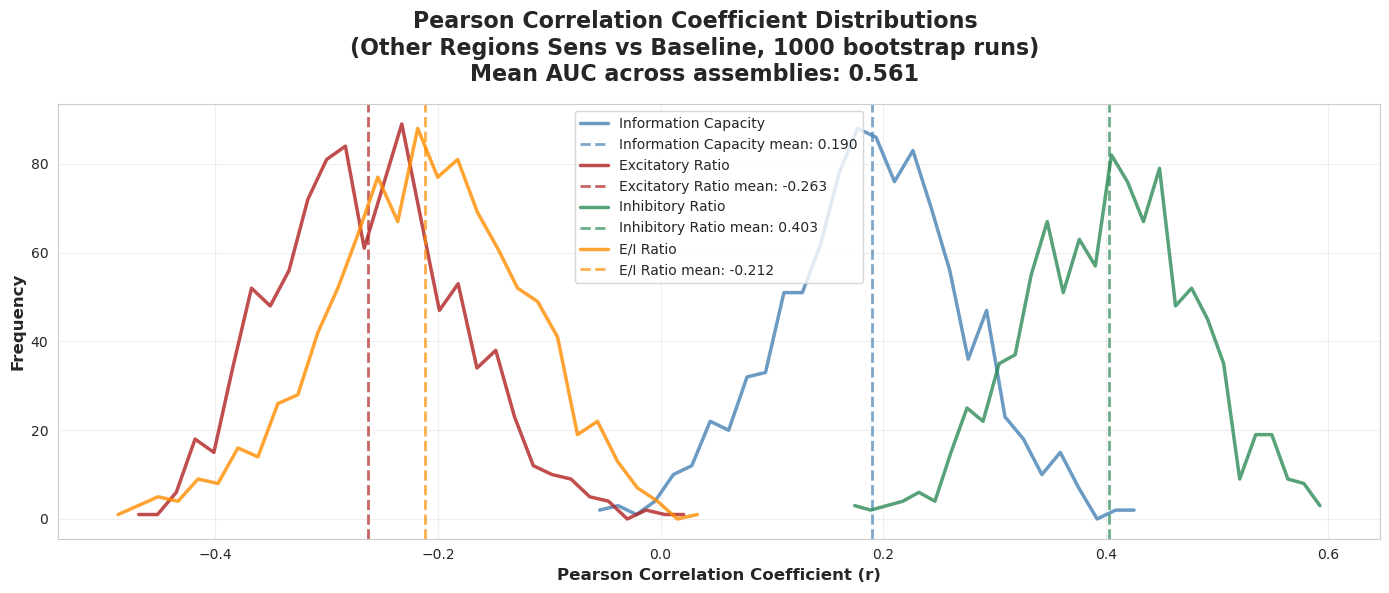

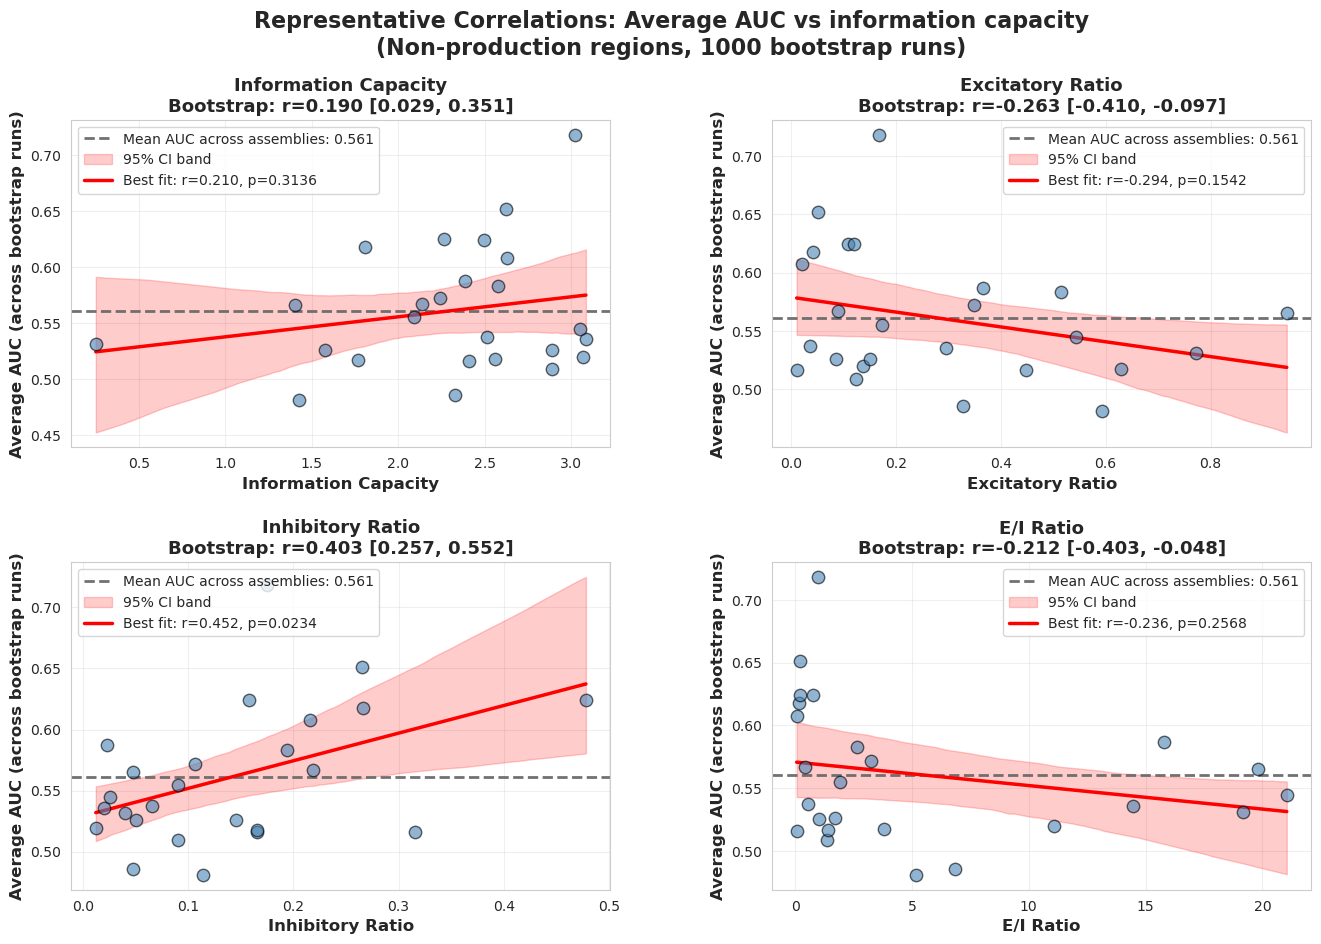

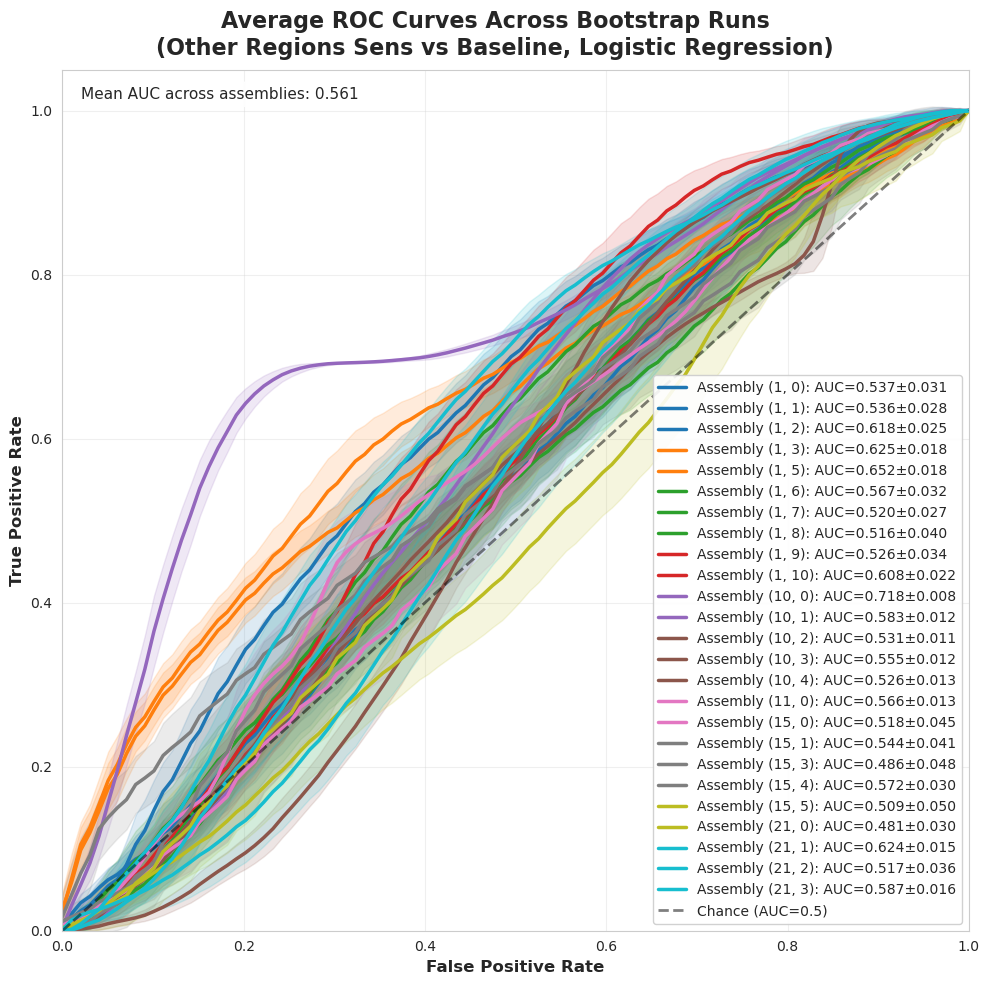


✓ Visualizations complete!
  - Mean AUC across assemblies: 0.561
  - Correlation distributions: 4 metrics
  - Representative scatter plots: 4 metrics
  - Average ROC curves: 25 assemblies


In [103]:
# COMPREHENSIVE VISUALIZATIONS FOR BOOTSTRAP ANALYSIS
# 1. Correlation coefficient distributions with means
# 2. Representative correlation scatter plots with best fit lines
# 3. Representative ROC curves (if available)

print(f"\n{'='*80}")
print("COMPREHENSIVE BOOTSTRAP VISUALIZATIONS")
print(f"{'='*80}\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc
from scipy.interpolate import interp1d

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

_auc_mean_per_asm = df_bootstrap.groupby('assembly_id')['auc'].mean()
grand_mean_auc_across_assemblies = float(_auc_mean_per_asm.mean())

# ============================================================================
# 1. PEARSON CORRELATION COEFFICIENT DISTRIBUTIONS (line plots with means)
# ============================================================================

fig1 = plt.figure(figsize=(14, 6))
ax1 = fig1.add_subplot(1, 1, 1)

fig1.suptitle(
    'Pearson Correlation Coefficient Distributions\n(Other Regions Sens vs Baseline, 1000 bootstrap runs)\n'
    f'Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}',
    fontsize=16, fontweight='bold', y=0.98)

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
# Keep only metrics that the current df_bootstrap AND df_correlations both know about.
# This makes the cell safe to re-run against any vintage of the bootstrap output.
_boot_cols = set(df_bootstrap.columns)
_corr_metrics = set(df_correlations['metric'].unique()) if 'metric' in df_correlations.columns else set()
metrics_to_correlate = [m for m in metrics_to_correlate if m in _boot_cols and m in _corr_metrics]
if not metrics_to_correlate:
    raise RuntimeError("No correlation metrics available in both df_bootstrap and df_correlations - re-run the bootstrap cell above.")
print(f"  metrics available for visualization: {metrics_to_correlate}")

metric_labels = {
    'information_capacity': 'Information Capacity',
    'excitatory_ratio':     'Excitatory Ratio',
    'inhibitory_ratio':     'Inhibitory Ratio',
    'ei_ratio':             'E/I Ratio',
}

_full_colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange']
colors = _full_colors[:len(metrics_to_correlate)]
for idx, metric in enumerate(metrics_to_correlate):
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) == 0:
        continue
    pearson_rs = metric_corrs['pearson_r'].values
    
    # Create histogram data
    counts, bins = np.histogram(pearson_rs, bins=30)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Plot as line plot (step plot)
    ax1.plot(bin_centers, counts, linewidth=2.5, color=colors[idx], 
            label=metric_labels[metric], alpha=0.8)
    
    # Add mean line
    mean_r = np.mean(pearson_rs)
    ax1.axvline(mean_r, color=colors[idx], linestyle='--', linewidth=2, 
               alpha=0.7, label=f'{metric_labels[metric]} mean: {mean_r:.3f}')

ax1.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_coefficients_control.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 2. REPRESENTATIVE CORRELATION SCATTER PLOTS
# (Average AUC across bootstrap runs vs each metric)
# ============================================================================

# Compute average AUC for each assembly across all bootstrap runs
avg_auc_by_assembly = df_bootstrap.groupby('assembly_id')['auc'].mean().reset_index()
avg_auc_by_assembly.columns = ['assembly_id', 'avg_auc']

# Get metric values (same for all runs, so just take first run)
first_run_data = df_bootstrap[df_bootstrap['run'] == df_bootstrap['run'].min()].copy()
_am_cols = ['assembly_id'] + [m for m in metrics_to_correlate if m in first_run_data.columns]
assembly_metrics = first_run_data[_am_cols].copy()

# Merge
plot_data = avg_auc_by_assembly.merge(assembly_metrics, on='assembly_id', how='inner')

fig2 = plt.figure(figsize=(16, 10))
gs2 = fig2.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

fig2.suptitle('Representative Correlations: Average AUC vs information capacity\n(Non-production regions, 1000 bootstrap runs)', 
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    ax = fig2.add_subplot(gs2[row, col])
    
    # Get data for this metric
    if metric not in plot_data.columns:
        continue
    x = plot_data[metric].values
    y = plot_data['avg_auc'].values
    
    # Remove NaN values
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]
    
    if len(x_clean) > 1:
        # Scatter plot
        ax.scatter(x_clean, y_clean, alpha=0.6, s=80, color='steelblue', edgecolors='black', linewidth=1, zorder=3)
        ax.axhline(grand_mean_auc_across_assemblies, color='dimgray', linestyle='--', linewidth=2, alpha=0.95,
                   label=f'Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}', zorder=2)
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
        
        # Create line of best fit
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        y_line = slope * x_line + intercept
        
        # Calculate confidence interval for the regression line
        # Using bootstrap method for CI
        n_boot = 1000
        slopes = []
        intercepts = []
        for _ in range(n_boot):
            indices = np.random.choice(len(x_clean), len(x_clean), replace=True)
            x_boot = x_clean[indices]
            y_boot = y_clean[indices]
            try:
                s, i, _, _, _ = stats.linregress(x_boot, y_boot)
                slopes.append(s)
                intercepts.append(i)
            except:
                continue
        
        slopes = np.array(slopes)
        intercepts = np.array(intercepts)
        
        # Calculate CI for each x point
        y_line_lower = np.zeros_like(x_line)
        y_line_upper = np.zeros_like(x_line)
        for i, x_val in enumerate(x_line):
            y_vals = slopes * x_val + intercepts
            y_line_lower[i] = np.percentile(y_vals, 2.5)
            y_line_upper[i] = np.percentile(y_vals, 97.5)
        
        # Plot CI band
        ax.fill_between(x_line, y_line_lower, y_line_upper, alpha=0.2, color='red', 
                       label='95% CI band')
        
        # Plot best fit line
        ax.plot(x_line, y_line, 'r-', linewidth=2.5, label=f'Best fit: r={r_value:.3f}, p={p_value:.4f}')
        
        # Get correlation from bootstrap analysis
        metric_corrs = df_correlations[df_correlations['metric'] == metric]
        bootstrap_mean_r = metric_corrs['pearson_r'].mean()
        bootstrap_ci_lower = np.percentile(metric_corrs['pearson_r'], 2.5)
        bootstrap_ci_upper = np.percentile(metric_corrs['pearson_r'], 97.5)
        
        ax.set_xlabel(metric_labels[metric], fontsize=12, fontweight='bold')
        ax.set_ylabel('Average AUC (across bootstrap runs)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric_labels[metric]}\n'
                    f'Bootstrap: r={bootstrap_mean_r:.3f} [{bootstrap_ci_lower:.3f}, {bootstrap_ci_upper:.3f}]', 
                    fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', 
               transform=ax.transAxes, fontsize=14)
        ax.set_title(metric_labels[metric], fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("bootstrap_correlations_control.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. AVERAGE ROC CURVES FOR EACH ASSEMBLY (ALL ON SAME AXES)
# ============================================================================

# Get unique assemblies
unique_assemblies = df_bootstrap['assembly_id'].unique()

# Create single figure with one axes
fig3 = plt.figure(figsize=(10, 10))
ax3 = fig3.add_subplot(1, 1, 1)

fig3.suptitle('Average ROC Curves Across Bootstrap Runs\n(Other Regions Sens vs Baseline, Logistic Regression)', 
             fontsize=16, fontweight='bold', y=0.98)
ax3.text(0.02, 0.98, f'Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}',
         transform=ax3.transAxes, fontsize=11, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Use a colormap to get different colors for each assembly
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_assemblies)))

# Interpolate all ROC curves to common FPR points
all_fpr = np.linspace(0, 1, 100)

for idx, assembly_id in enumerate(unique_assemblies):
    # Get all ROC curves for this assembly across all bootstrap runs
    assembly_mask = df_bootstrap['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            # Handle case where fpr/tpr might be stored as lists
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                # Interpolate
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            std_tpr = np.std(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            std_auc = np.std(assembly_aucs)
            
            # Plot mean with confidence interval
            ax3.plot(all_fpr, mean_tpr, color=colors[idx], lw=2.5, 
                   label=f'Assembly {assembly_id}: AUC={mean_auc:.3f}±{std_auc:.3f}')
            ax3.fill_between(all_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                           color=colors[idx], alpha=0.15)

# Plot chance line (only once)
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Chance (AUC=0.5)')

ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_roc_curves_control.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualizations complete!")
print(f"  - Mean AUC across assemblies: {grand_mean_auc_across_assemblies:.3f}")
print(f"  - Correlation distributions: {len(metrics_to_correlate)} metrics")
print(f"  - Representative scatter plots: {len(metrics_to_correlate)} metrics")
print(f"  - Average ROC curves: {len(unique_assemblies)} assemblies")


AUC COMPARISON BY ASSEMBLY: PRODUCTION REGIONS vs NON-PRODUCTION REGIONS
(Average AUC per assembly across all bootstrap runs)

Calculating average AUC per assembly for production regions...
  Found 15 production-region assemblies
  Mean assembly AUC = 0.5413 ± 0.0690
  Median assembly AUC = 0.4975
  Range: [0.4738, 0.6954]

Calculating average AUC per assembly for non-production regions...
  Found 25 other region assemblies
  Mean assembly AUC = 0.5608 ± 0.0558
  Median assembly AUC = 0.5444
  Range: [0.4811, 0.7182]

STATISTICAL TEST
Levene's test for equal variances: p = 0.5994
Using Student's t-test (equal variances assumed)

t-statistic = -0.9778
p-value = 0.334353
Significance: ns (p >= 0.05)

PER-GROUP TEST: AUC > 0.5 (above chance)?

  Production regions (n=15)
    mean AUC = 0.5413  95% CI [0.5032, 0.5795]
    one-sample t-test vs 0.5 (alt=greater): t(14) = 2.322, p = 0.01792  -> * (p < 0.05)
    Wilcoxon signed-rank vs 0.5 (alt=greater):           p = 0.09381  -> ns (p >= 0.05

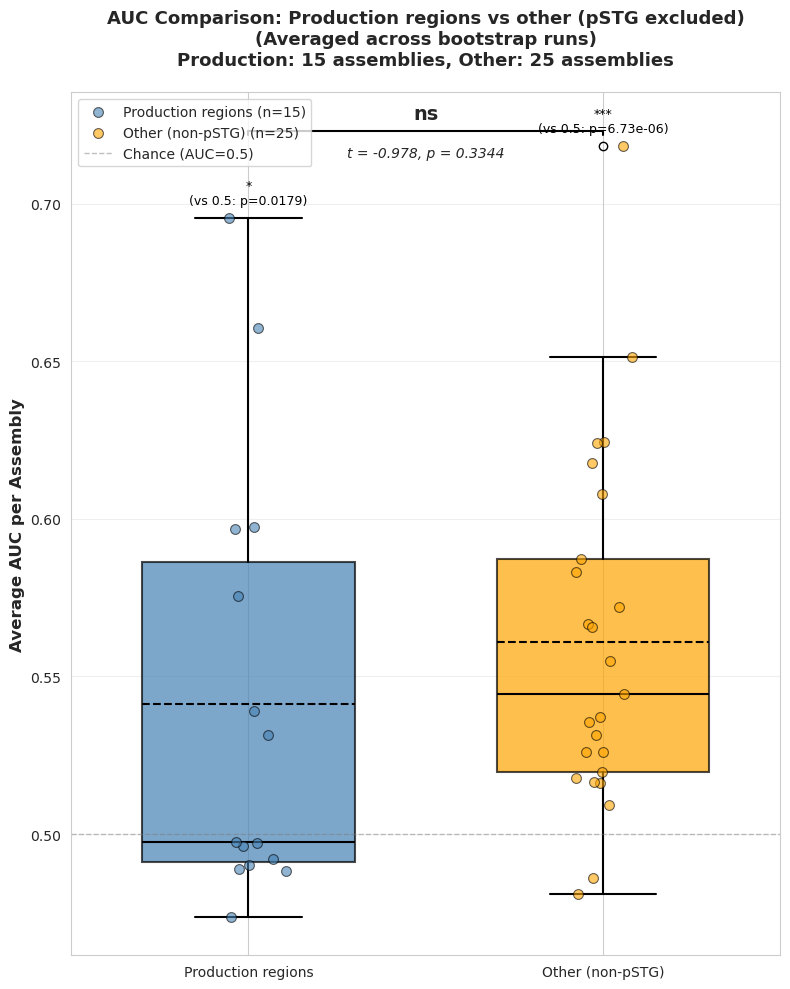


SUMMARY TABLE
            Region  N Assemblies  Mean AUC  Std AUC  Median AUC  Min AUC  Max AUC  95% CI (mean)  t-test vs 0.5 (p)  Wilcoxon vs 0.5 (p)
Production regions            15  0.541345 0.066631    0.497469  0.47376 0.695418 [0.503, 0.580]           0.017921         9.381104e-02
  Other (non-pSTG)            25  0.560827 0.054708    0.544411  0.48107 0.718235 [0.538, 0.584]           0.000007         7.450581e-07

COMPARISON COMPLETE

✓ Plot saved as 'auc_comparison_by_assembly_pstg_vs_other.svg'


In [108]:
# COMPARE AUCs BY ASSEMBLY: PRODUCTION REGIONS vs OTHER REGIONS (pSTG excluded from this notebook)
# Averages AUC across all bootstrap runs for each assembly, then compares groups
# Statistical comparison using t-test with box plot and overlaid data points

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("AUC COMPARISON BY ASSEMBLY: PRODUCTION REGIONS vs NON-PRODUCTION REGIONS")
print("(Average AUC per assembly across all bootstrap runs)")
print("=" * 80)

# Check if the saved dataframes exist
if 'df_bootstrap_production_regions' not in globals():
    print("\n⚠️  Warning: df_bootstrap_production_regions not found.")
    print("   Run the production-regions bootstrap cell first.")
    raise NameError("df_bootstrap_production_regions not found.")

if 'df_bootstrap_other' not in globals():
    print("\n⚠️  Warning: df_bootstrap_other not found.")
    print("   Run the non-production-regions bootstrap cell first.")
    raise NameError("df_bootstrap_other not found.")

# Calculate average AUC per assembly for production regions
print("\nCalculating average AUC per assembly for production regions...")
prod_avg_auc = df_bootstrap_production_regions.groupby('assembly_id')['auc'].mean().reset_index()
prod_avg_auc.columns = ['assembly_id', 'avg_auc']
prod_avg_auc['region'] = 'Production (vPrCG, parsOp, parsTr)'

print(f"  Found {len(prod_avg_auc)} production-region assemblies")
print(f"  Mean assembly AUC = {prod_avg_auc['avg_auc'].mean():.4f} ± {prod_avg_auc['avg_auc'].std():.4f}")
print(f"  Median assembly AUC = {prod_avg_auc['avg_auc'].median():.4f}")
print(f"  Range: [{prod_avg_auc['avg_auc'].min():.4f}, {prod_avg_auc['avg_auc'].max():.4f}]")

# Calculate average AUC per assembly for non-production regions (excl. pSTG)
print("\nCalculating average AUC per assembly for non-production regions...")
other_avg_auc = df_bootstrap_other.groupby('assembly_id')['auc'].mean().reset_index()
other_avg_auc.columns = ['assembly_id', 'avg_auc']
other_avg_auc['region'] = 'Other Regions'

print(f"  Found {len(other_avg_auc)} other region assemblies")
print(f"  Mean assembly AUC = {other_avg_auc['avg_auc'].mean():.4f} ± {other_avg_auc['avg_auc'].std():.4f}")
print(f"  Median assembly AUC = {other_avg_auc['avg_auc'].median():.4f}")
print(f"  Range: [{other_avg_auc['avg_auc'].min():.4f}, {other_avg_auc['avg_auc'].max():.4f}]")

# Extract average AUC values for statistical test
auc_prod_assemblies = prod_avg_auc['avg_auc'].values
auc_other_assemblies = other_avg_auc['avg_auc'].values

# Perform t-test
# First check for equal variances
levene_stat, levene_p = stats.levene(auc_prod_assemblies, auc_other_assemblies)
equal_var = levene_p > 0.05

# Perform t-test (use Welch's t-test if variances are unequal)
t_stat, t_pval = stats.ttest_ind(auc_prod_assemblies, auc_other_assemblies, equal_var=equal_var)

print(f"\n{'='*80}")
print("STATISTICAL TEST")
print(f"{'='*80}")
print(f"Levene's test for equal variances: p = {levene_p:.4f}")
if equal_var:
    print("Using Student's t-test (equal variances assumed)")
else:
    print("Using Welch's t-test (unequal variances)")

print(f"\nt-statistic = {t_stat:.4f}")
print(f"p-value = {t_pval:.6f}")

if t_pval < 0.001:
    sig_text = "*** (p < 0.001)"
elif t_pval < 0.01:
    sig_text = "** (p < 0.01)"
elif t_pval < 0.05:
    sig_text = "* (p < 0.05)"
else:
    sig_text = "ns (p >= 0.05)"

print(f"Significance: {sig_text}")

# ---- Per-group test: is assembly AUC significantly > 0.5 (above chance)? ----
def _sig_label(p):
    if p < 0.001: return '*** (p < 0.001)'
    if p < 0.01:  return '** (p < 0.01)'
    if p < 0.05:  return '* (p < 0.05)'
    return 'ns (p >= 0.05)'

def _chance_tests(name, aucs):
    t_stat_g, t_p_g = stats.ttest_1samp(aucs, 0.5, alternative='greater')
    # Wilcoxon signed-rank vs 0.5 (non-parametric sanity check, one-sided)
    try:
        w_stat, w_p = stats.wilcoxon(aucs - 0.5, alternative='greater', zero_method='wilcox')
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    mean_auc = float(np.mean(aucs))
    sem_auc  = float(stats.sem(aucs))
    df       = len(aucs) - 1
    # 95% CI on the mean (two-sided, for reference)
    if df > 0 and sem_auc > 0:
        tcrit = stats.t.ppf(0.975, df)
        ci_lo = mean_auc - tcrit * sem_auc
        ci_hi = mean_auc + tcrit * sem_auc
    else:
        ci_lo = ci_hi = np.nan
    print(f"\n  {name} (n={len(aucs)})")
    print(f"    mean AUC = {mean_auc:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"    one-sample t-test vs 0.5 (alt=greater): t({df}) = {t_stat_g:.3f}, p = {t_p_g:.4g}  -> {_sig_label(t_p_g)}")
    print(f"    Wilcoxon signed-rank vs 0.5 (alt=greater):           p = {w_p:.4g}  -> {_sig_label(w_p)}")
    return {'mean': mean_auc, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            't_p': float(t_p_g), 'w_p': float(w_p)}

print(f"\n{'='*80}")
print("PER-GROUP TEST: AUC > 0.5 (above chance)?")
print(f"{'='*80}")
chance_prod  = _chance_tests('Production regions', auc_prod_assemblies)
chance_other = _chance_tests('Other (non-pSTG)',   auc_other_assemblies)

# Create box plot with overlaid data points
fig, ax = plt.subplots(figsize=(8, 10))

# Prepare data for plotting
data_to_plot = [auc_prod_assemblies, auc_other_assemblies]
labels = ['Production regions', 'Other (non-pSTG)']
colors = ['steelblue', 'orange']

# Create box plot
bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, 
                widths=0.6, showmeans=True, meanline=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style the other elements
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    if element in bp:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Overlay individual data points with jitter
for i, (data, color) in enumerate(zip(data_to_plot, colors)):
    # Add jitter to x positions
    x_pos = np.random.normal(i+1, 0.04, size=len(data))
    ax.scatter(x_pos, data, alpha=0.6, s=50, color=color, 
              edgecolors='black', linewidth=0.8, zorder=10, label=f'{labels[i]} (n={len(data)})')

# Add statistical annotation
y_max = max(np.max(auc_prod_assemblies), np.max(auc_other_assemblies))
y_min = min(np.min(auc_prod_assemblies), np.min(auc_other_assemblies))
y_range = y_max - y_min

# Draw bracket for significance
y_bracket = y_max + 0.02 * y_range
ax.plot([1, 2], [y_bracket, y_bracket], 'k-', linewidth=1.5)
ax.plot([1, 1], [y_bracket - 0.005 * y_range, y_bracket], 'k-', linewidth=1.5)
ax.plot([2, 2], [y_bracket - 0.005 * y_range, y_bracket], 'k-', linewidth=1.5)

# Add text annotation
if t_pval < 0.001:
    sig_symbol = "***"
elif t_pval < 0.01:
    sig_symbol = "**"
elif t_pval < 0.05:
    sig_symbol = "*"
else:
    sig_symbol = "ns"

ax.text(1.5, y_bracket + 0.01 * y_range, sig_symbol, 
        ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add test statistics text
stats_text = f"t = {t_stat:.3f}, p = {t_pval:.4f}"
ax.text(1.5, y_bracket - 0.02 * y_range, stats_text,
        ha='center', va='top', fontsize=10, style='italic')

# Annotate each box with its >0.5 one-sample t-test result
def _sig_symbol(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'
for i, (data, res) in enumerate([(auc_prod_assemblies, chance_prod),
                                  (auc_other_assemblies, chance_other)]):
    sym = _sig_symbol(res['t_p'])
    y = np.max(data) + 0.015 * y_range
    ax.text(i + 1, y, f"{sym}\n(vs 0.5: p={res['t_p']:.3g})",
            ha='center', va='bottom', fontsize=9, color='black')

# Customize axes
ax.set_ylabel('Average AUC per Assembly', fontsize=12, fontweight='bold')
ax.set_title('AUC Comparison: Production regions vs other (pSTG excluded)\n' + 
            f'(Averaged across bootstrap runs)\n' +
            f'Production: {len(auc_prod_assemblies)} assemblies, Other: {len(auc_other_assemblies)} assemblies',
            fontsize=13, fontweight='bold', pad=20)
ax.set_ylim([y_min - 0.05 * y_range, y_bracket + 0.05 * y_range])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Chance (AUC=0.5)')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("auc_comparison_by_assembly_pstg_vs_other.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Create summary table
print(f"\n{'='*80}")
print("SUMMARY TABLE")
print(f"{'='*80}")
summary_df = pd.DataFrame({
    'Region': ['Production regions', 'Other (non-pSTG)'],
    'N Assemblies': [len(auc_prod_assemblies), len(auc_other_assemblies)],
    'Mean AUC': [np.mean(auc_prod_assemblies), np.mean(auc_other_assemblies)],
    'Std AUC': [np.std(auc_prod_assemblies), np.std(auc_other_assemblies)],
    'Median AUC': [np.median(auc_prod_assemblies), np.median(auc_other_assemblies)],
    'Min AUC': [np.min(auc_prod_assemblies), np.min(auc_other_assemblies)],
    'Max AUC': [np.max(auc_prod_assemblies), np.max(auc_other_assemblies)],
    '95% CI (mean)': [f"[{chance_prod['ci_lo']:.3f}, {chance_prod['ci_hi']:.3f}]",
                      f"[{chance_other['ci_lo']:.3f}, {chance_other['ci_hi']:.3f}]"],
    't-test vs 0.5 (p)':  [chance_prod['t_p'], chance_other['t_p']],
    'Wilcoxon vs 0.5 (p)':[chance_prod['w_p'], chance_other['w_p']],
})
print(summary_df.to_string(index=False))

print(f"\n{'='*80}")
print("COMPARISON COMPLETE")
print(f"{'='*80}")
print(f"\n✓ Plot saved as 'auc_comparison_by_assembly_pstg_vs_other.svg'")  # filename unchanged for downstream refs


ROC CURVES: PRODUCTION REGIONS vs OTHER REGIONS
(Average ROC curves per assembly across all bootstrap runs)

Production regions: 15 assemblies
Other regions: 25 assemblies

Processing production-region assemblies...
Processing other region assemblies...


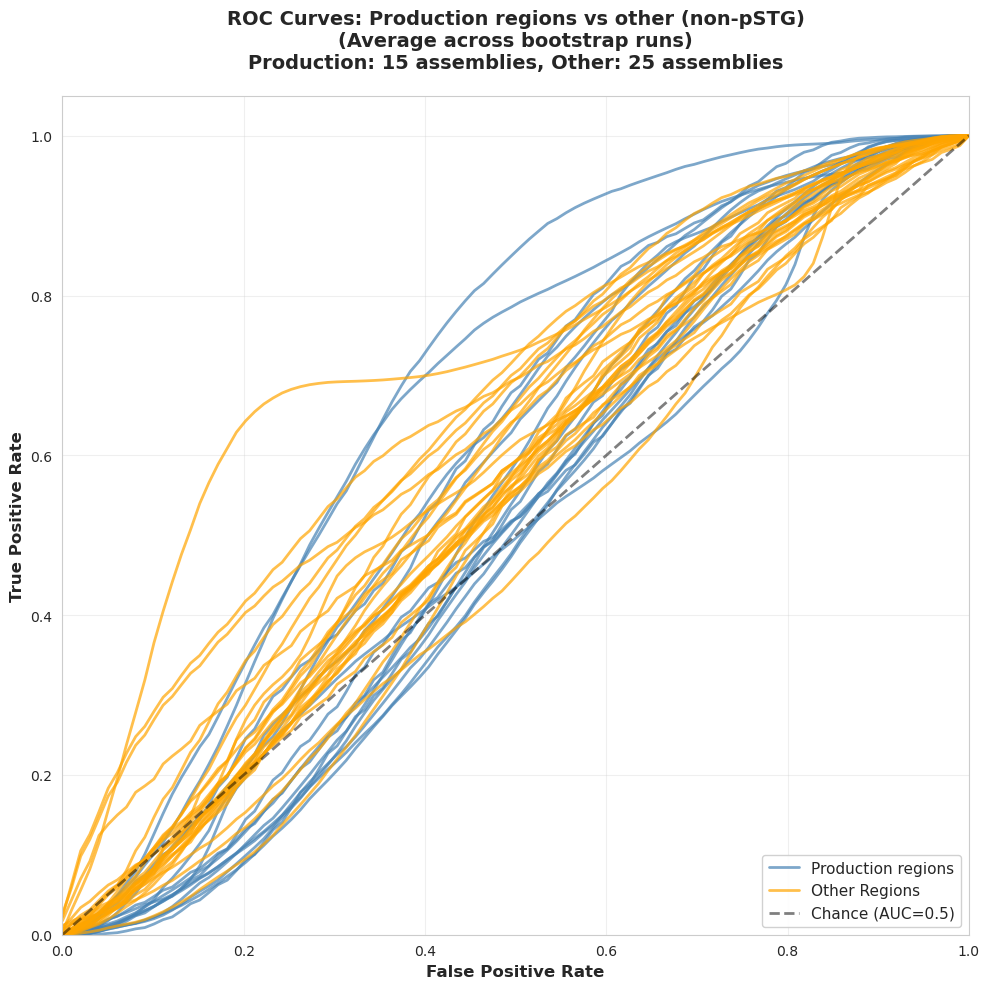


ROC COMPARISON COMPLETE

✓ Plotted 15 production-region assemblies and 25 other region assemblies
✓ Plot saved as 'roc_curves_pstg_vs_other.svg'


In [105]:
# ROC CURVES: PRODUCTION REGIONS vs OTHER REGIONS
# Plots all average ROC curves together, colored by region category

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("ROC CURVES: PRODUCTION REGIONS vs OTHER REGIONS")
print("(Average ROC curves per assembly across all bootstrap runs)")
print("=" * 80)

# Check if the saved dataframes exist
if 'df_bootstrap_production_regions' not in globals():
    print("\n⚠️  Warning: df_bootstrap_production_regions not found.")
    raise NameError("df_bootstrap_production_regions not found.")

if 'df_bootstrap_other' not in globals():
    print("\n⚠️  Warning: df_bootstrap_other not found.")
    print("   Please run the other regions bootstrap cell (Cell 19) first.")
    raise NameError("df_bootstrap_other not found. Please run Cell 19 first.")

# Get unique assemblies for each region category
prod_assemblies = df_bootstrap_production_regions['assembly_id'].unique()
other_assemblies = df_bootstrap_other['assembly_id'].unique()

print(f"\nProduction regions: {len(prod_assemblies)} assemblies")
print(f"Other regions: {len(other_assemblies)} assemblies")

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Colors for each category
prod_color = 'steelblue'
other_color = 'orange'

# Interpolate all ROC curves to common FPR points
all_fpr = np.linspace(0, 1, 100)

# Plot production-region ROC curves
print("\nProcessing production-region assemblies...")
prod_count = 0
for assembly_id in prod_assemblies:
    assembly_mask = df_bootstrap_production_regions['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap_production_regions.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap_production_regions.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap_production_regions.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            
            # Plot mean ROC curve
            ax.plot(all_fpr, mean_tpr, color=prod_color, lw=2, alpha=0.7, 
                   label='Production regions' if prod_count == 0 else '')
            prod_count += 1

# Plot other regions ROC curves
print("Processing other region assemblies...")
other_count = 0
for assembly_id in other_assemblies:
    assembly_mask = df_bootstrap_other['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap_other.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap_other.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap_other.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            
            # Plot mean ROC curve
            ax.plot(all_fpr, mean_tpr, color=other_color, lw=2, alpha=0.7,
                   label='Other Regions' if other_count == 0 else '')
            other_count += 1

# Plot chance line
ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Chance (AUC=0.5)')

# Customize axes
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves: Production regions vs other (non-pSTG)\n' + 
            f'(Average across bootstrap runs)\n' +
            f'Production: {prod_count} assemblies, Other: {other_count} assemblies',
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves_pstg_vs_other.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("ROC COMPARISON COMPLETE")
print(f"{'='*80}")
print(f"\n✓ Plotted {prod_count} production-region assemblies and {other_count} other region assemblies")
print(f"✓ Plot saved as 'roc_curves_pstg_vs_other.svg'")
